In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt



import joblib
from sklearn.preprocessing import MinMaxScaler

2026-02-10 13:56:33.003884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770760593.210544  448514 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770760593.259875  448514 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770760593.750588  448514 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770760593.750611  448514 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770760593.750614  448514 computation_placer.cc:177] computation placer alr

In [2]:

model_samp = str(240700000)
print("modules loaded")


modules loaded


In [3]:
#### test file #######
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_vmc_mean_0000655360.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]

In [4]:
def D_JS(p1,p2,tol=1e-16):
    p1=p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [5]:
def encode_voxel_to_rgb(test_d, save_path='slice_scalers.npz'):
    """
    Normalize each XY slice independently and encode to RGB (repeated channels).
    Saves (min, max) for each slice for reconstruction.
    
    Returns:
        rgb_volume: (64, 64, 64, 3)
    """
    rgb_volume = np.zeros((64, 64, 64, 3), dtype=np.float32)
    mins = []
    maxs = []

    for i in range(64):
        slice_2d = test_d[i, :, :]
        s_min = float(slice_2d.min())
        s_max = float(slice_2d.max())

        if s_max == s_min:
            s_max = s_min + 1e-6  # Avoid divide-by-zero for flat slices

        normed = (slice_2d - s_min) / (s_max - s_min)
        rgb_volume[i, :, :, :] = np.stack([normed]*3, axis=-1)  # (64, 64, 3)

        mins.append(s_min)
        maxs.append(s_max)

    np.savez(save_path, mins=np.array(mins), maxs=np.array(maxs))
    return rgb_volume  # shape: (64, 64, 64, 3)


In [6]:
def decode_rgb_to_voxel(rgb_volume, save_path='slice_scalers.npz'):
    """
    Decode per-slice normalized RGB volume back into scalar 3D volume.
    Assumes all RGB channels are identical.
    
    Args:
        rgb_volume: shape (64, 64, 64, 3)
    """
    data = np.load(save_path)
    mins = data['mins']
    maxs = data['maxs']

    test_d = np.zeros((64, 64, 64), dtype=np.float32)

    for i in range(64):
        rgb_slice = rgb_volume[i]  # (64, 64, 3)
        gray = rgb_slice[:, :, 0]
        restored = gray * (maxs[i] - mins[i]) + mins[i]
        test_d[i] = restored

    return test_d


In [7]:
# Fully working 

################# CAE_full_3D #############
from keras.models import load_model
import keras

############# Nature #####################
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class RenormalizeToEight(tf.keras.layers.Layer):
    def call(self, x):
        total = tf.reduce_sum(x, axis=[1, 2, 3, 4], keepdims=True)
        return x / (total + 1e-8) * 8.0


@tf.keras.utils.register_keras_serializable()
def jensen_shannon_divergence_loss(y_true, y_pred):
    y_t = tf.cast(y_true, tf.float32)
    y_p = tf.cast(y_pred, tf.float32)

    y_t = tf.reshape(y_t, [tf.shape(y_t)[0], -1])
    y_p = tf.reshape(y_p, [tf.shape(y_p)[0], -1])

    y_t /= tf.reduce_sum(y_t, axis=1, keepdims=True) + 1e-8
    y_p /= tf.reduce_sum(y_p, axis=1, keepdims=True) + 1e-8

    m = 0.5 * (y_t + y_p)
    kl_true = tf.reduce_sum(y_t * tf.math.log((y_t + 1e-8) / (m + 1e-8)), axis=1)
    kl_pred = tf.reduce_sum(y_p * tf.math.log((y_p + 1e-8) / (m + 1e-8)), axis=1)
    return tf.reduce_mean(0.5 * (kl_true + kl_pred))
    
from keras.models import load_model
import keras
keras.config.enable_unsafe_deserialization()


def CAE_3D_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = test_d
    ref_rgb  = ref_d
    reshaped_arr = test_rgb.reshape(1,64, 64, 64, 1)
    
    denoised_rgb = CAE_3D_mod.predict(reshaped_arr)  # shape: (H, W, 3)
    



    # Reconstruct full 3D volume
    denoised_d = denoised_rgb.reshape(64,64,64)

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics")
    jsd_noisy = jensen_shannon_divergence_loss(test_d,
        ref_d
    )
    jsd_denoised = jensen_shannon_divergence_loss(
        denoised_d,
        ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")

    print(test_d.shape,denoised_d.shape,ref_d.shape)

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised)


In [8]:
print("IMG 3D loaded")

IMG 3D loaded


Found 33 noisy files.
Found 6 CAE_3D models.

=== Running model: 2336000000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.326098
JSD   (denoised vs ref):  0.000094
(64, 64, 64) (64, 64, 64) (64, 64, 64)


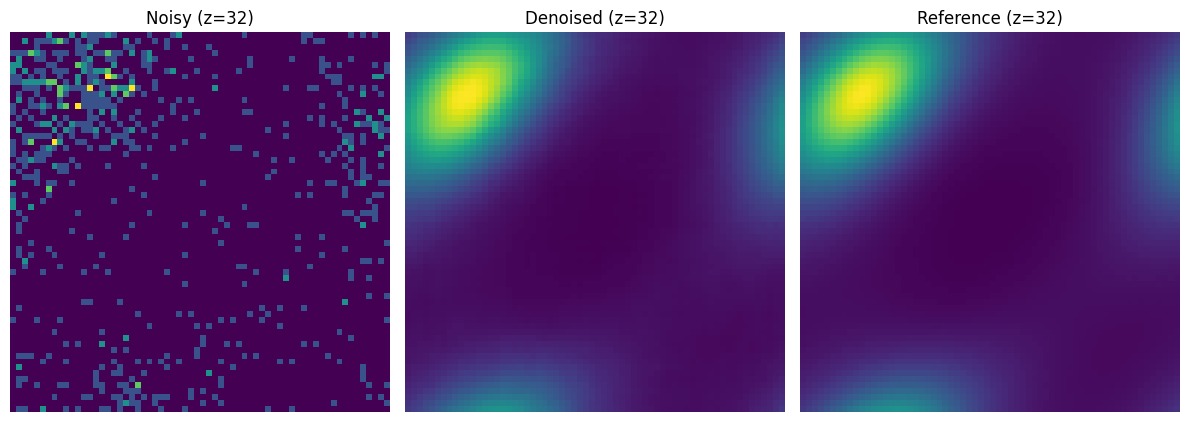

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.219943
JSD   (denoised vs ref):  0.000093
(64, 64, 64) (64, 64, 64) (64, 64, 64)


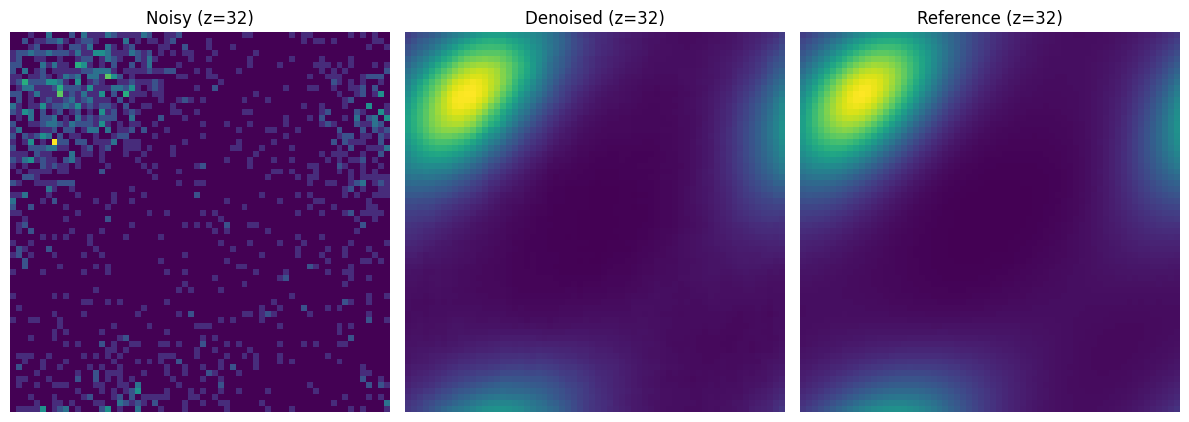

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.132102
JSD   (denoised vs ref):  0.000092
(64, 64, 64) (64, 64, 64) (64, 64, 64)


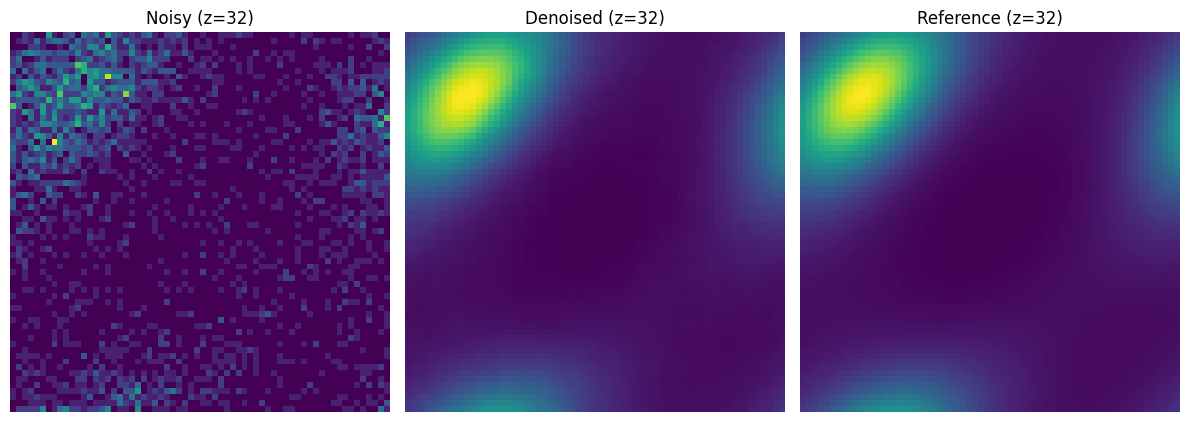

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.072527
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


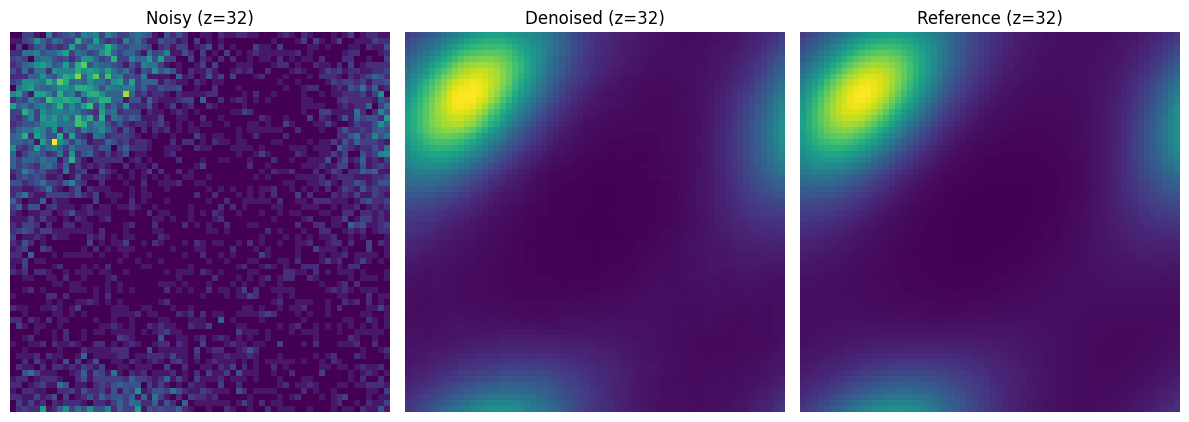

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.036875
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


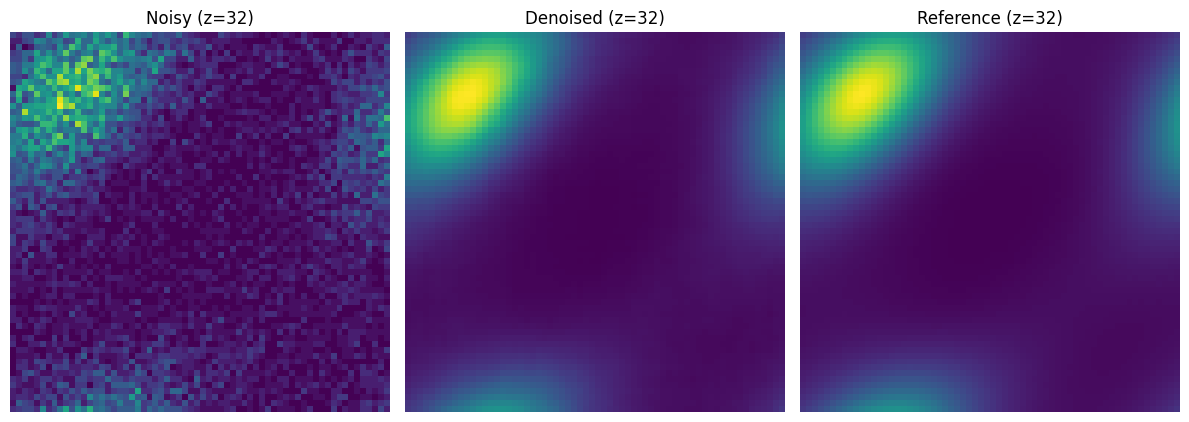

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.017617
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


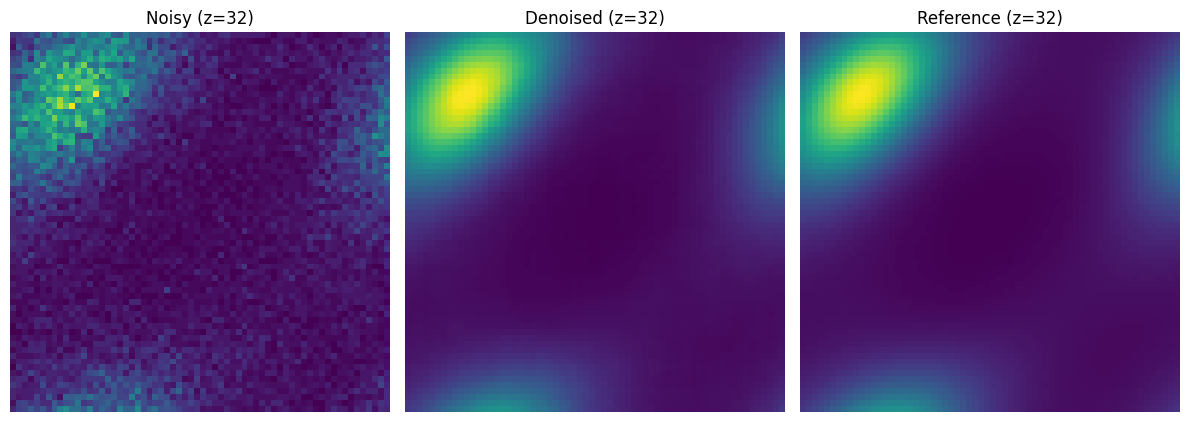

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.013049
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


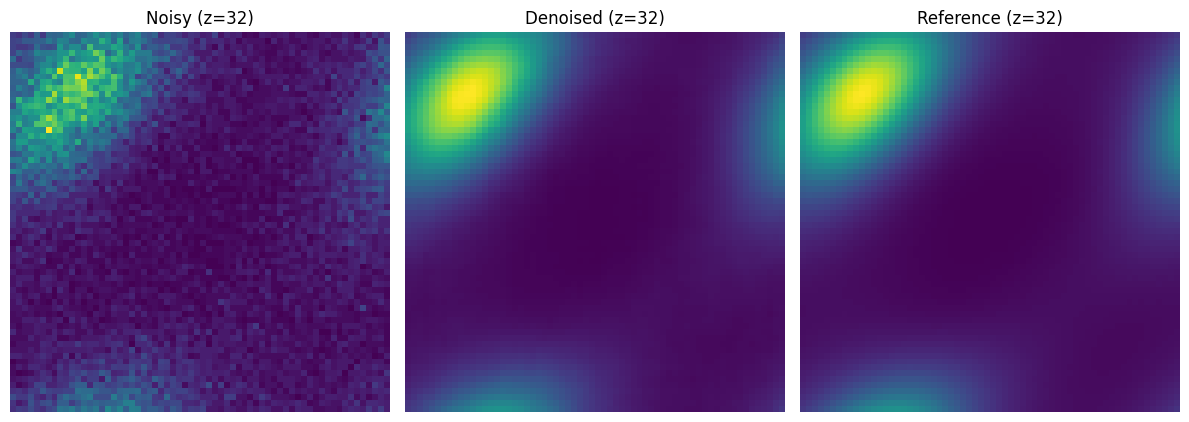

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.008181
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


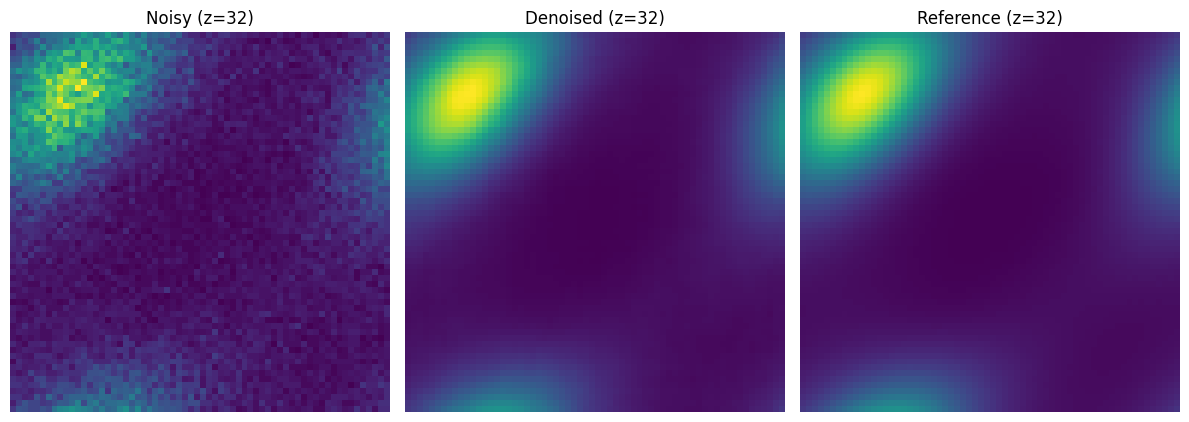

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.006157
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


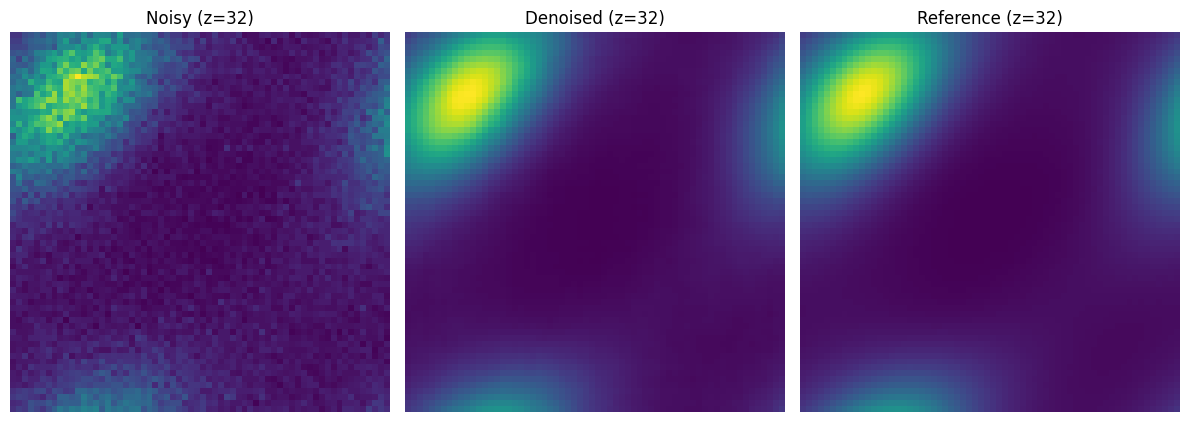

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.003937
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


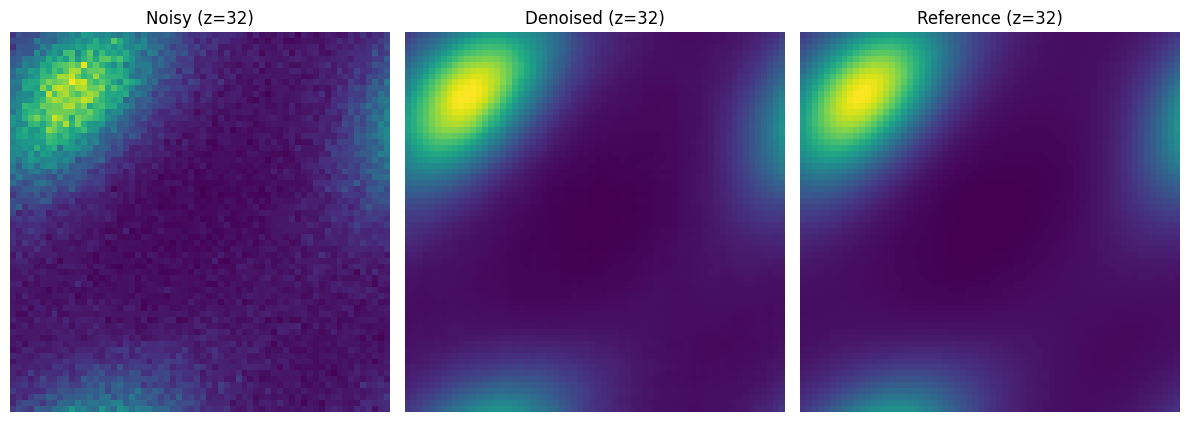

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.002993
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


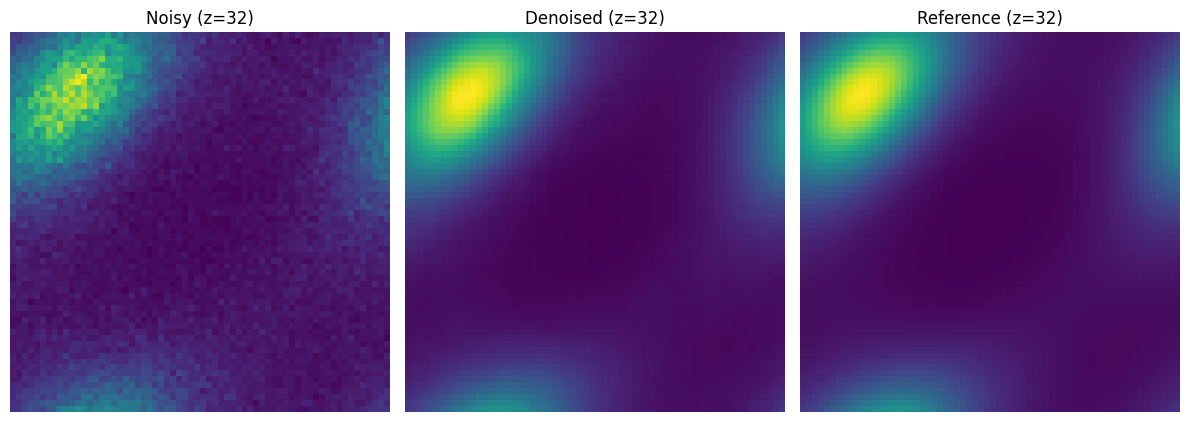

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.001939
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


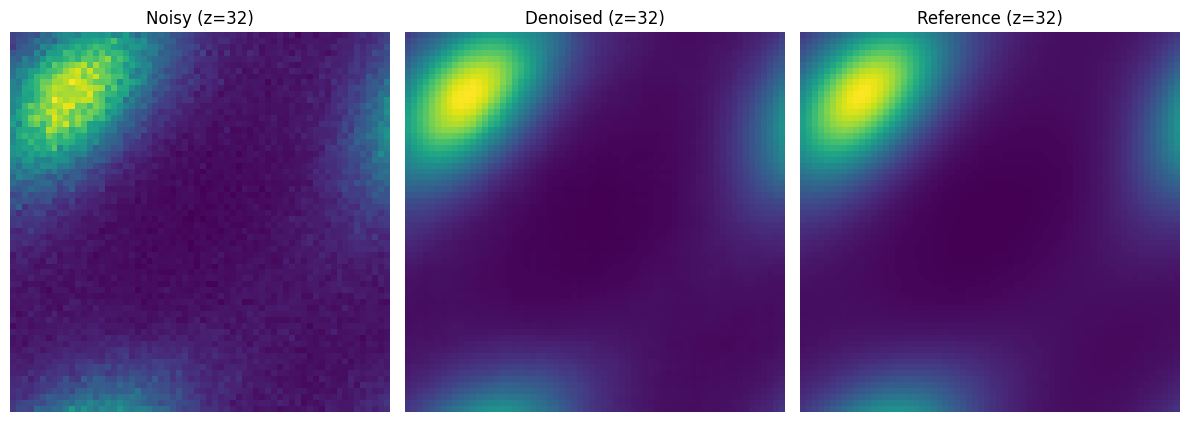

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.001476
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


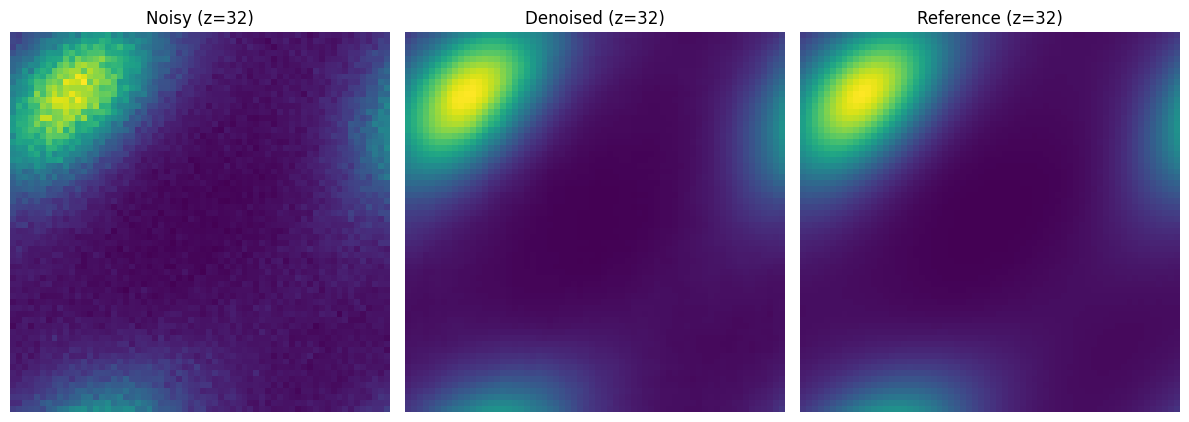

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000984
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


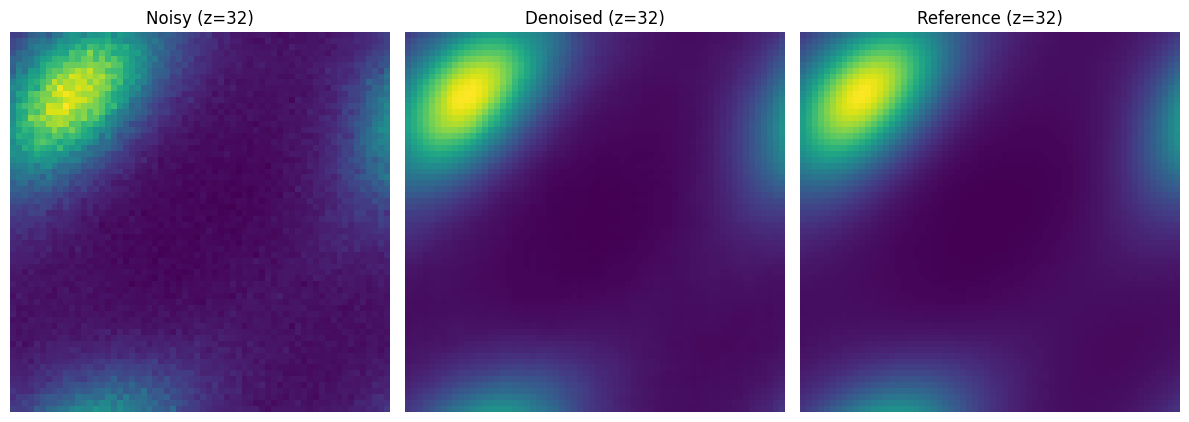

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000966
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


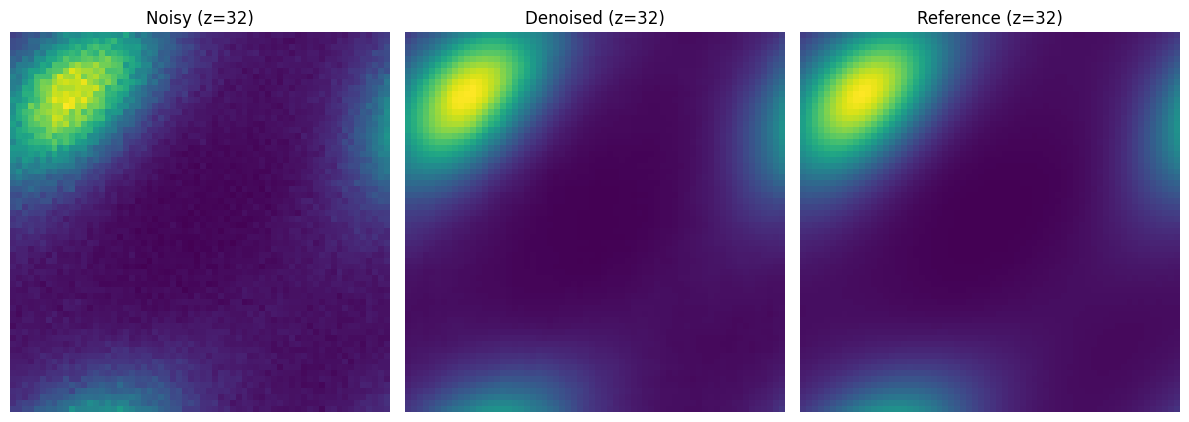

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000735
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


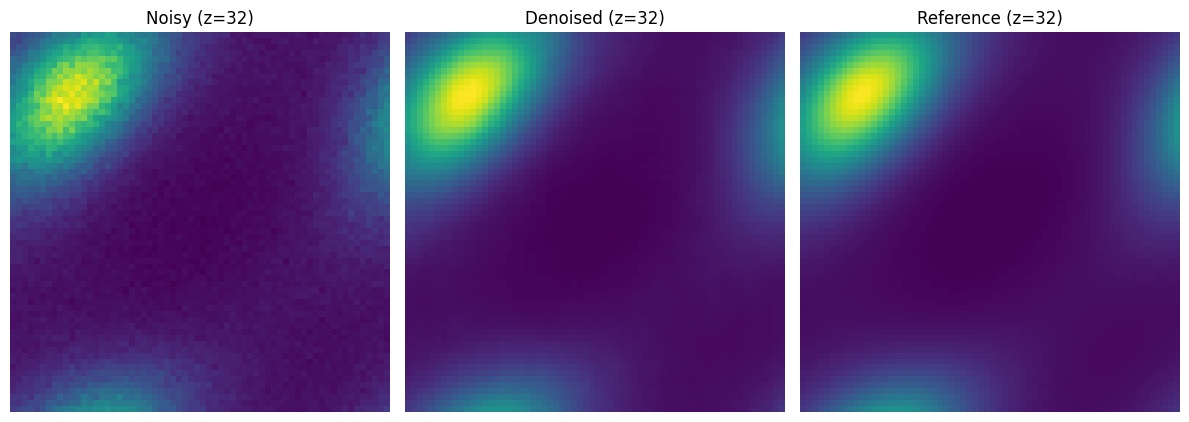

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000491
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


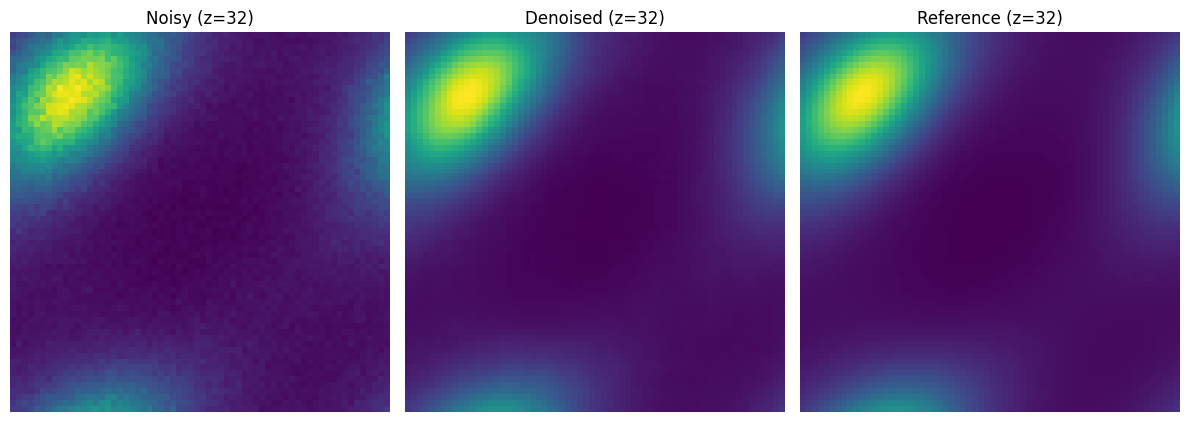

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000482
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


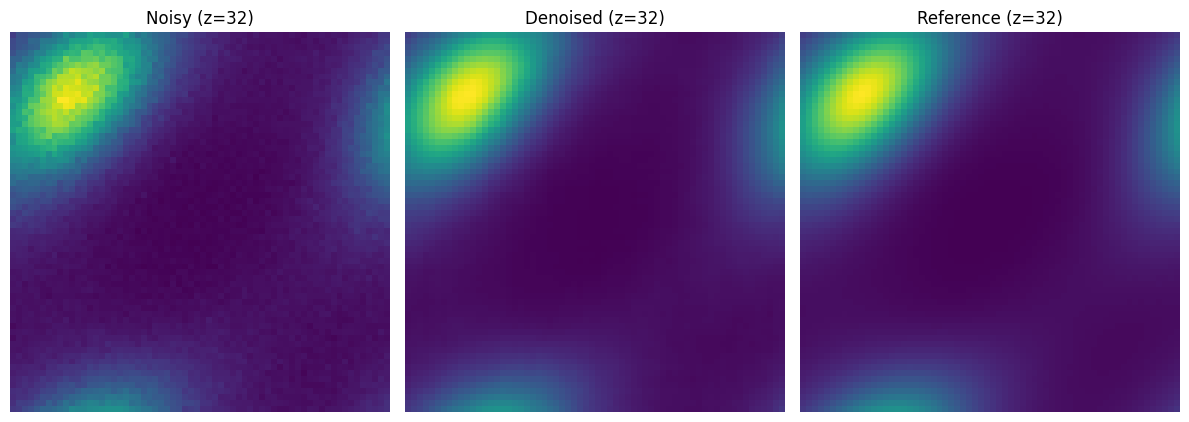

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000367
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


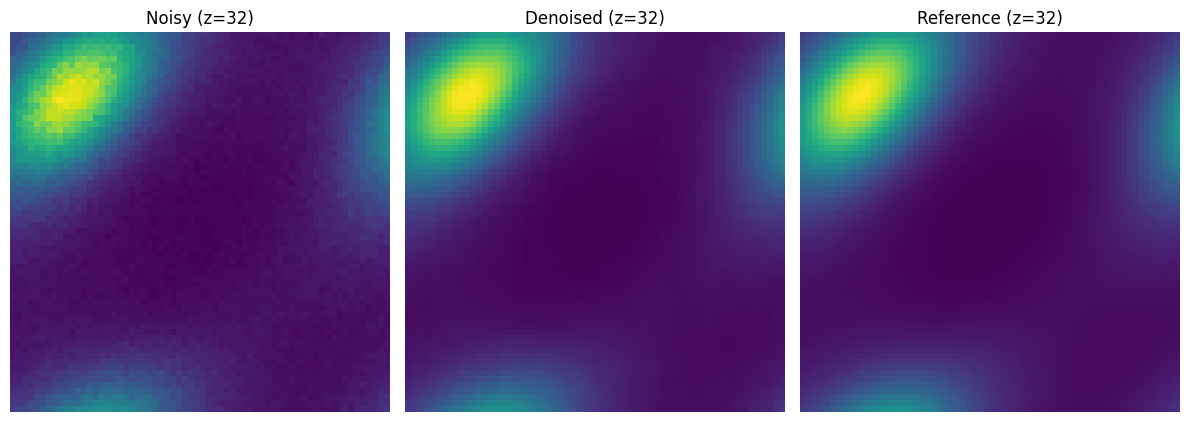

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000245
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


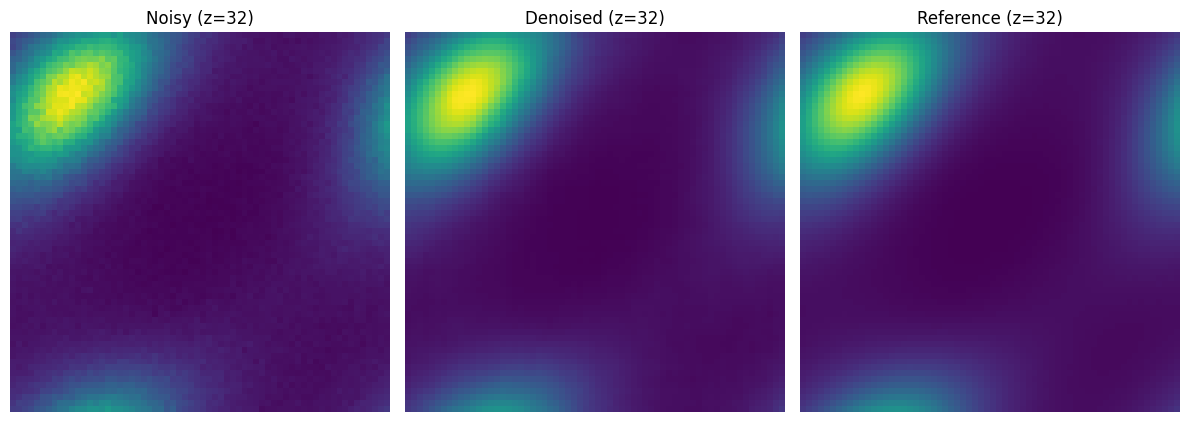

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000184
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


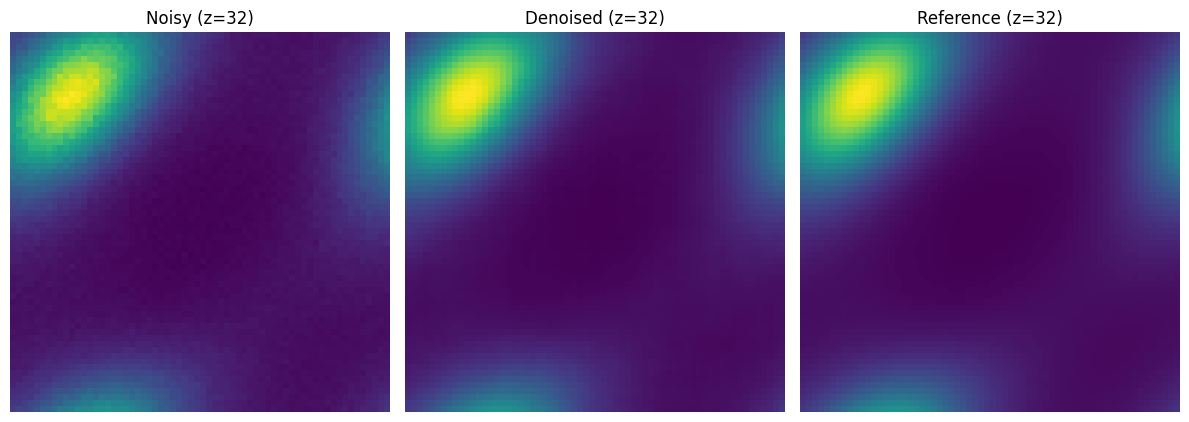

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000123
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


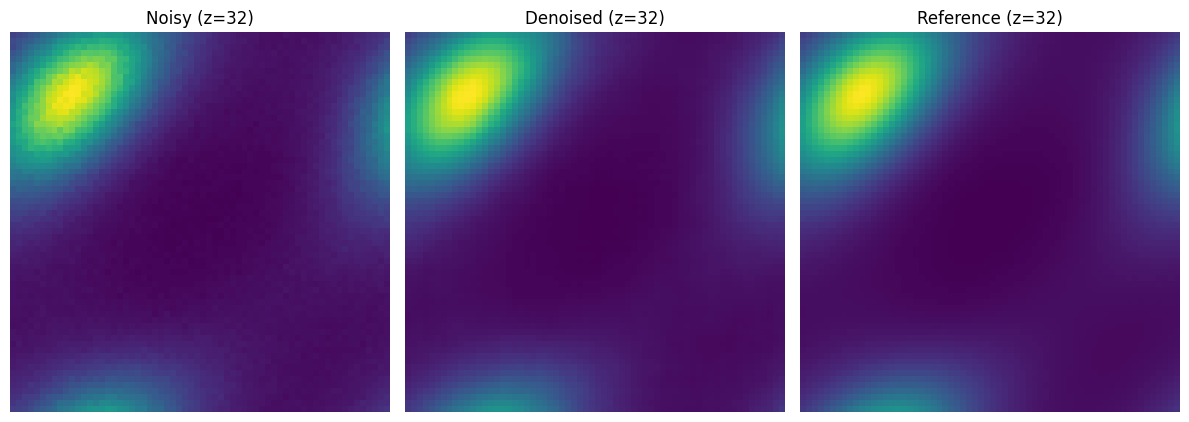

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000092
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


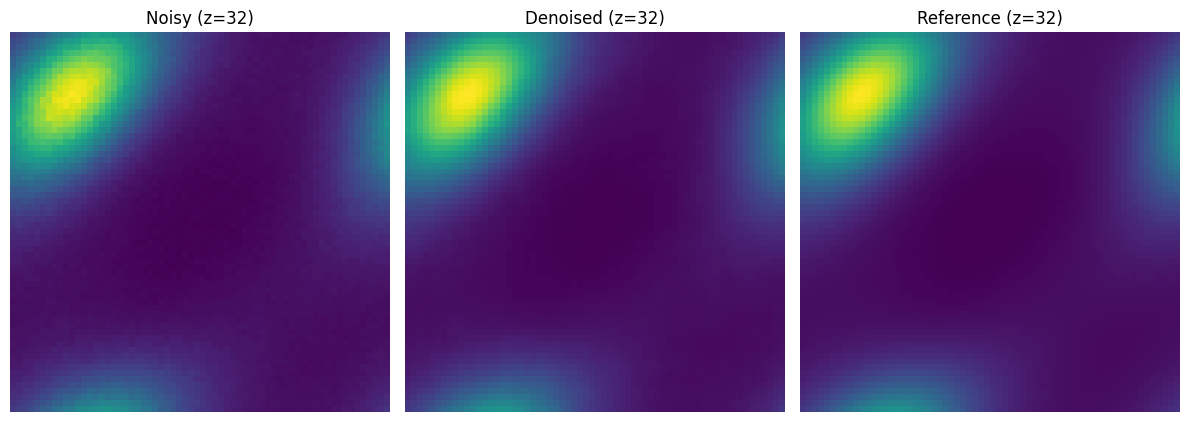

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000062
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


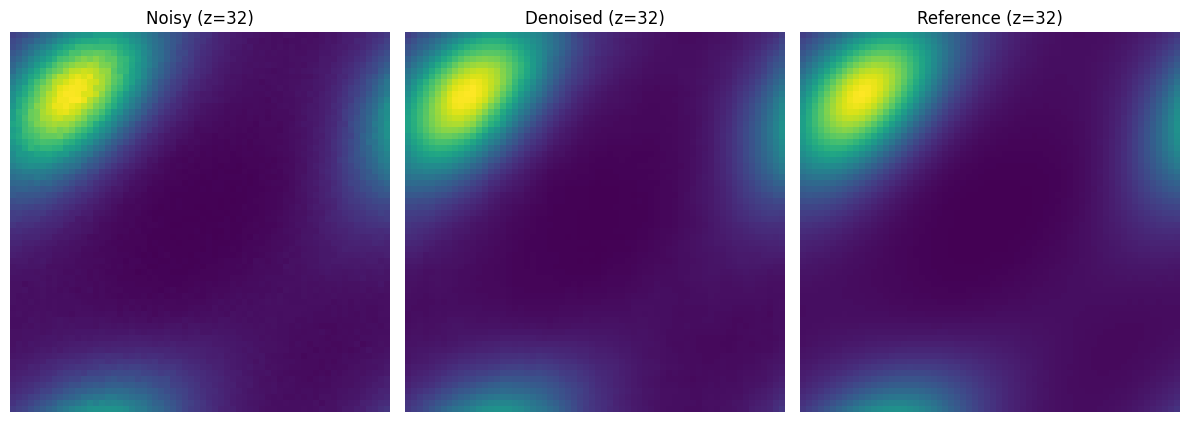

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000046
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


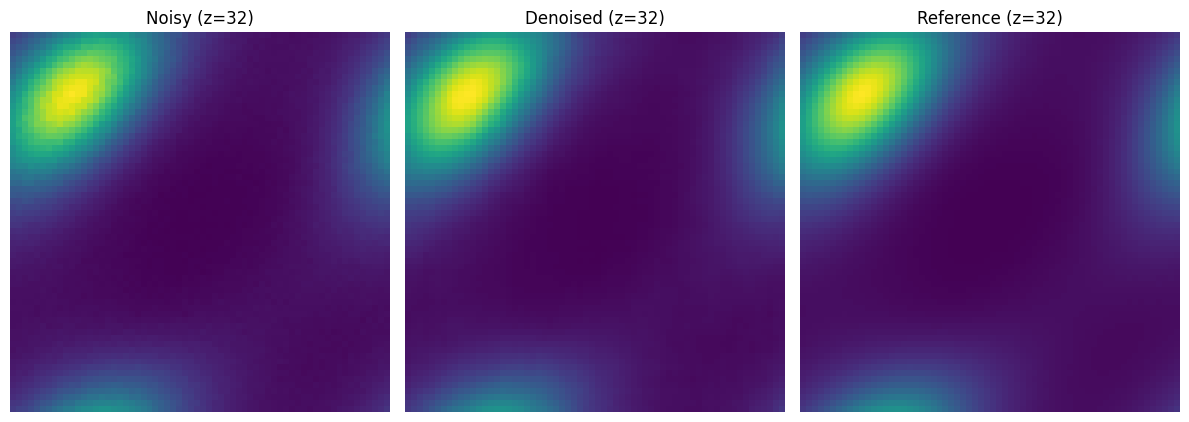

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000031
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


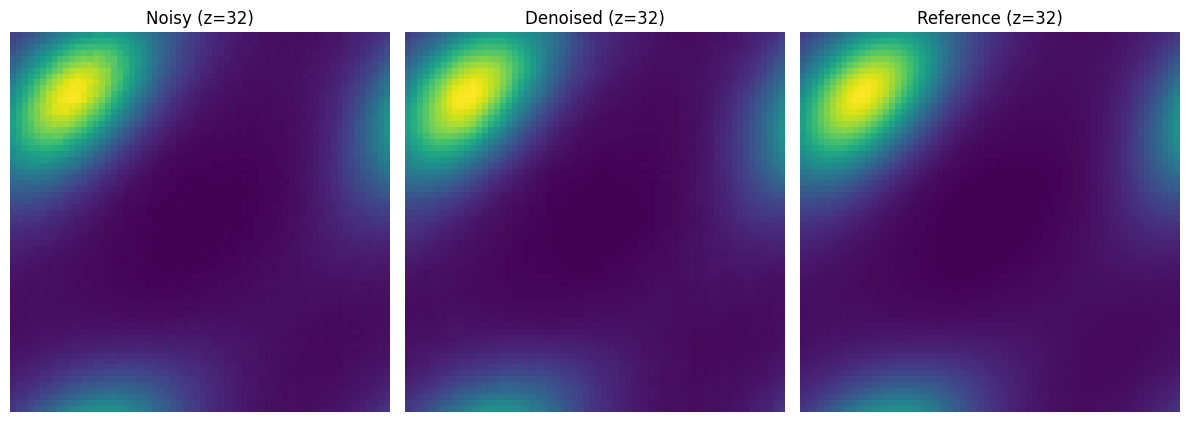

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000024
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


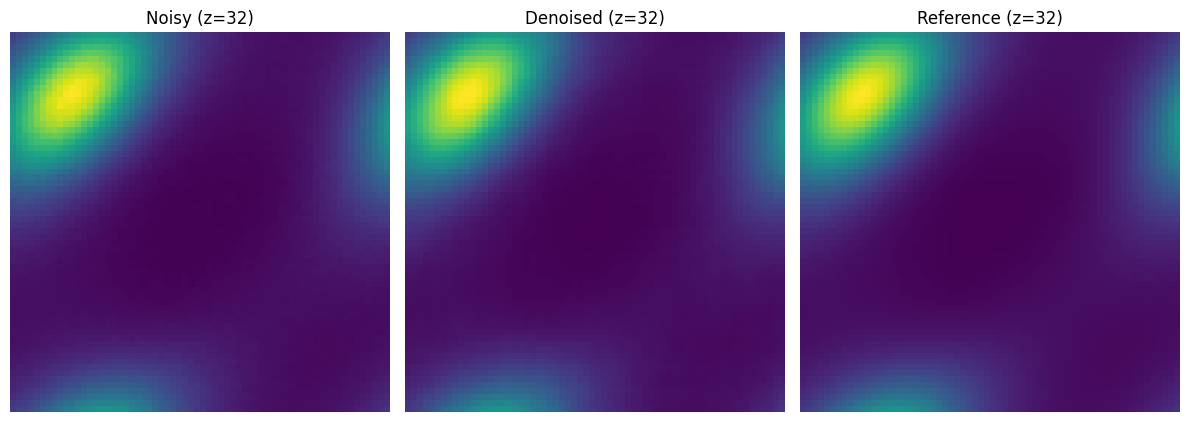

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


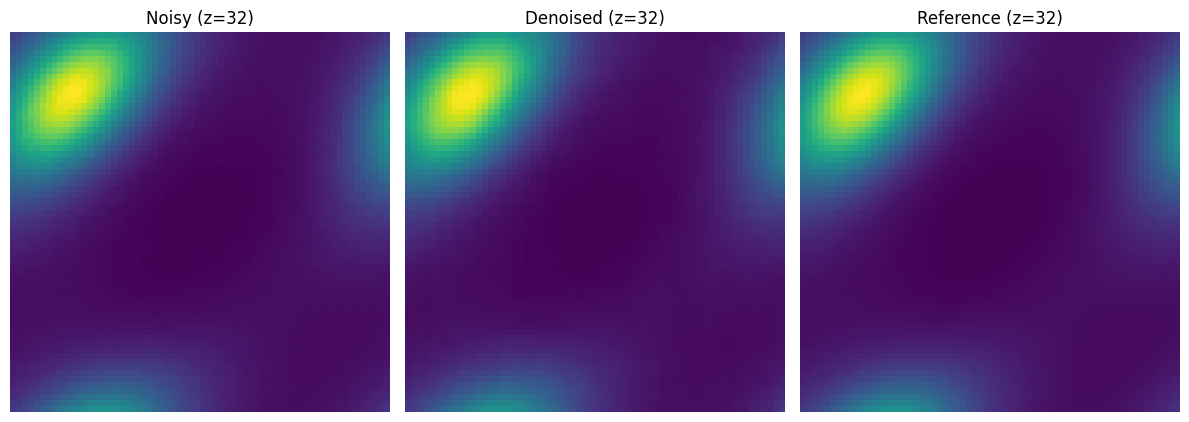

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000012
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


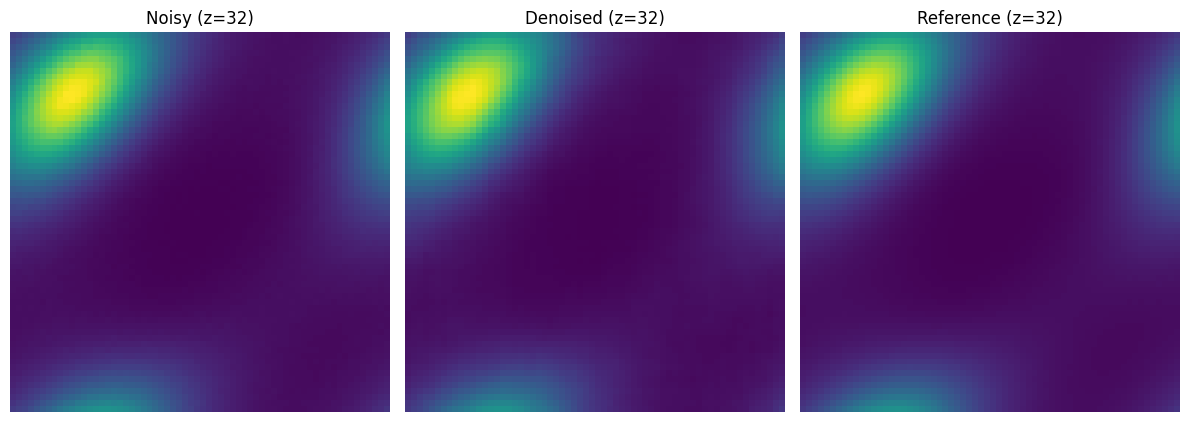

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


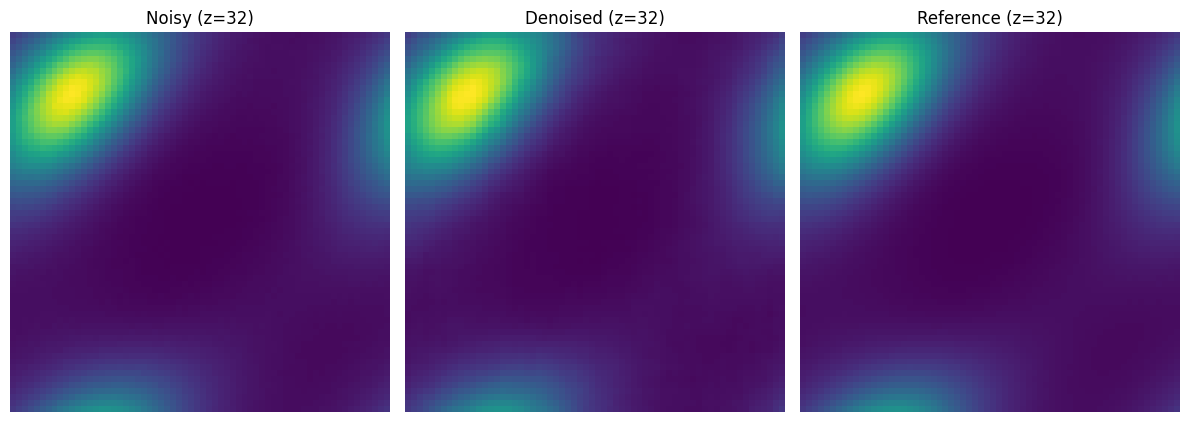

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


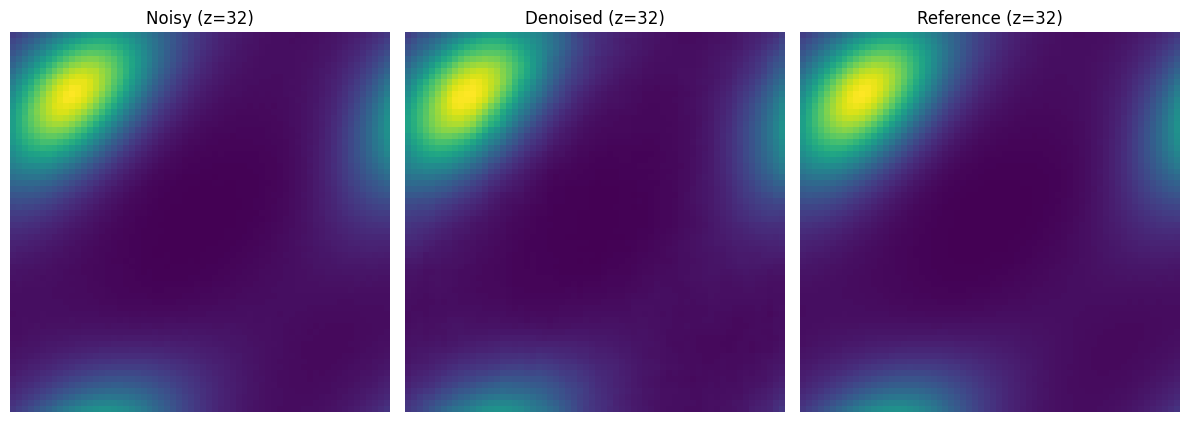

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


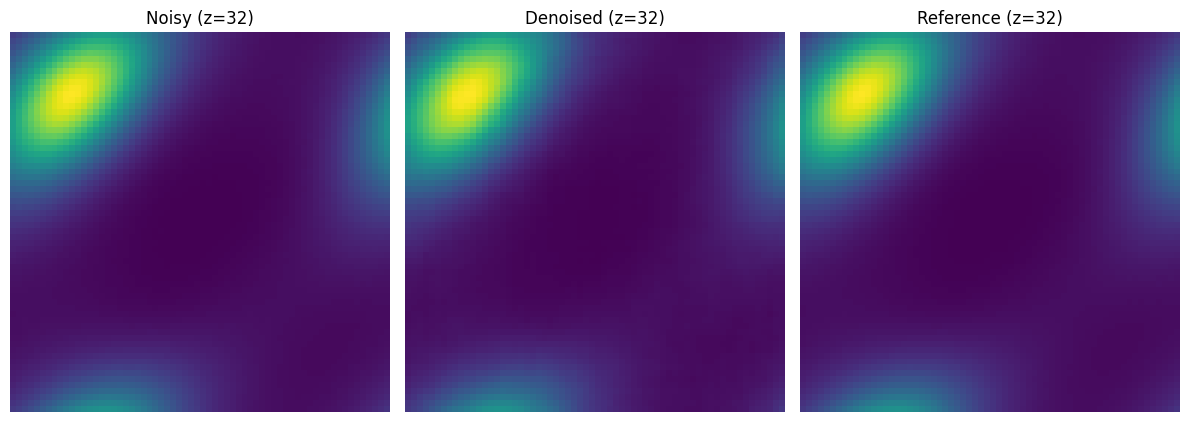

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000091
(64, 64, 64) (64, 64, 64) (64, 64, 64)


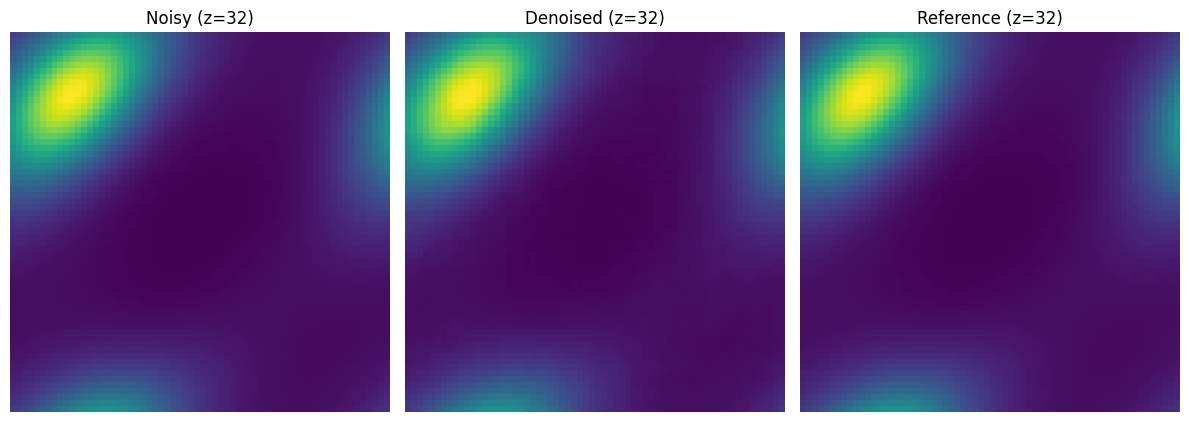


=== Running model: 2385000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 760ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.326098
JSD   (denoised vs ref):  0.000788
(64, 64, 64) (64, 64, 64) (64, 64, 64)


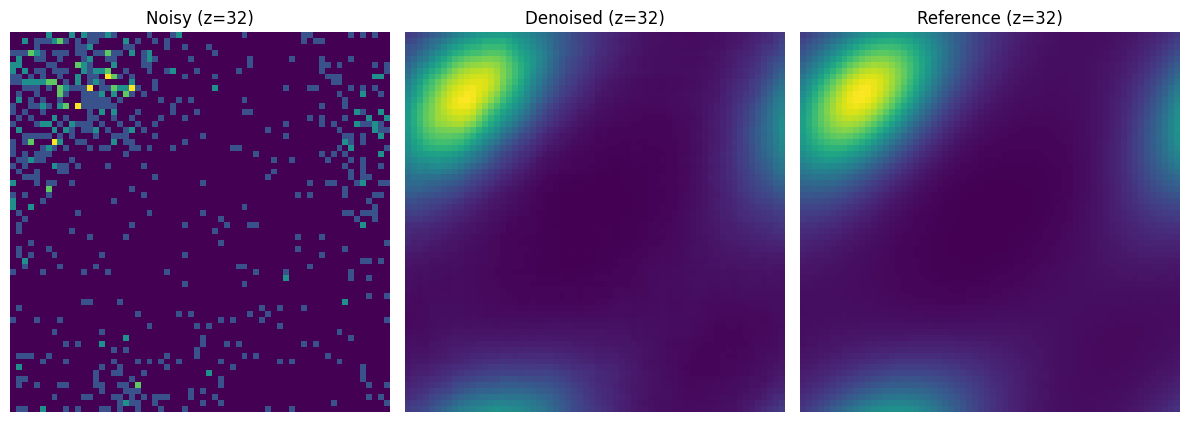

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.219943
JSD   (denoised vs ref):  0.000772
(64, 64, 64) (64, 64, 64) (64, 64, 64)


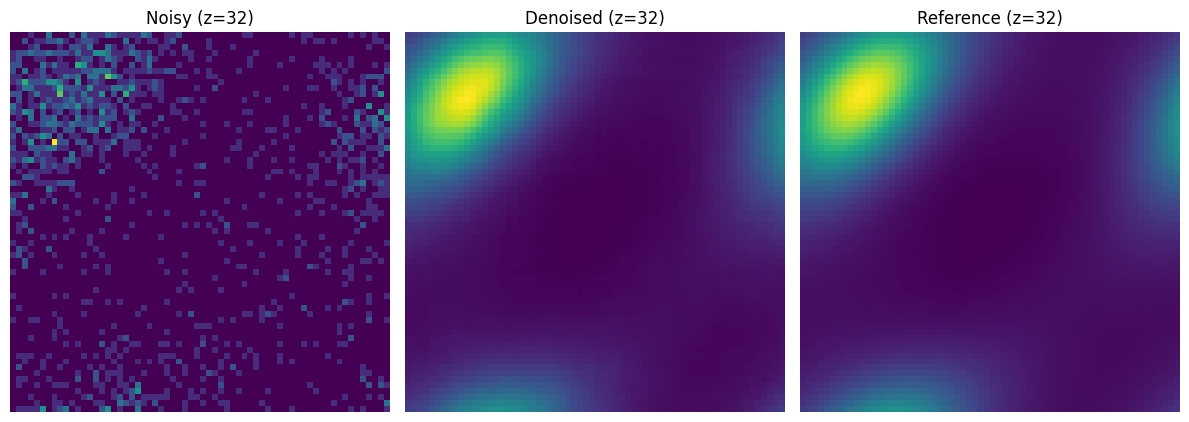

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.132102
JSD   (denoised vs ref):  0.000761
(64, 64, 64) (64, 64, 64) (64, 64, 64)


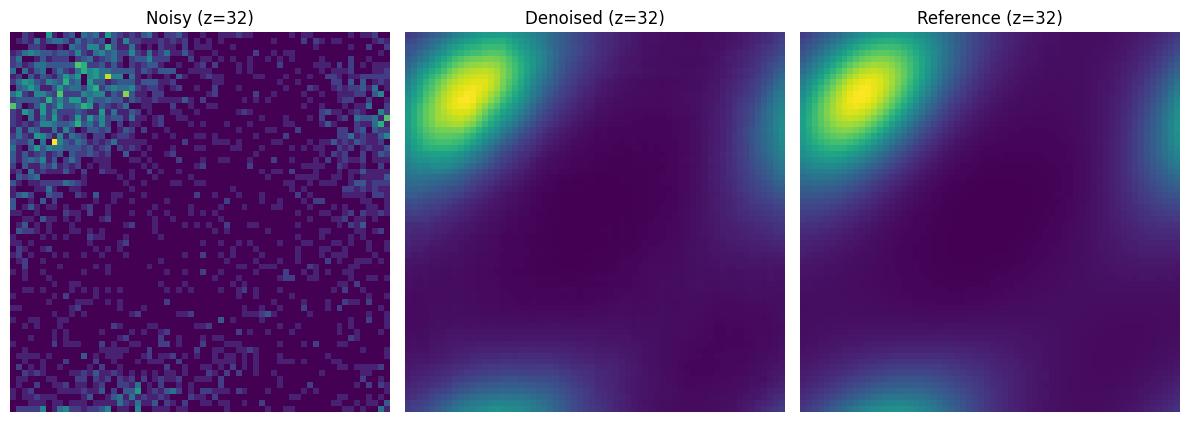

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.072527
JSD   (denoised vs ref):  0.000755
(64, 64, 64) (64, 64, 64) (64, 64, 64)


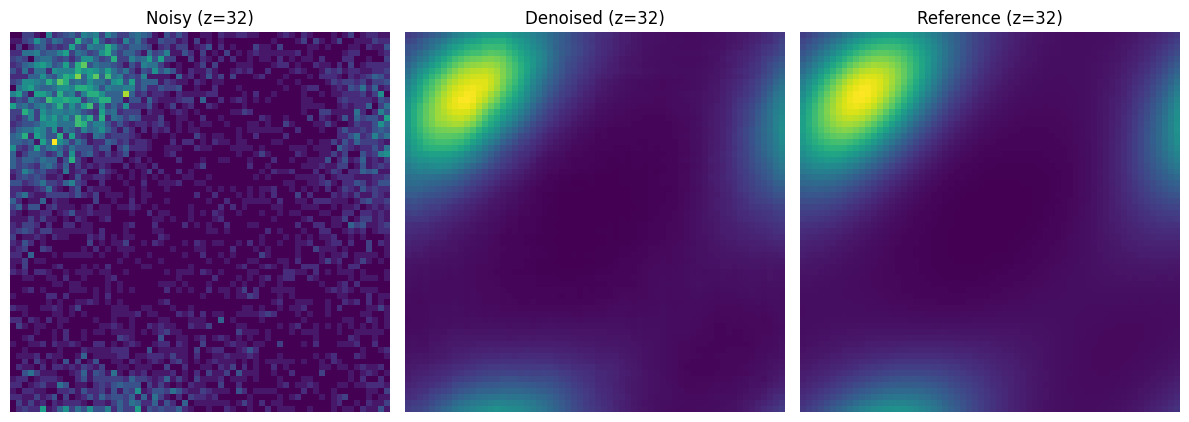

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.036875
JSD   (denoised vs ref):  0.000750
(64, 64, 64) (64, 64, 64) (64, 64, 64)


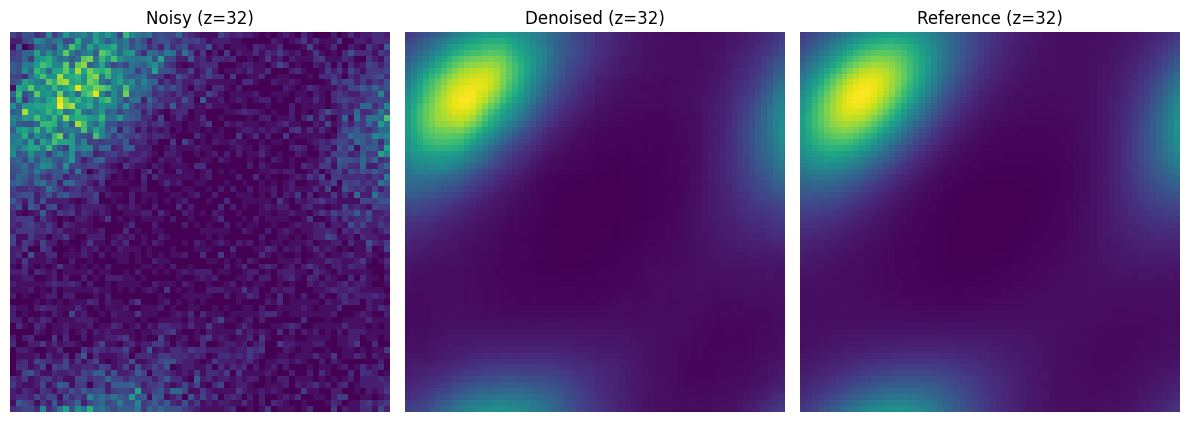

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.017617
JSD   (denoised vs ref):  0.000748
(64, 64, 64) (64, 64, 64) (64, 64, 64)


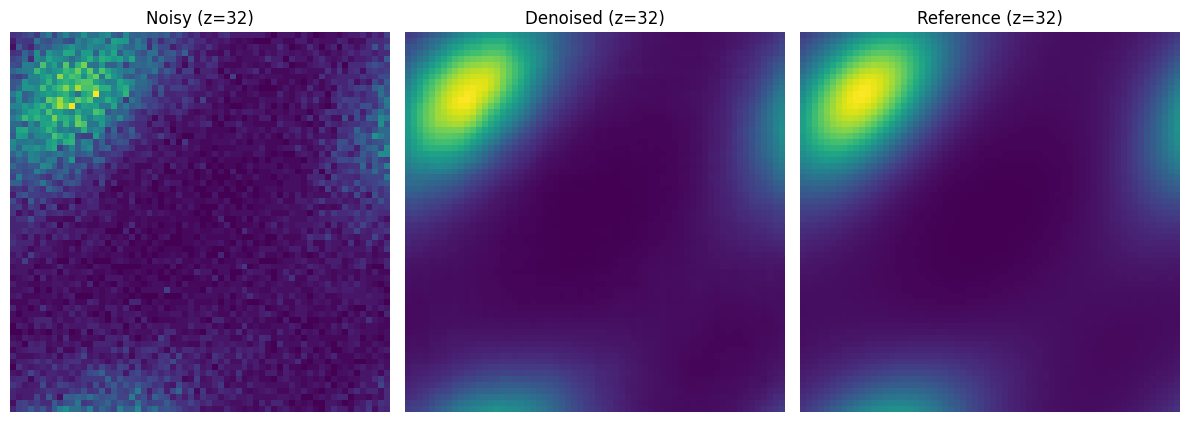

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.013049
JSD   (denoised vs ref):  0.000747
(64, 64, 64) (64, 64, 64) (64, 64, 64)


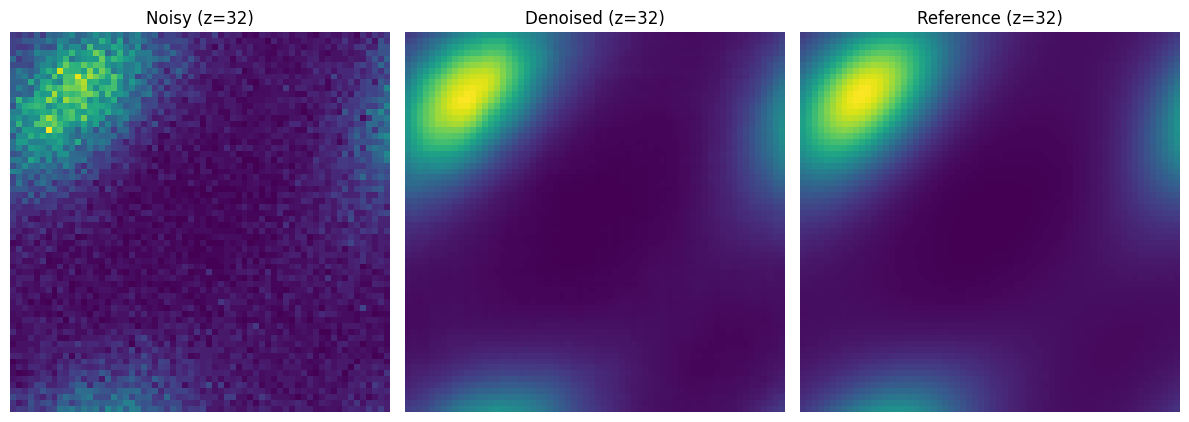

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.008181
JSD   (denoised vs ref):  0.000747
(64, 64, 64) (64, 64, 64) (64, 64, 64)


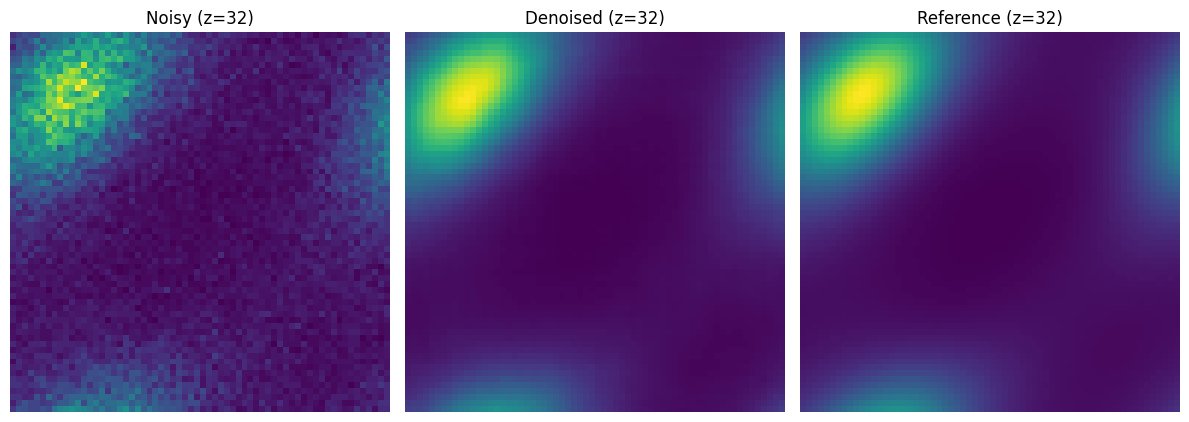

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.006157
JSD   (denoised vs ref):  0.000745
(64, 64, 64) (64, 64, 64) (64, 64, 64)


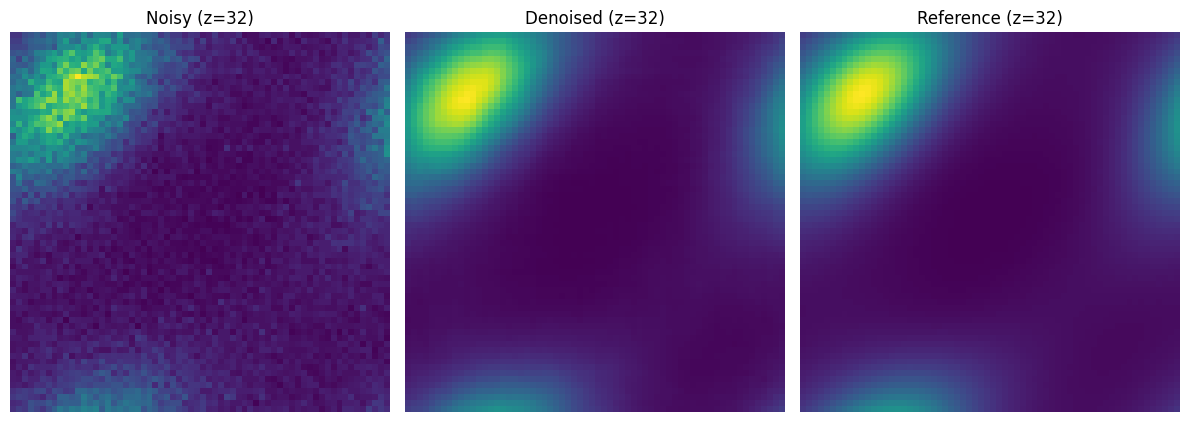

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.003937
JSD   (denoised vs ref):  0.000744
(64, 64, 64) (64, 64, 64) (64, 64, 64)


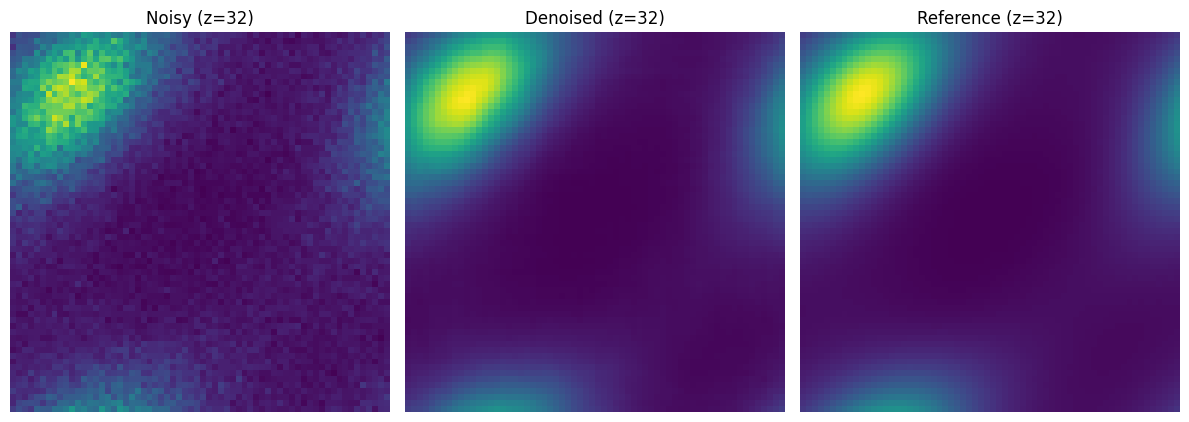

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.002993
JSD   (denoised vs ref):  0.000744
(64, 64, 64) (64, 64, 64) (64, 64, 64)


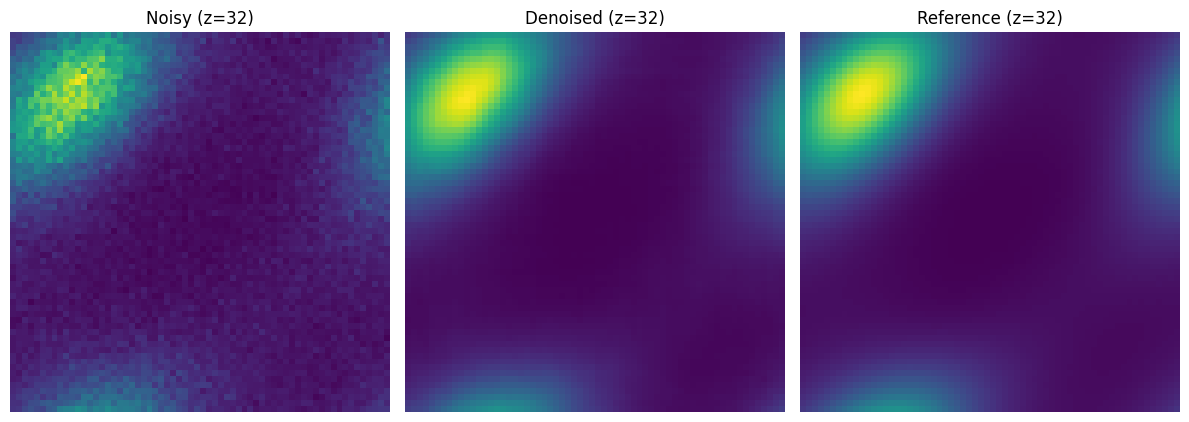

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001939
JSD   (denoised vs ref):  0.000745
(64, 64, 64) (64, 64, 64) (64, 64, 64)


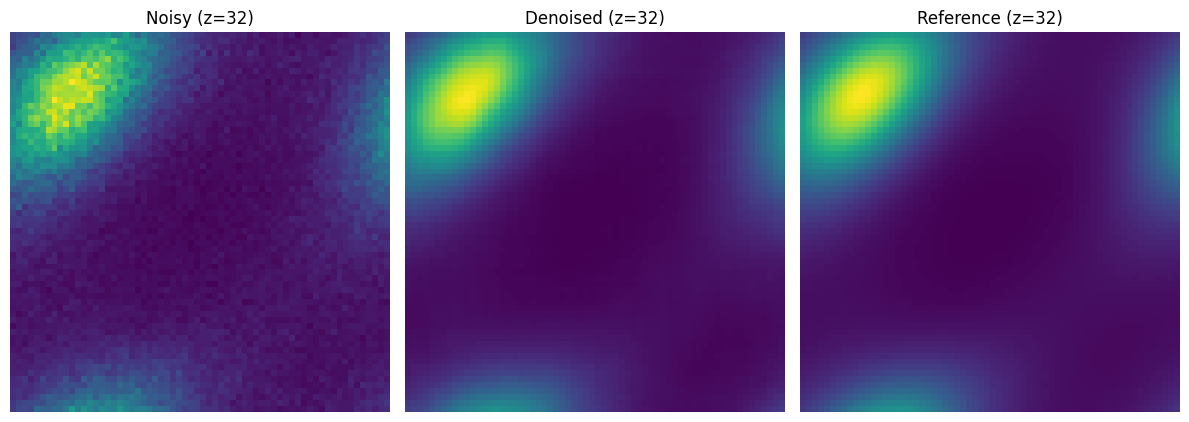

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.001476
JSD   (denoised vs ref):  0.000744
(64, 64, 64) (64, 64, 64) (64, 64, 64)


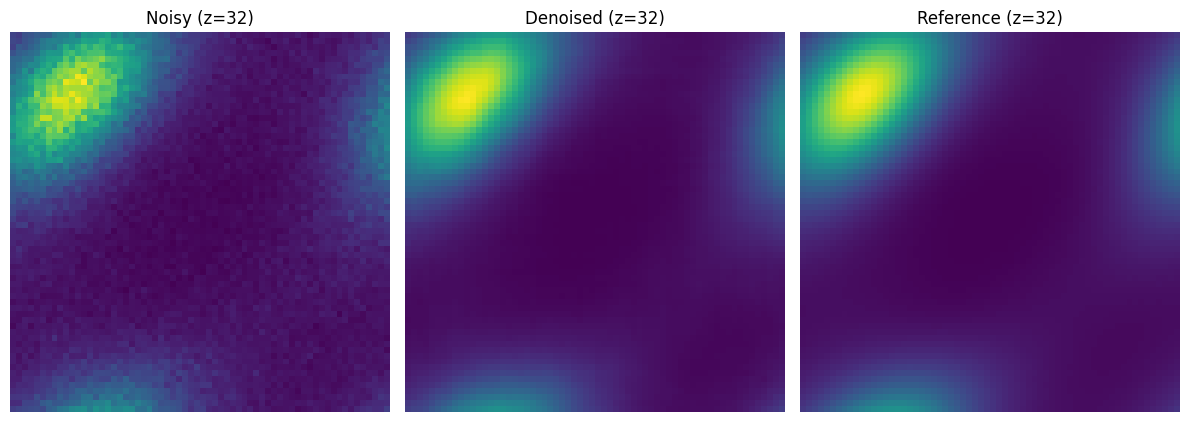

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000984
JSD   (denoised vs ref):  0.000743
(64, 64, 64) (64, 64, 64) (64, 64, 64)


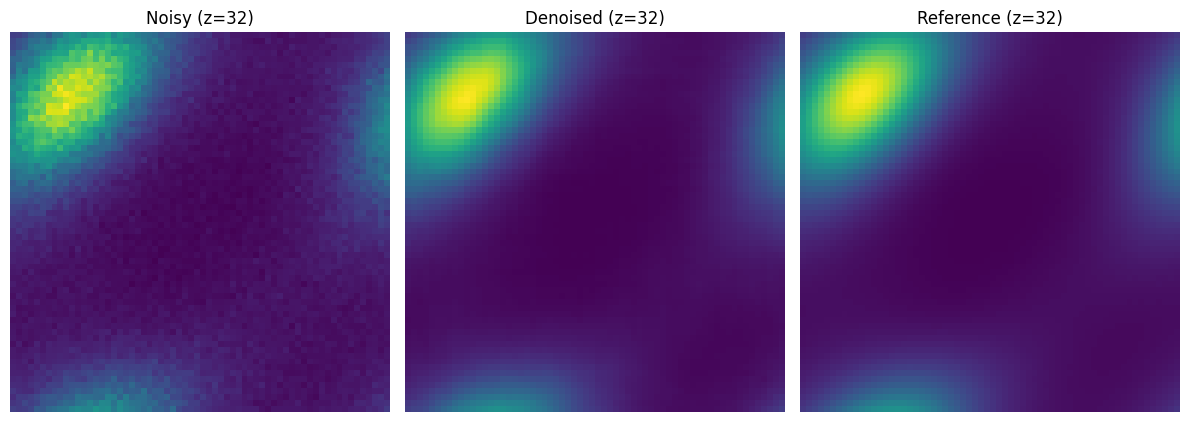

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000966
JSD   (denoised vs ref):  0.000744
(64, 64, 64) (64, 64, 64) (64, 64, 64)


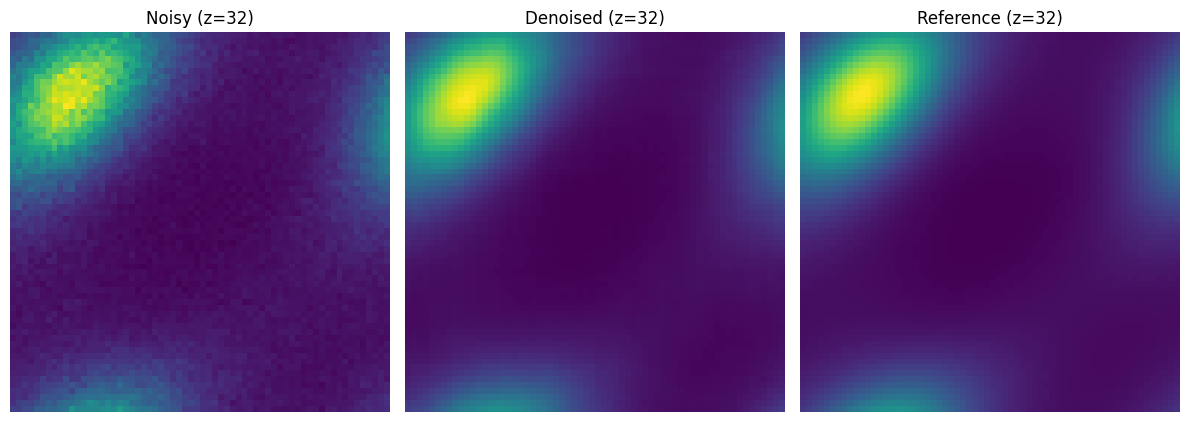

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000735
JSD   (denoised vs ref):  0.000744
(64, 64, 64) (64, 64, 64) (64, 64, 64)


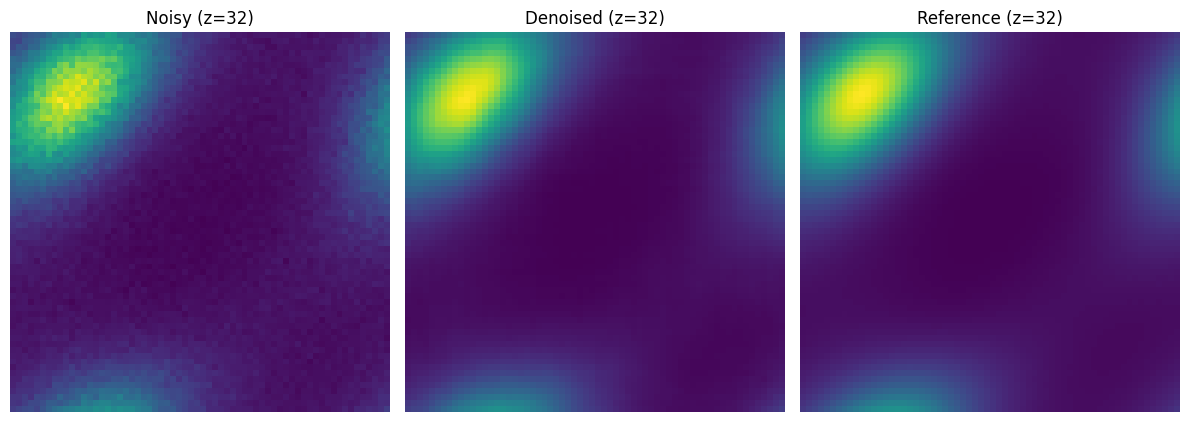

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000491
JSD   (denoised vs ref):  0.000743
(64, 64, 64) (64, 64, 64) (64, 64, 64)


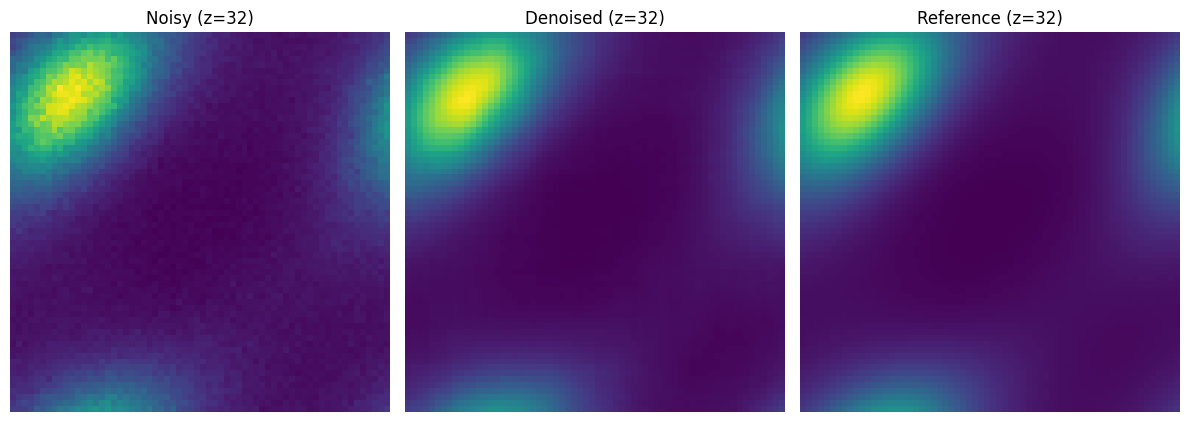

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000482
JSD   (denoised vs ref):  0.000743
(64, 64, 64) (64, 64, 64) (64, 64, 64)


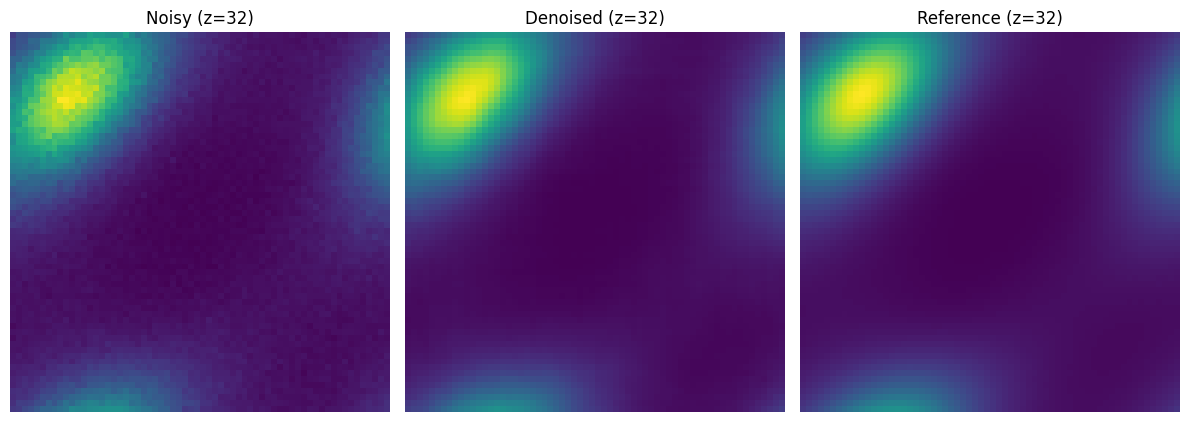

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000367
JSD   (denoised vs ref):  0.000744
(64, 64, 64) (64, 64, 64) (64, 64, 64)


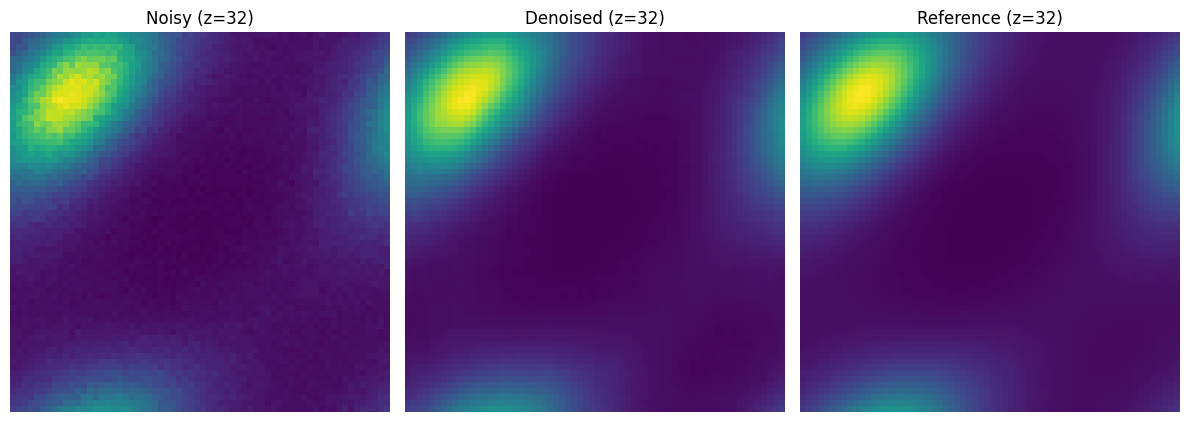

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000245
JSD   (denoised vs ref):  0.000744
(64, 64, 64) (64, 64, 64) (64, 64, 64)


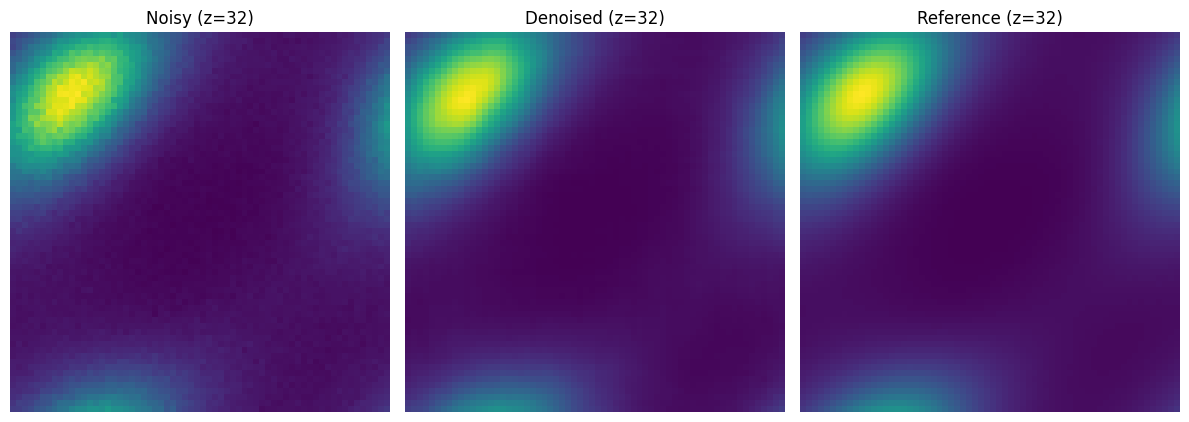

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000184
JSD   (denoised vs ref):  0.000743
(64, 64, 64) (64, 64, 64) (64, 64, 64)


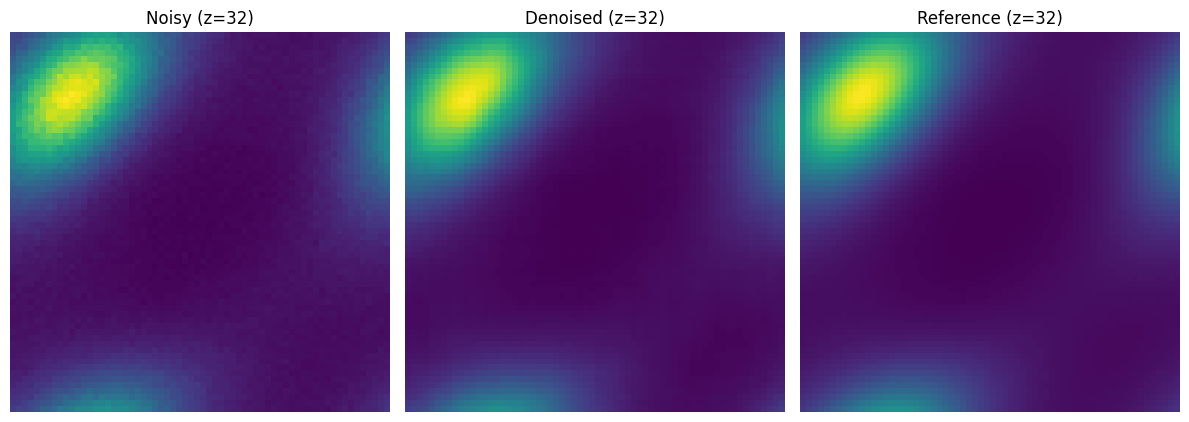

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000123
JSD   (denoised vs ref):  0.000743
(64, 64, 64) (64, 64, 64) (64, 64, 64)


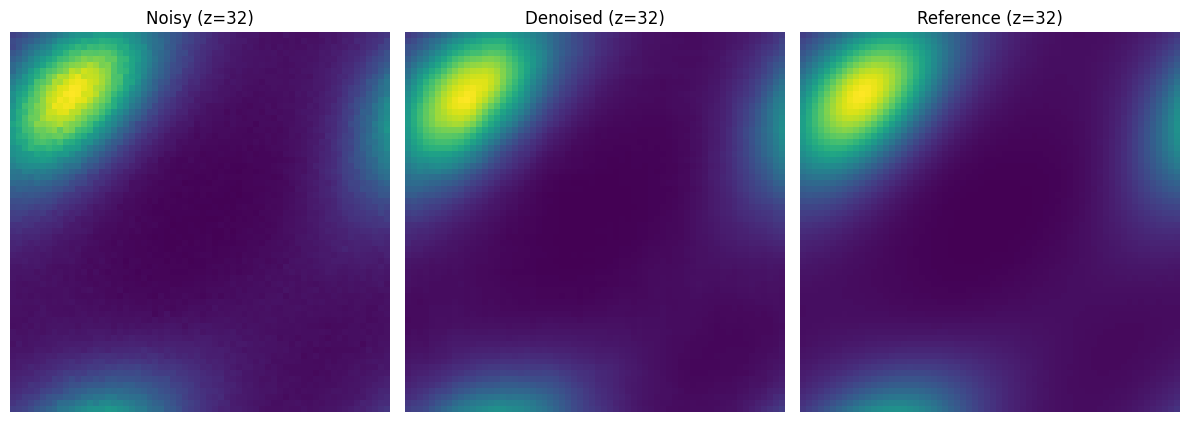

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000092
JSD   (denoised vs ref):  0.000743
(64, 64, 64) (64, 64, 64) (64, 64, 64)


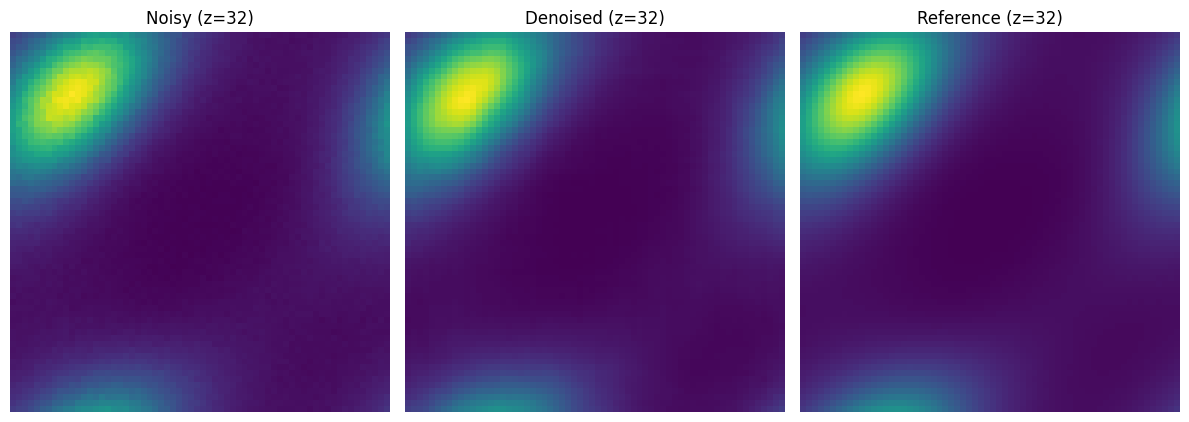

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000062
JSD   (denoised vs ref):  0.000743
(64, 64, 64) (64, 64, 64) (64, 64, 64)


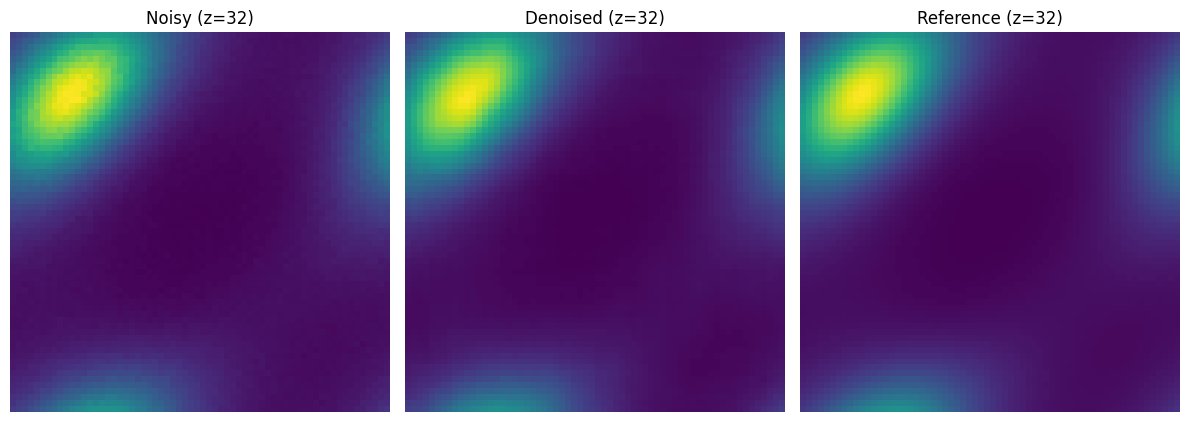

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000046
JSD   (denoised vs ref):  0.000743
(64, 64, 64) (64, 64, 64) (64, 64, 64)


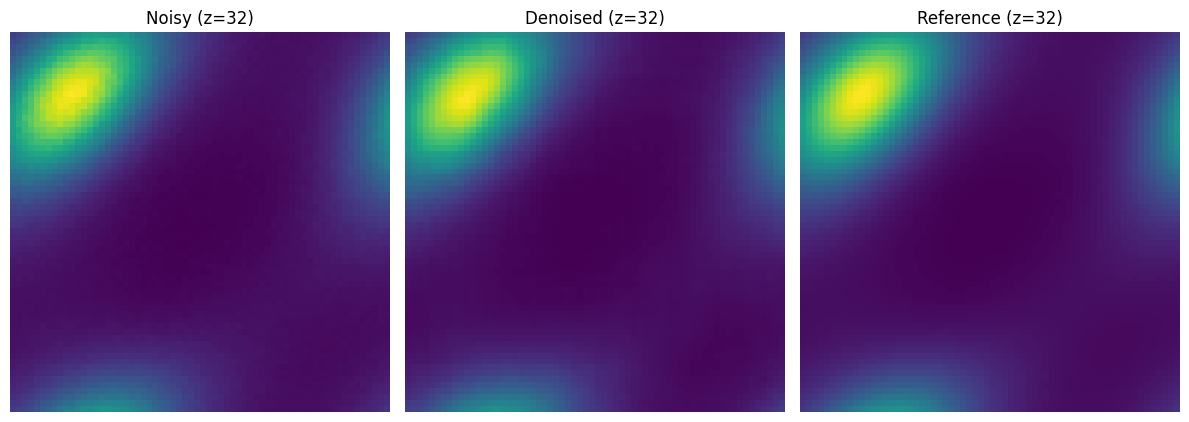

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000031
JSD   (denoised vs ref):  0.000743
(64, 64, 64) (64, 64, 64) (64, 64, 64)


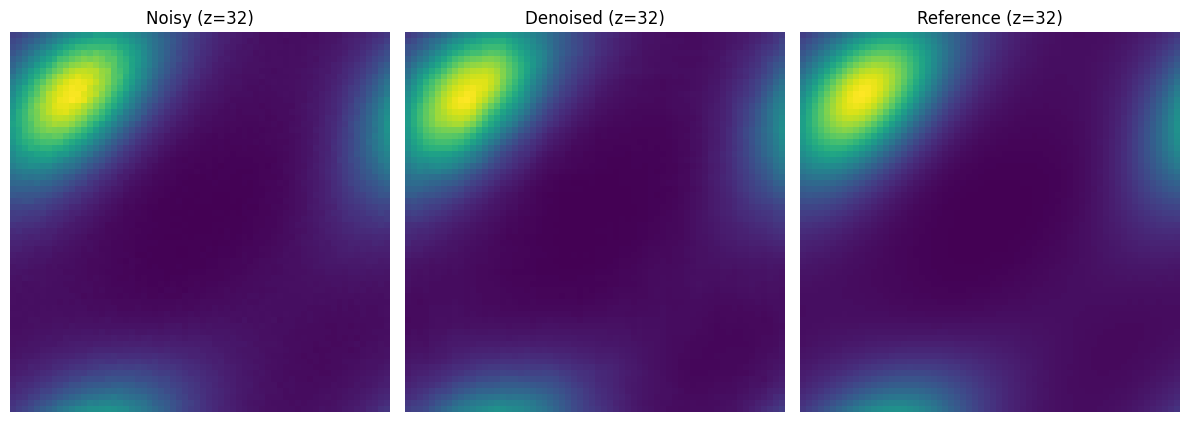

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000024
JSD   (denoised vs ref):  0.000744
(64, 64, 64) (64, 64, 64) (64, 64, 64)


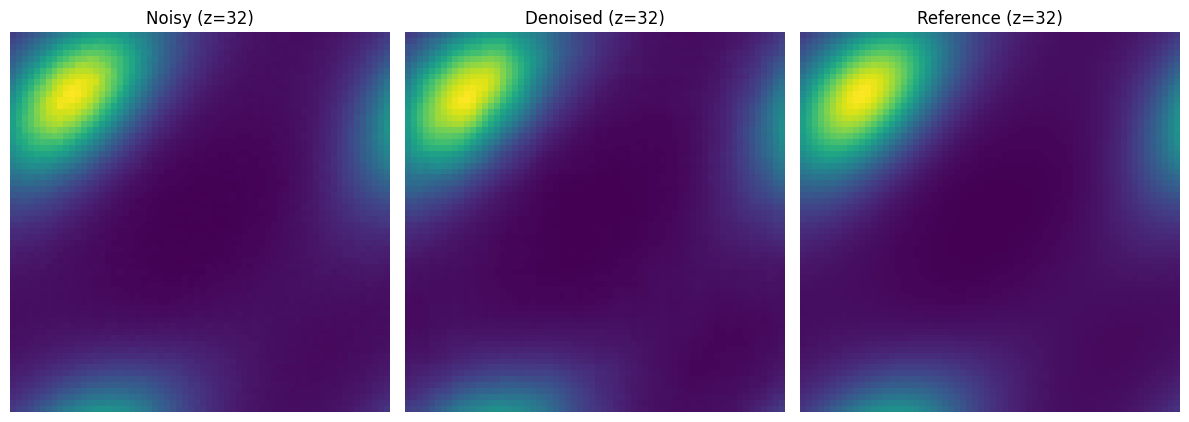

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000742
(64, 64, 64) (64, 64, 64) (64, 64, 64)


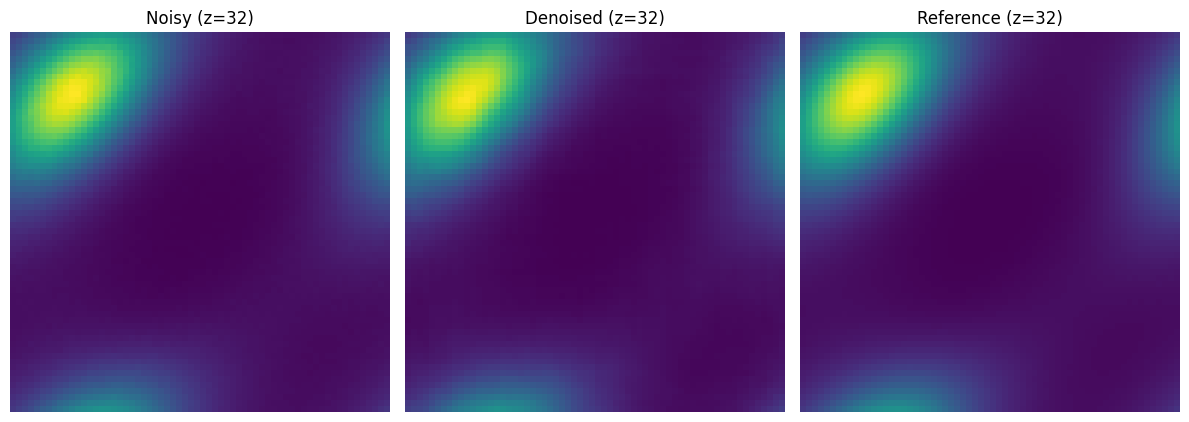

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000012
JSD   (denoised vs ref):  0.000745
(64, 64, 64) (64, 64, 64) (64, 64, 64)


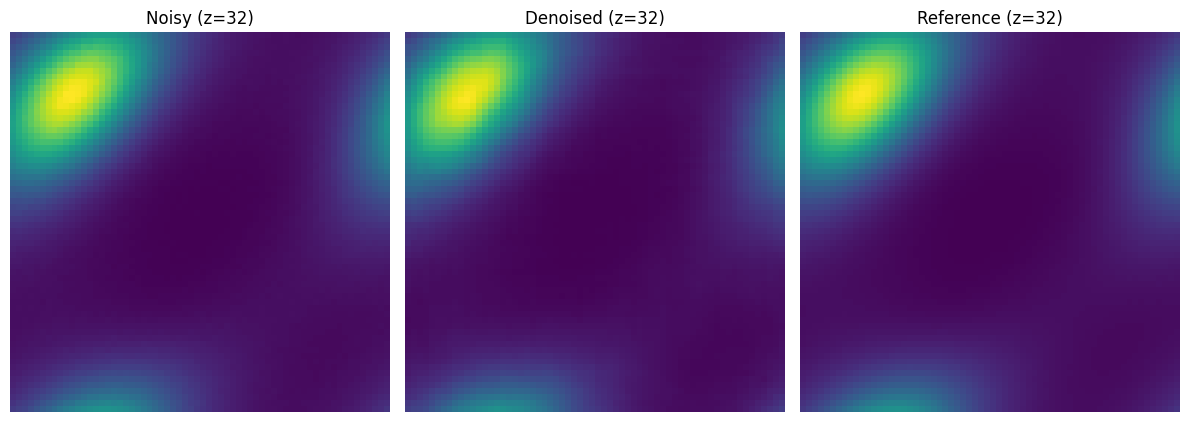

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000743
(64, 64, 64) (64, 64, 64) (64, 64, 64)


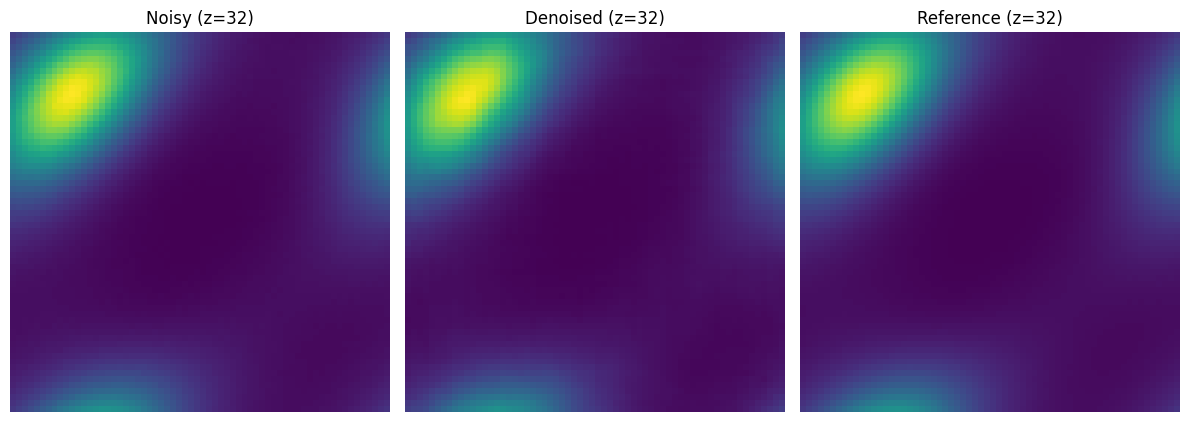

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000744
(64, 64, 64) (64, 64, 64) (64, 64, 64)


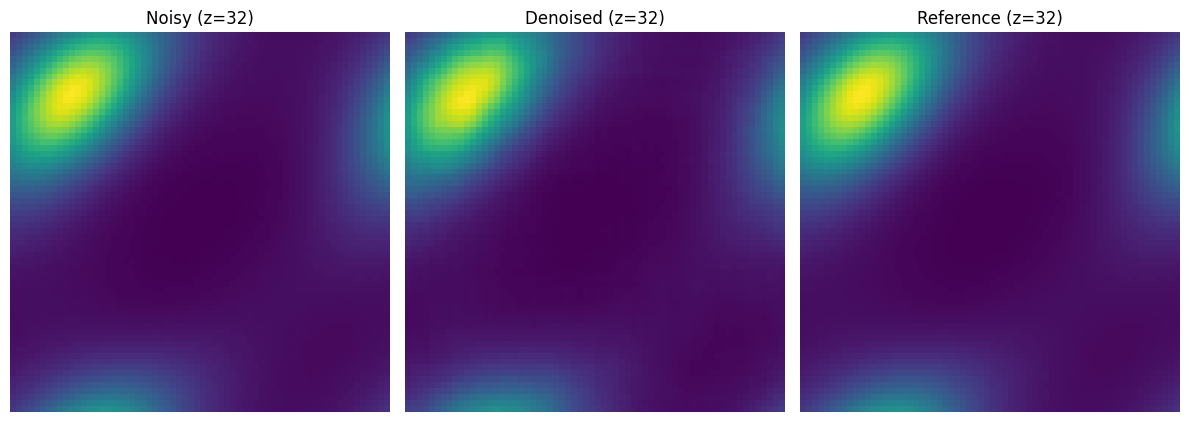

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000744
(64, 64, 64) (64, 64, 64) (64, 64, 64)


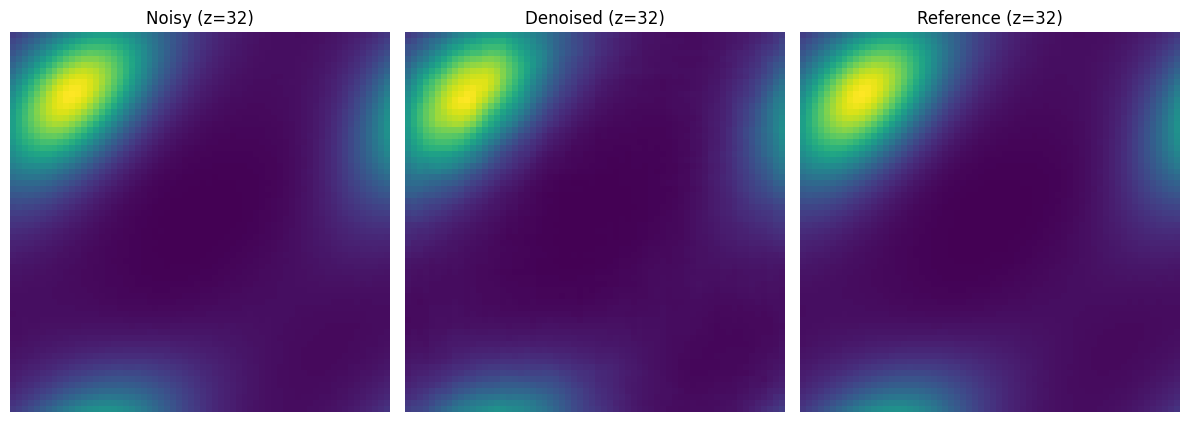

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000743
(64, 64, 64) (64, 64, 64) (64, 64, 64)


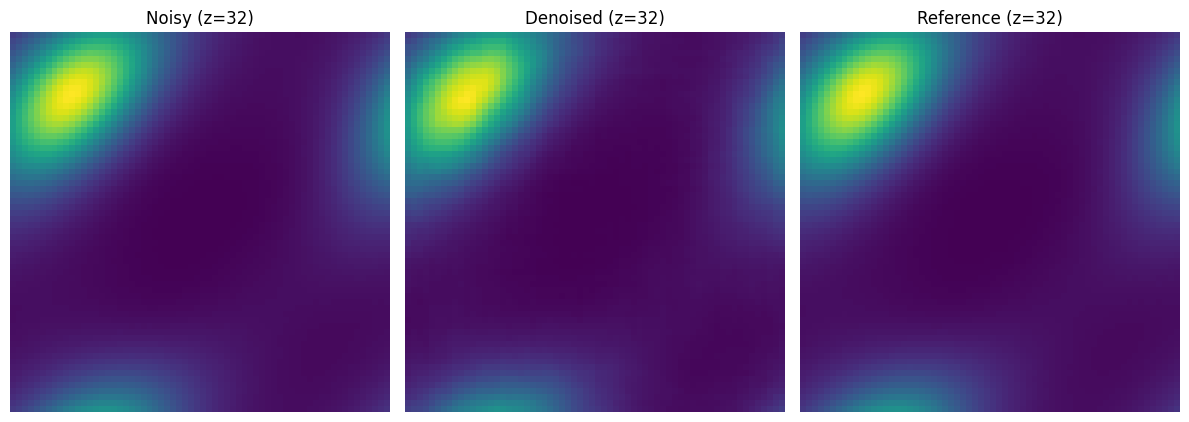


=== Running model: 238800000000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.326098
JSD   (denoised vs ref):  0.000083
(64, 64, 64) (64, 64, 64) (64, 64, 64)


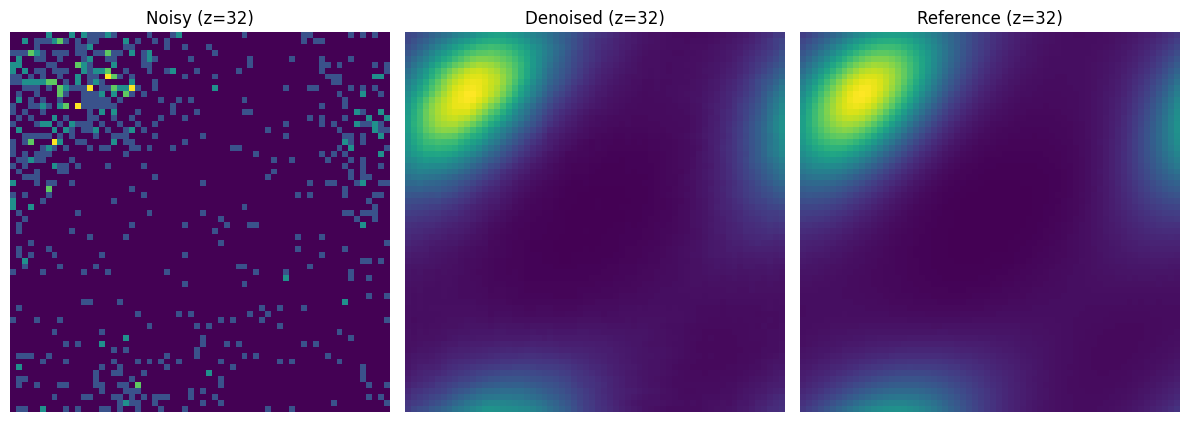

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.219943
JSD   (denoised vs ref):  0.000078
(64, 64, 64) (64, 64, 64) (64, 64, 64)


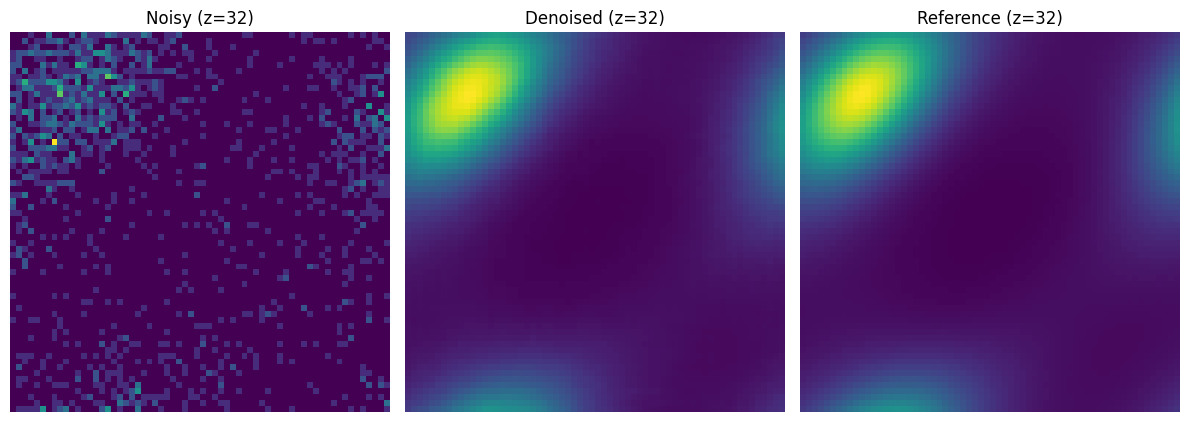

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.132102
JSD   (denoised vs ref):  0.000076
(64, 64, 64) (64, 64, 64) (64, 64, 64)


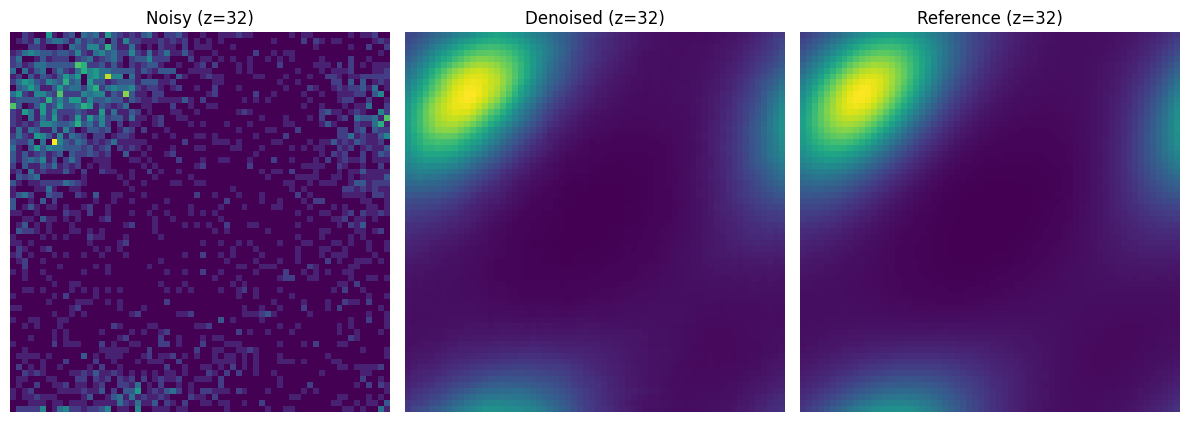

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.072527
JSD   (denoised vs ref):  0.000075
(64, 64, 64) (64, 64, 64) (64, 64, 64)


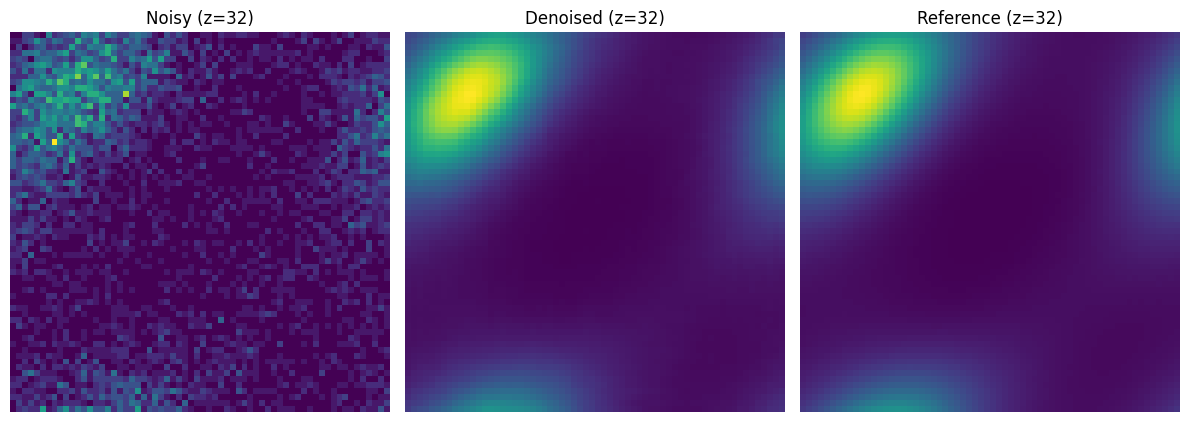

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.036875
JSD   (denoised vs ref):  0.000075
(64, 64, 64) (64, 64, 64) (64, 64, 64)


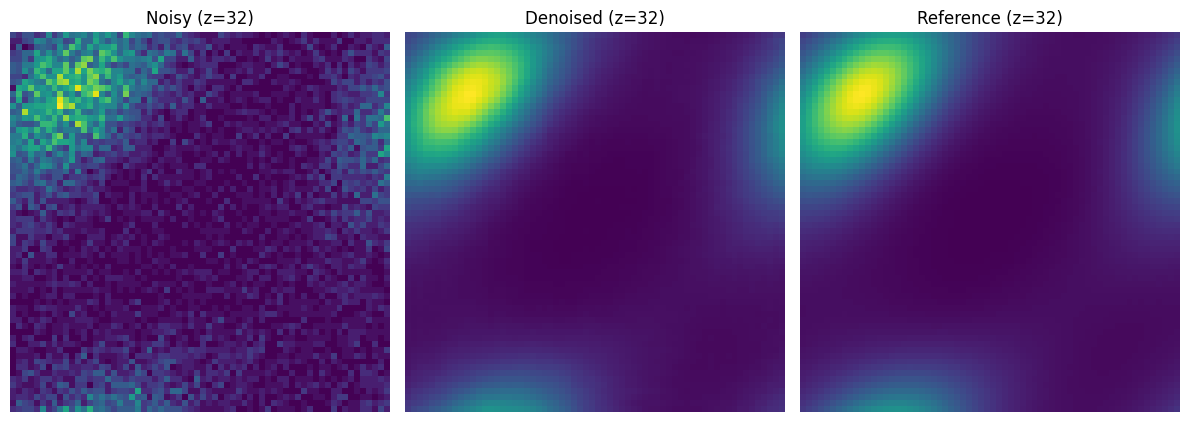

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.017617
JSD   (denoised vs ref):  0.000075
(64, 64, 64) (64, 64, 64) (64, 64, 64)


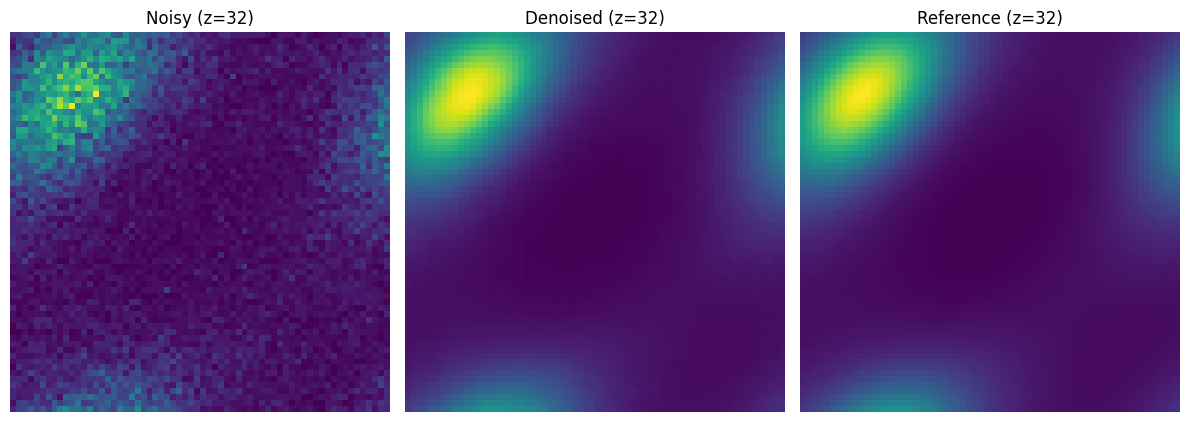

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.013049
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


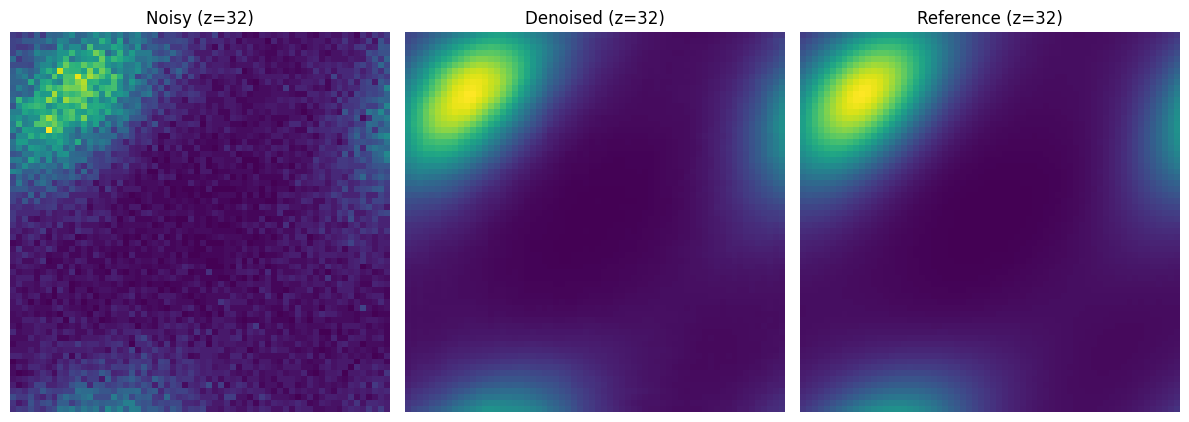

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.008181
JSD   (denoised vs ref):  0.000075
(64, 64, 64) (64, 64, 64) (64, 64, 64)


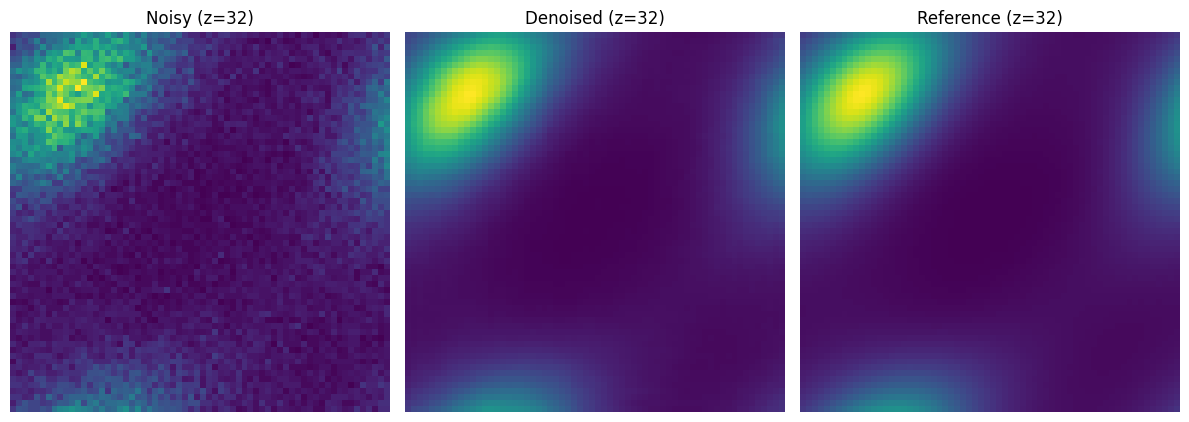

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.006157
JSD   (denoised vs ref):  0.000075
(64, 64, 64) (64, 64, 64) (64, 64, 64)


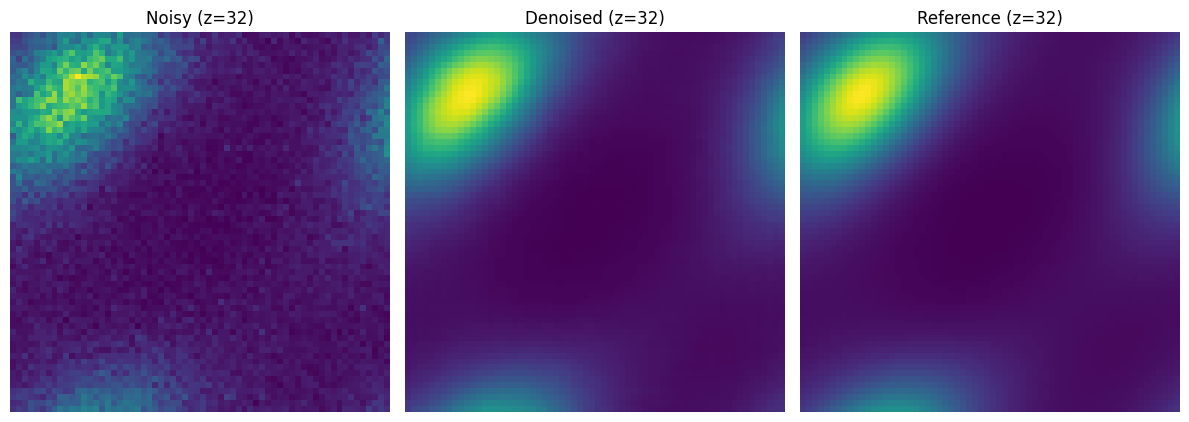

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.003937
JSD   (denoised vs ref):  0.000075
(64, 64, 64) (64, 64, 64) (64, 64, 64)


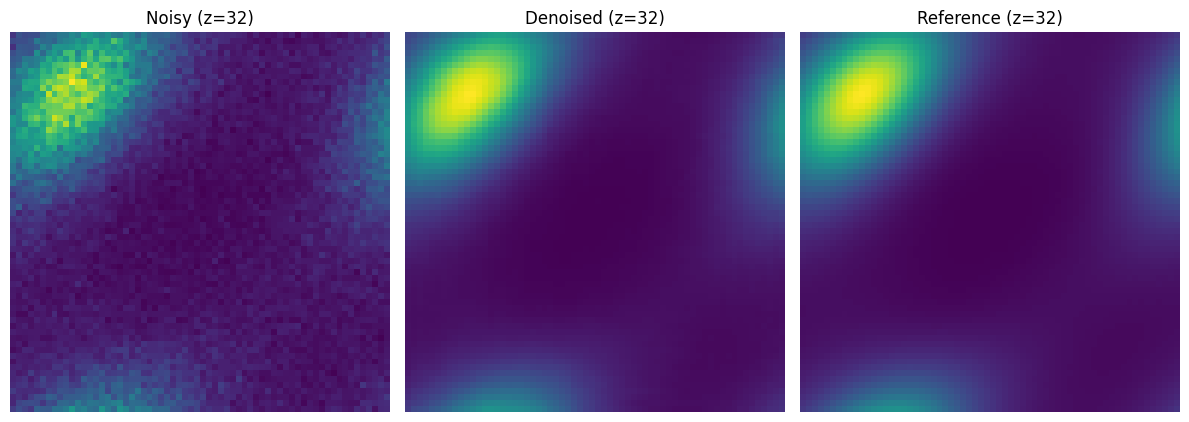

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.002993
JSD   (denoised vs ref):  0.000075
(64, 64, 64) (64, 64, 64) (64, 64, 64)


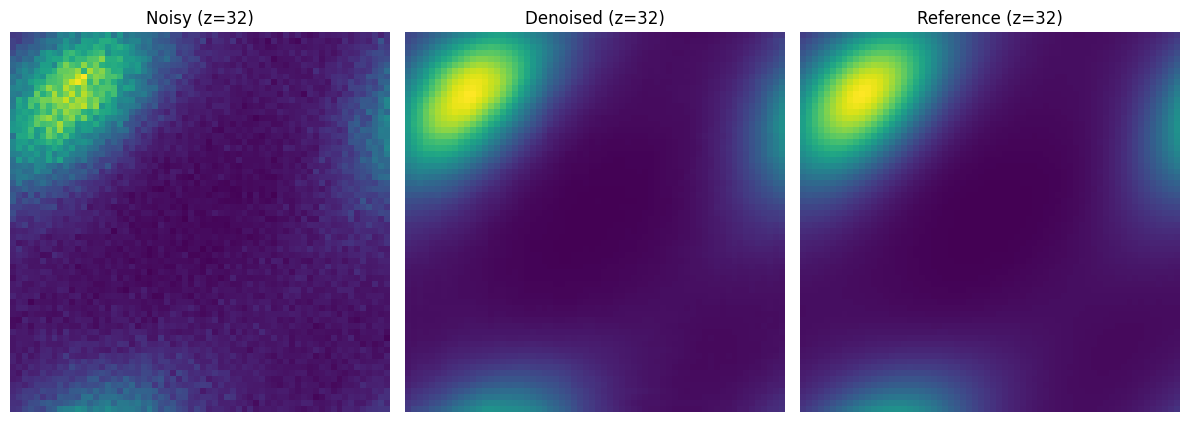

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.001939
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


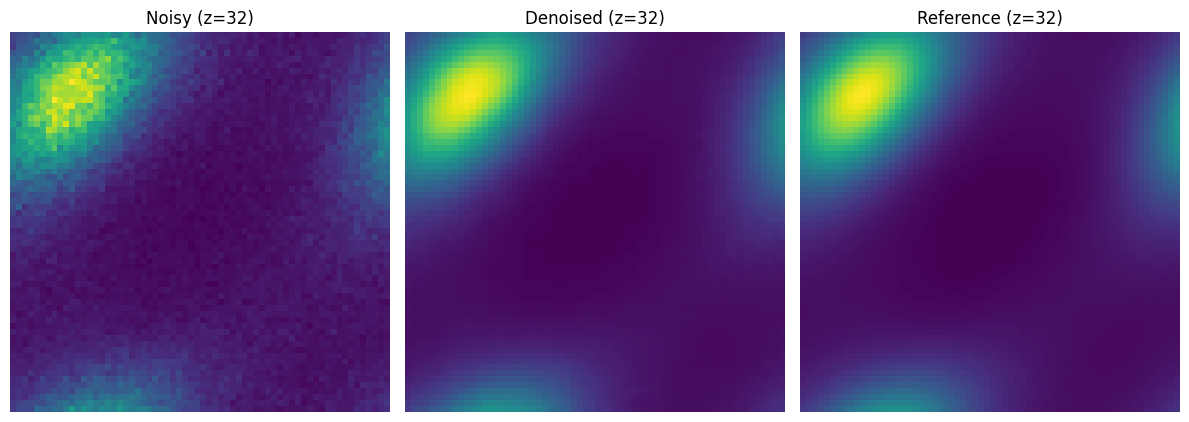

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.001476
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


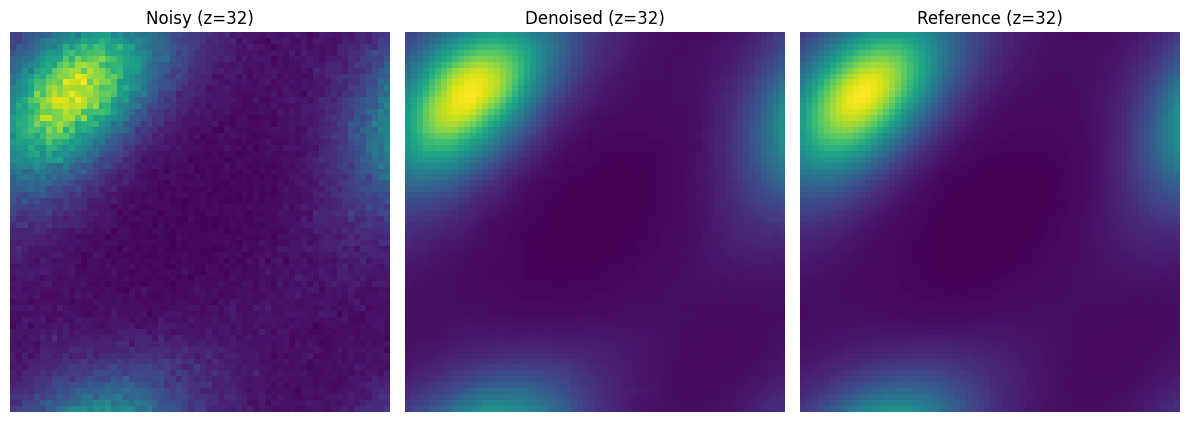

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000984
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


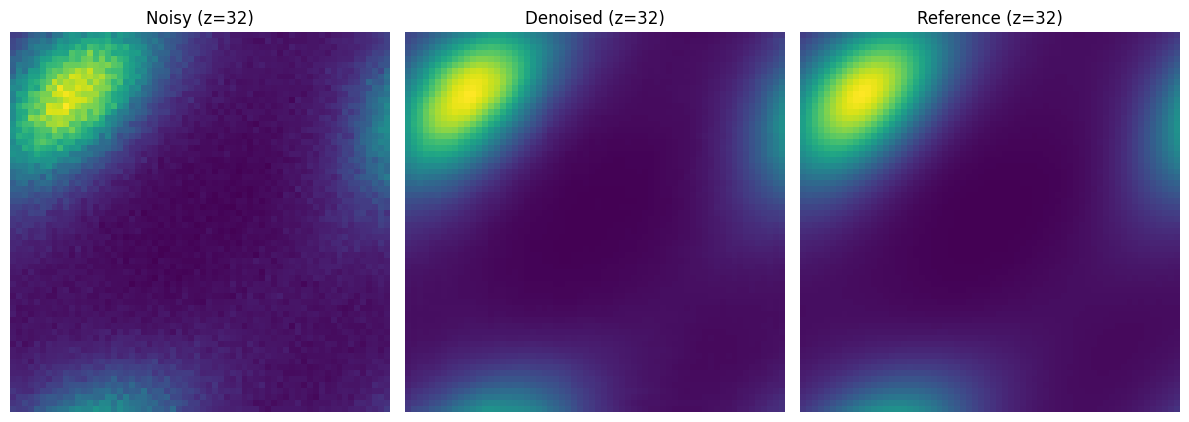

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000966
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


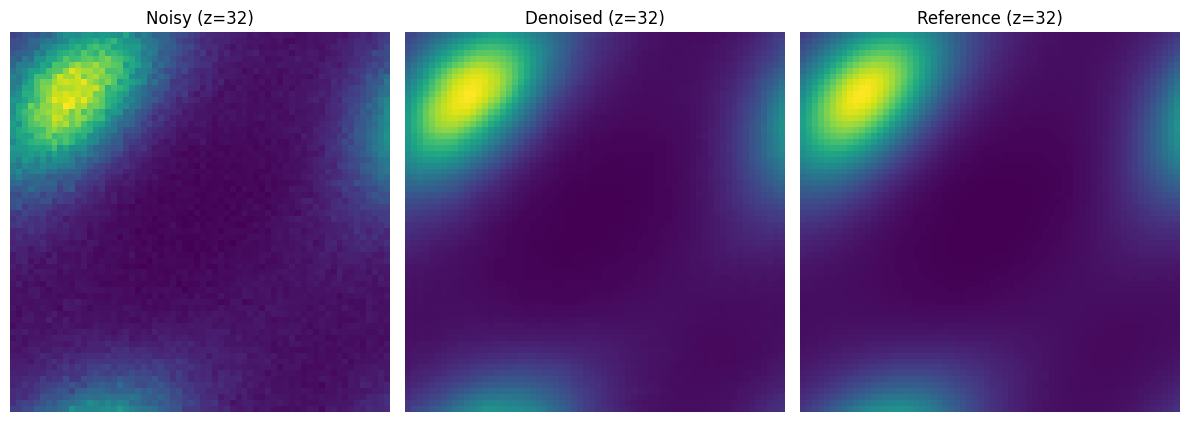

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000735
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


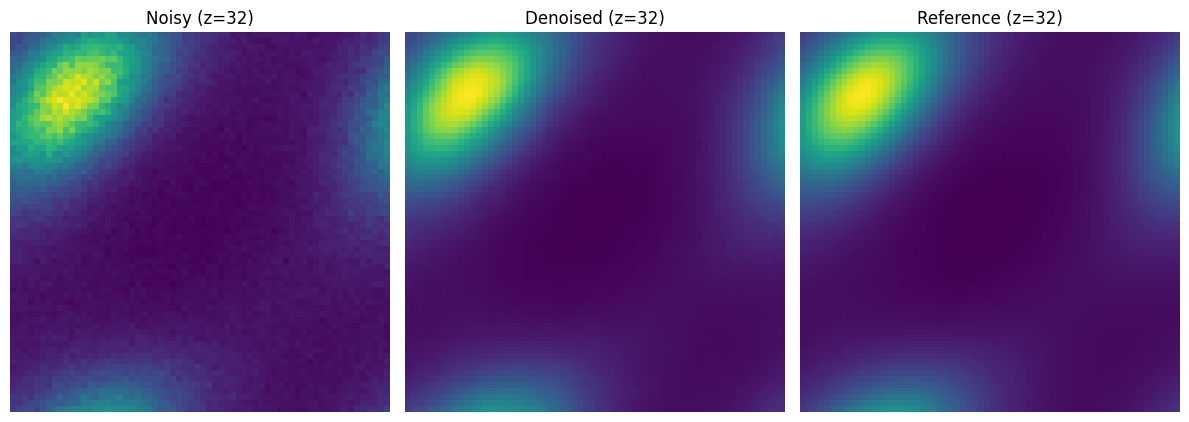

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000491
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


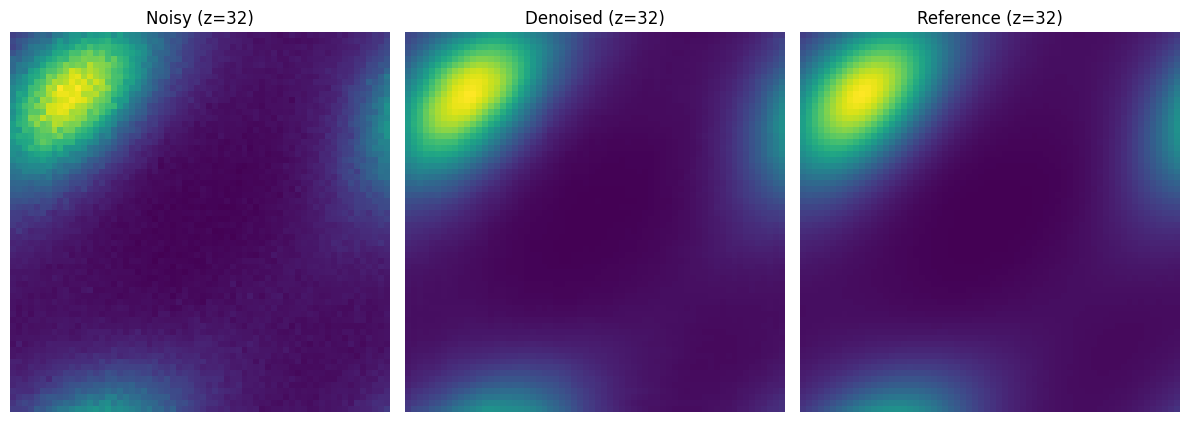

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000482
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


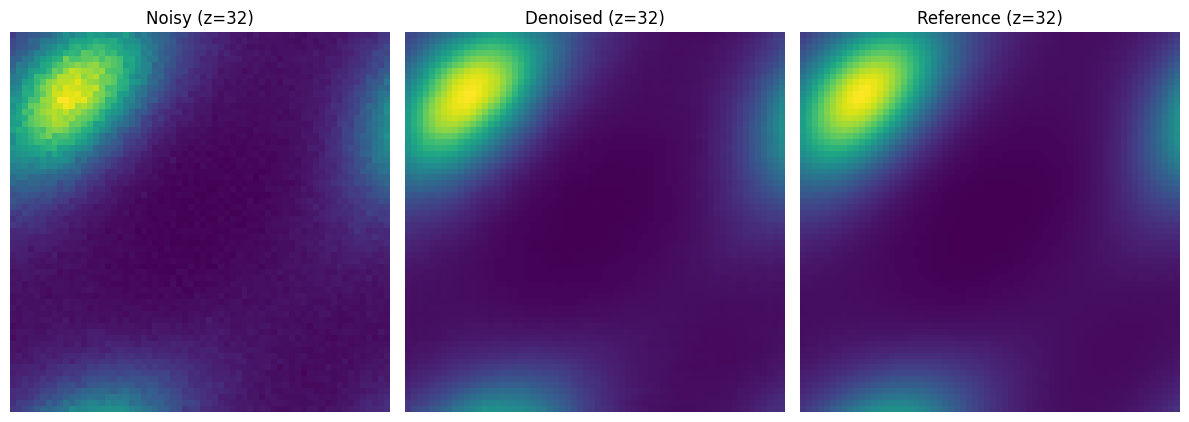

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000367
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


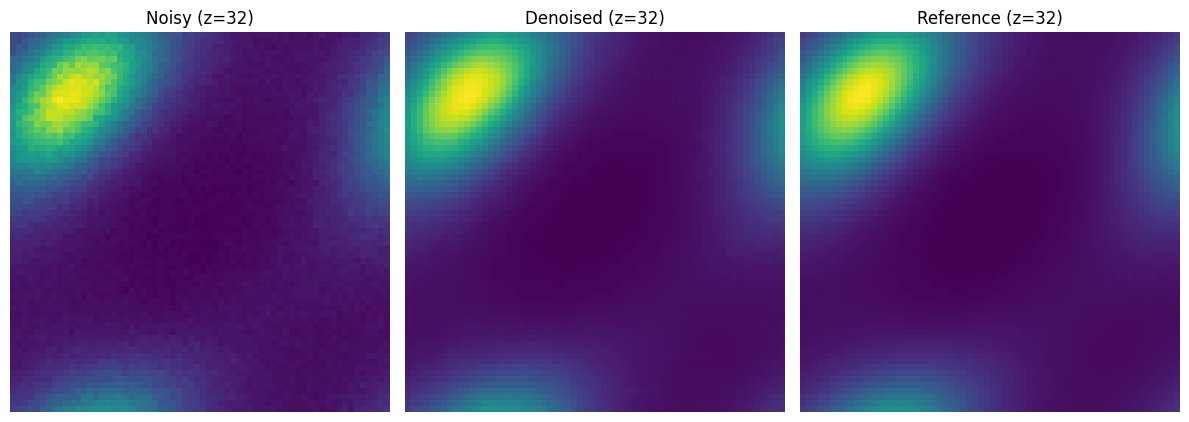

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000245
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


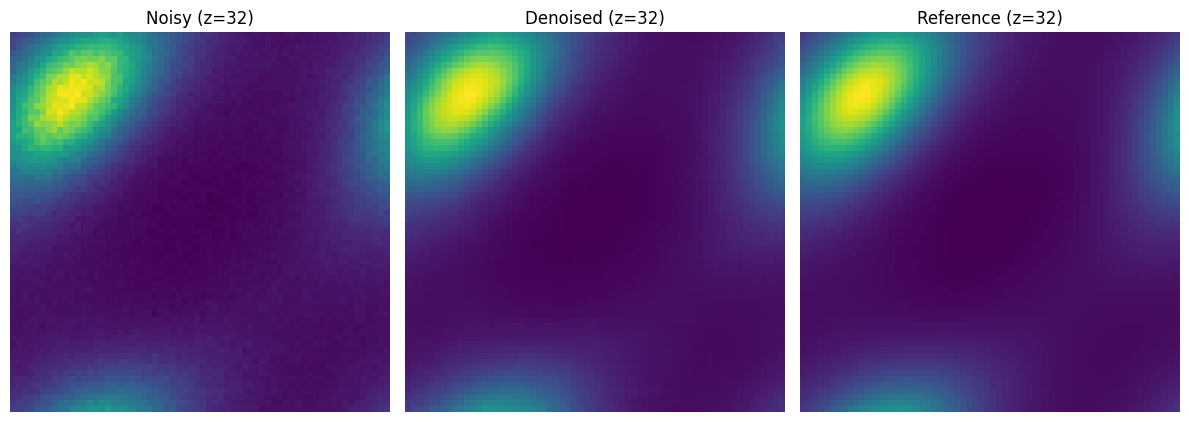

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000184
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


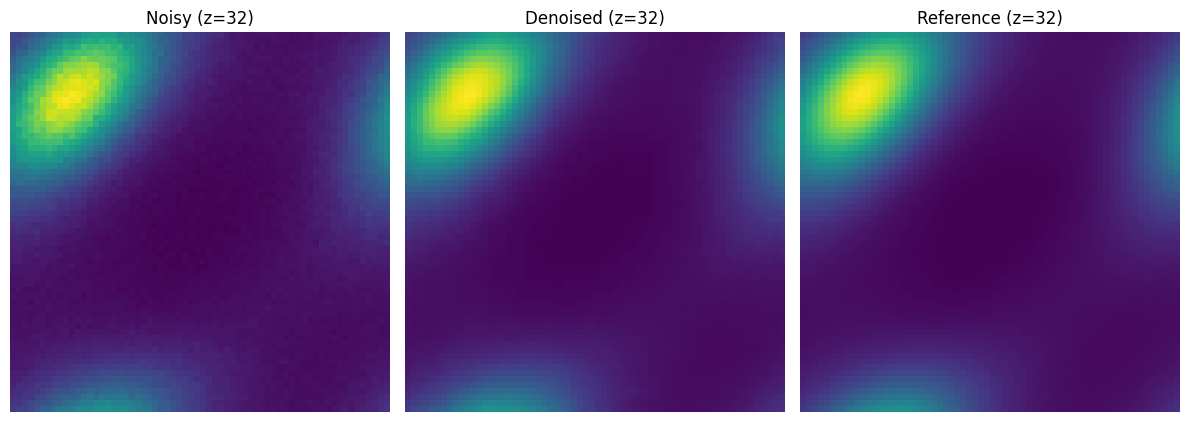

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000123
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


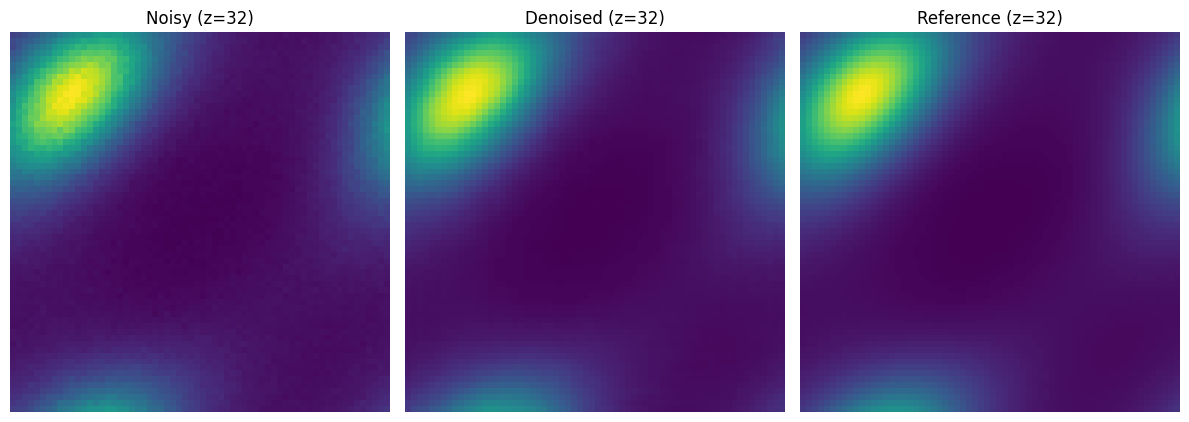

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000092
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


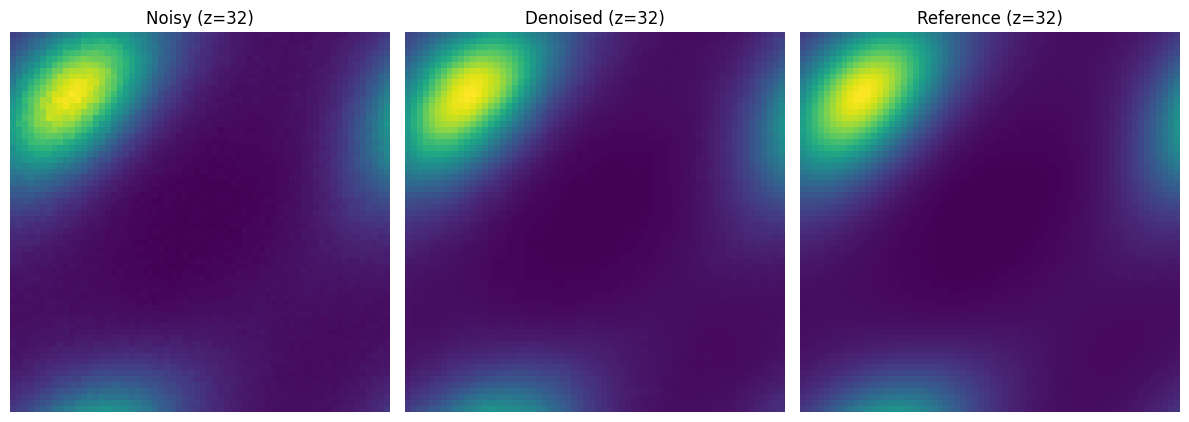

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000062
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


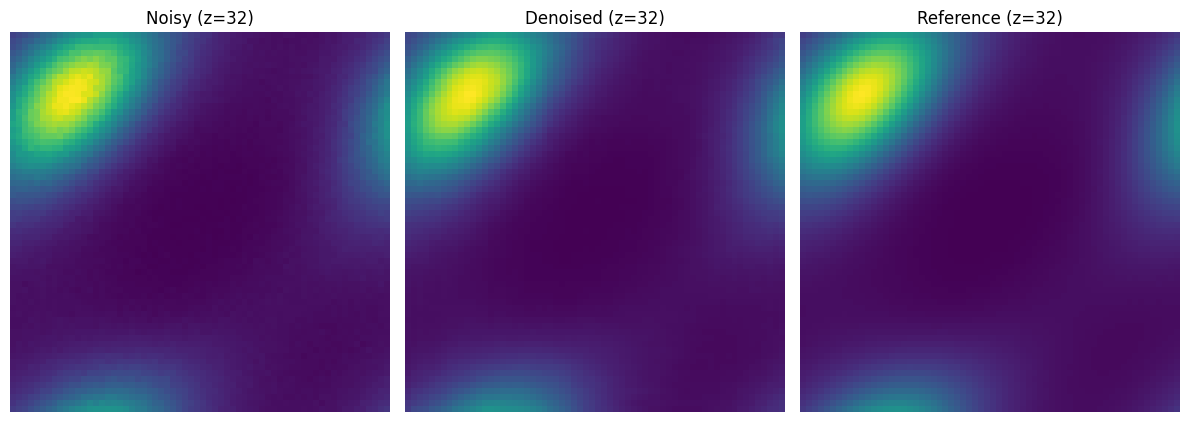

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000046
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


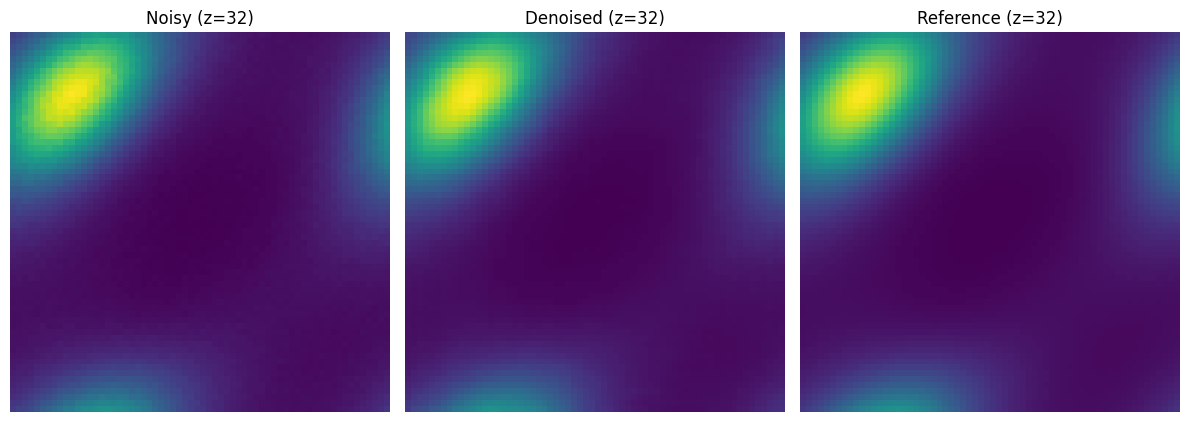

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000031
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


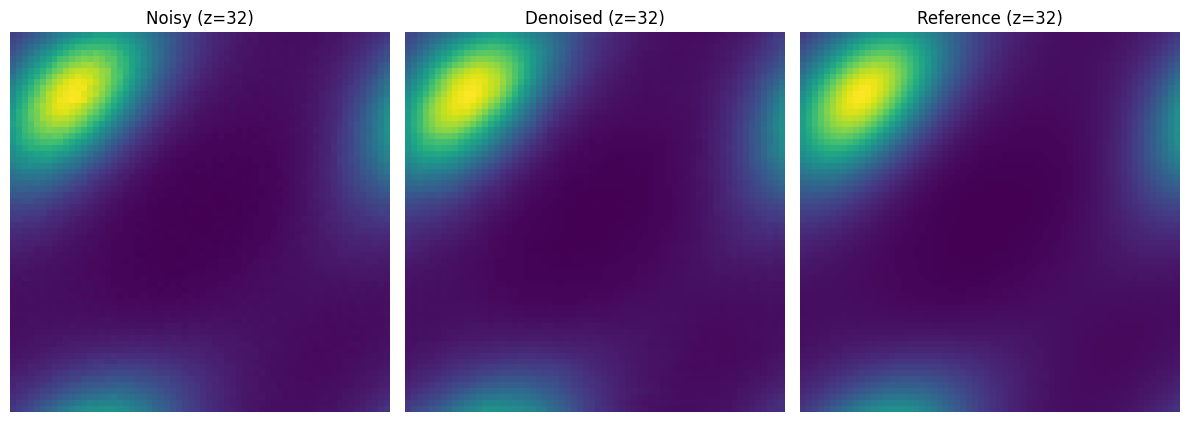

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000024
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


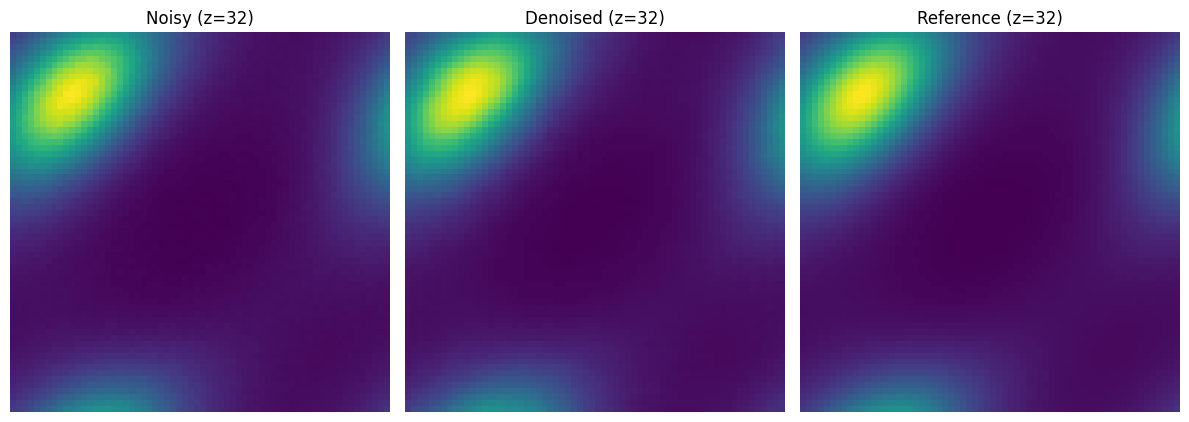

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000075
(64, 64, 64) (64, 64, 64) (64, 64, 64)


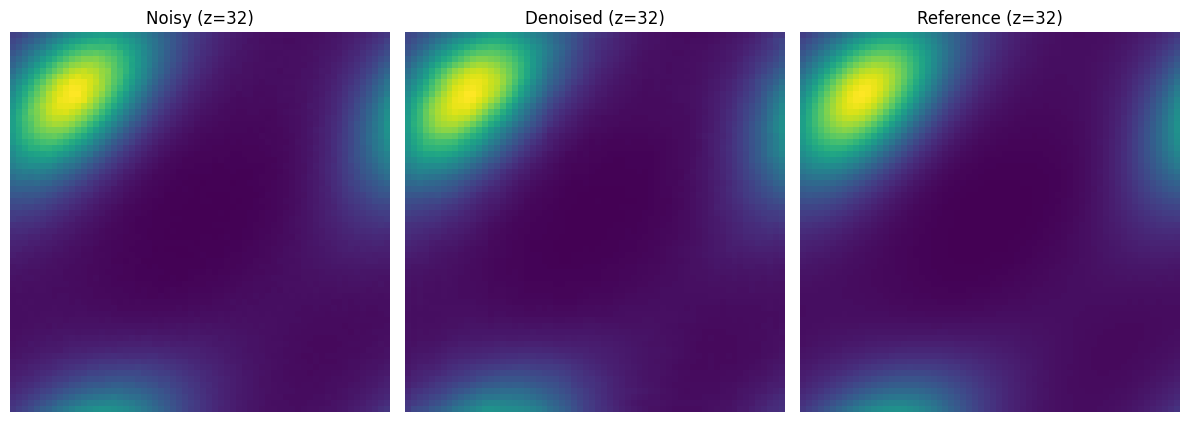

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000012
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


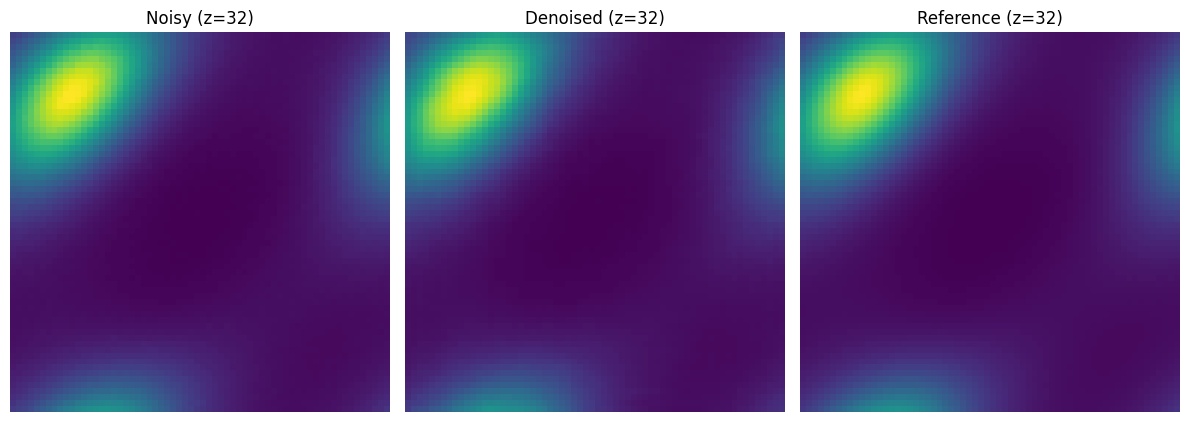

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


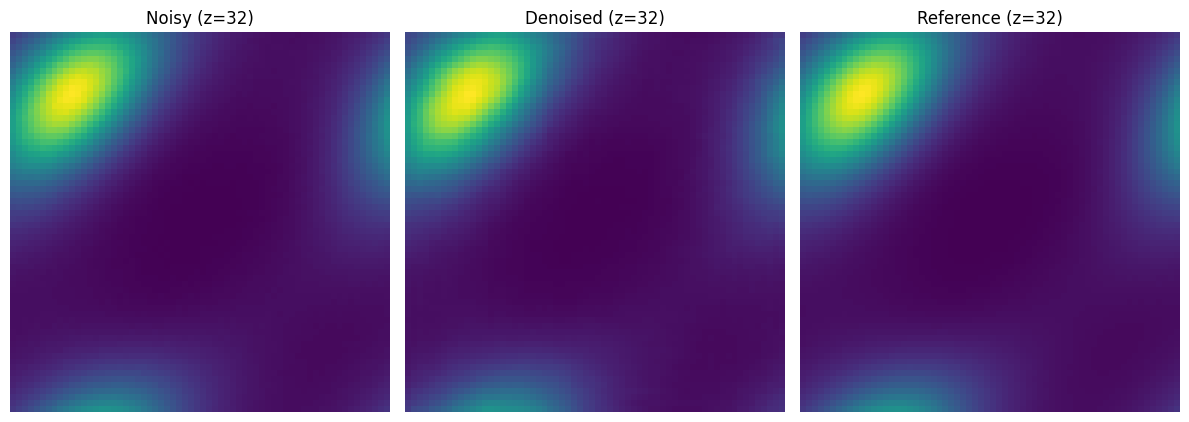

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000075
(64, 64, 64) (64, 64, 64) (64, 64, 64)


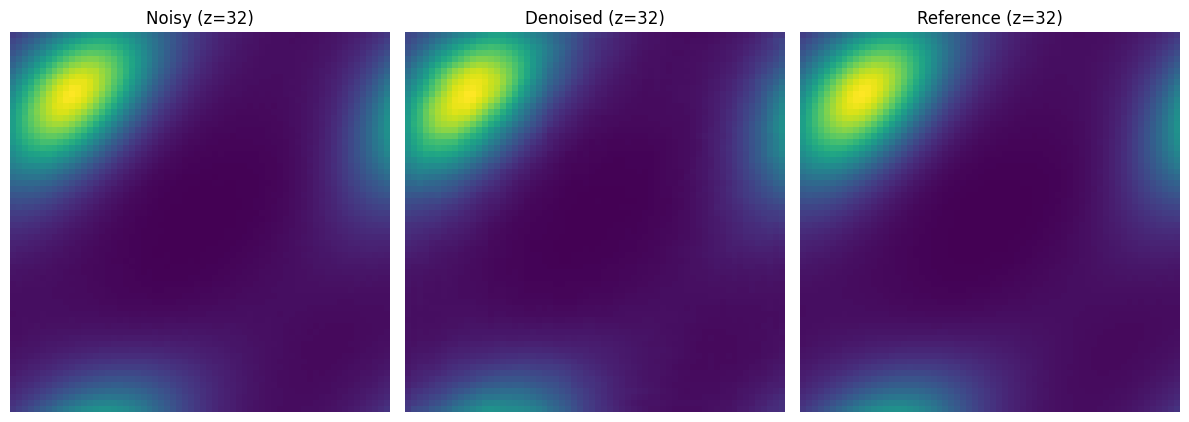

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


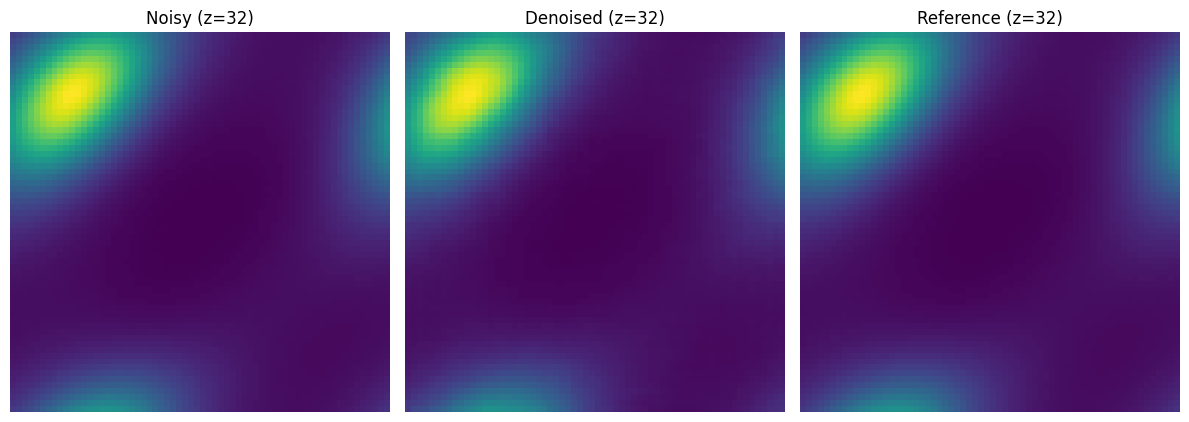

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000074
(64, 64, 64) (64, 64, 64) (64, 64, 64)


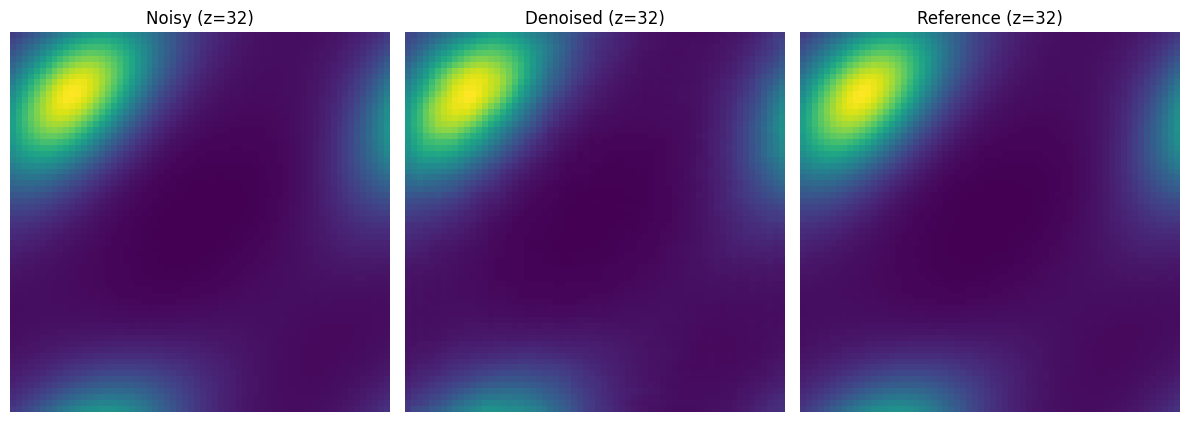


=== Running model: 23930000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.326098
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


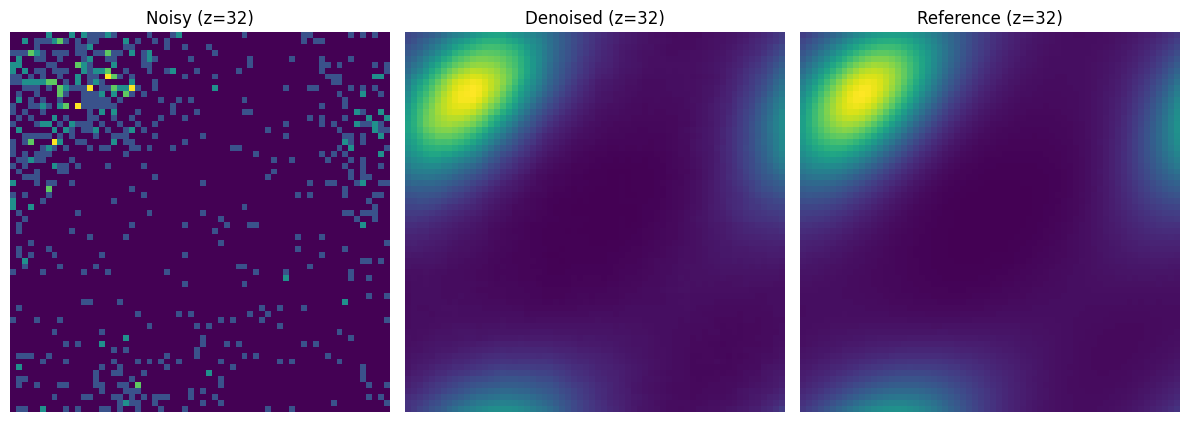

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.219943
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


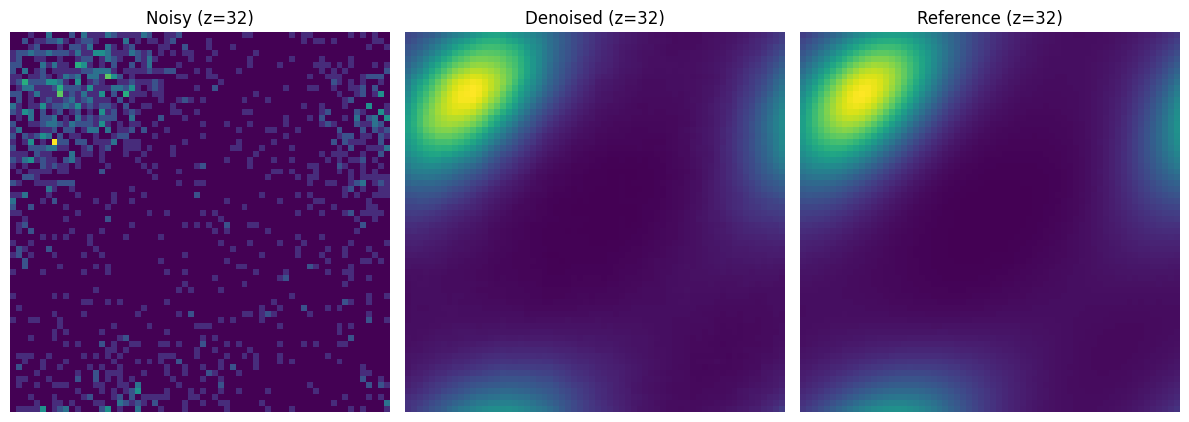

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.132102
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


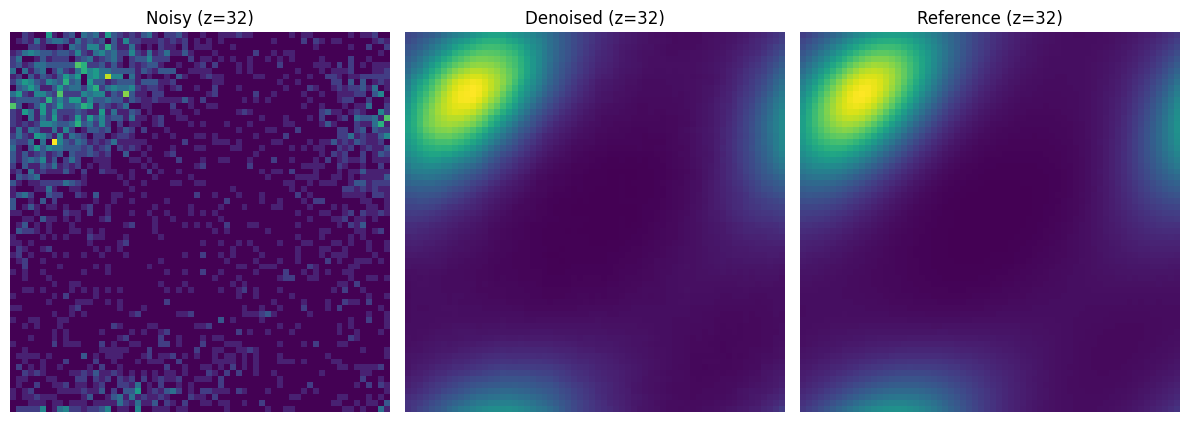

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.072527
JSD   (denoised vs ref):  0.000108
(64, 64, 64) (64, 64, 64) (64, 64, 64)


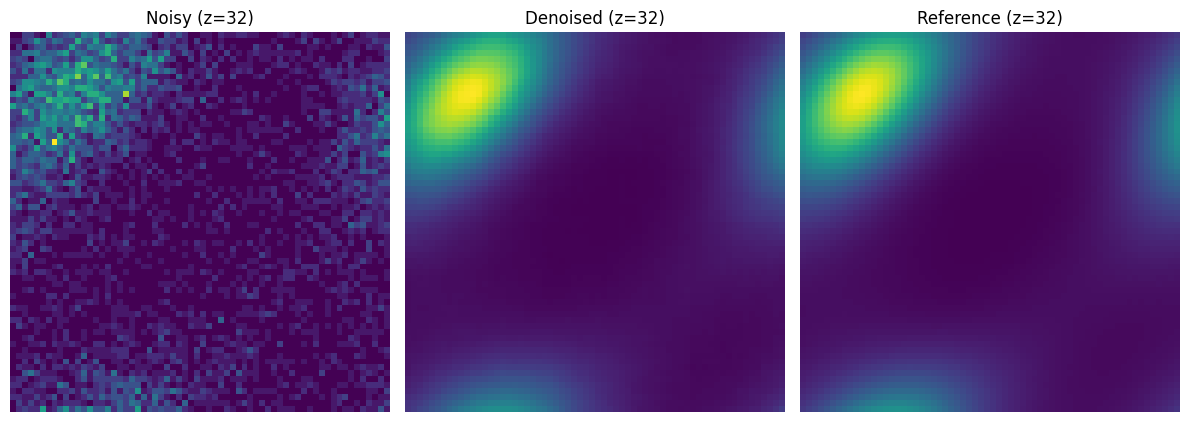

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.036875
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


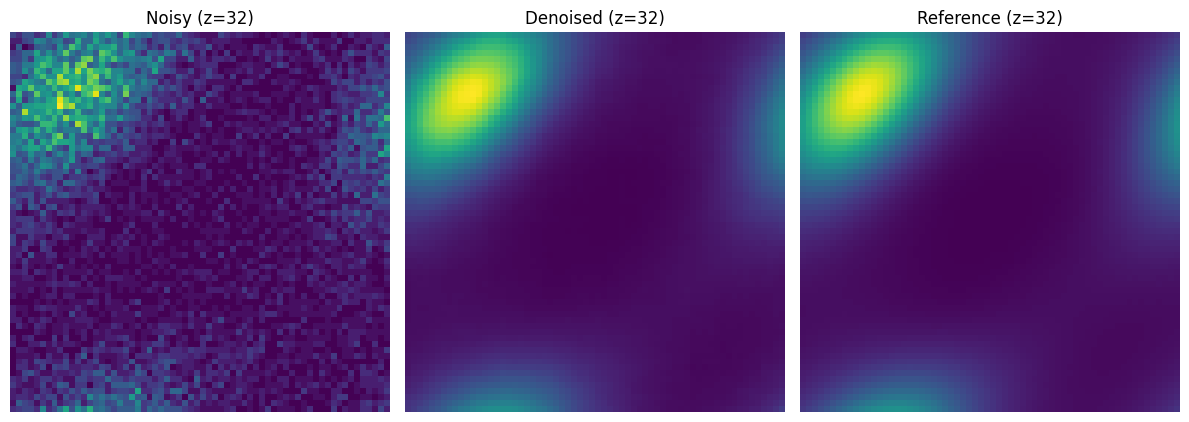

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.017617
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


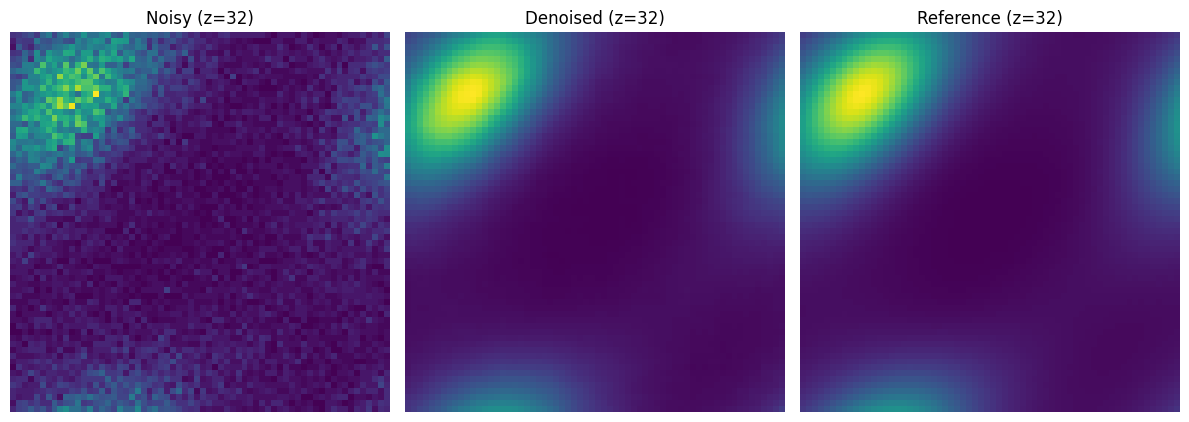

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.013049
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


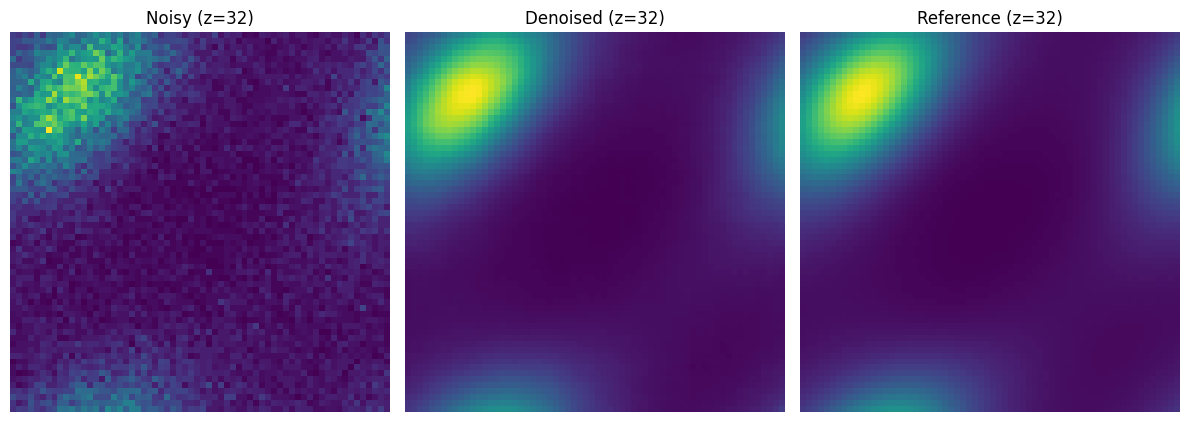

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.008181
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


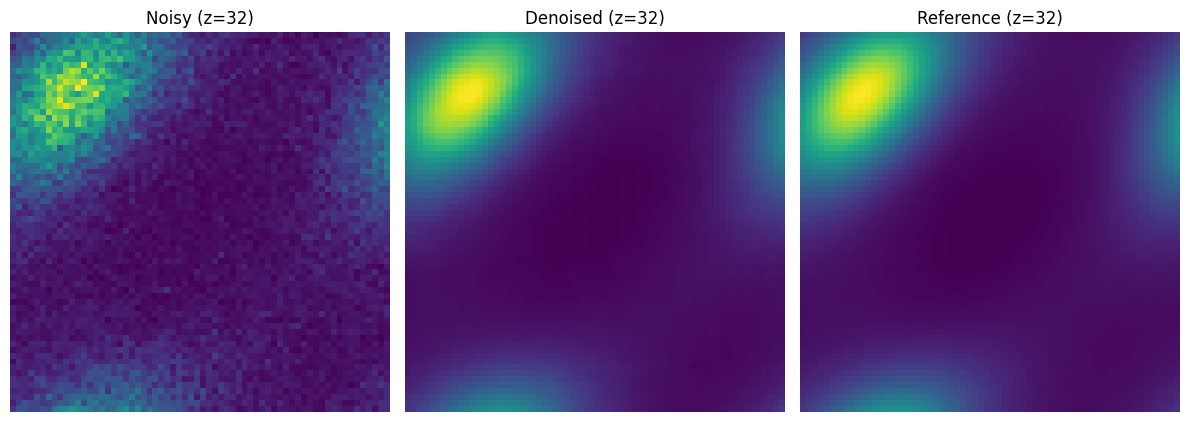

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.006157
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


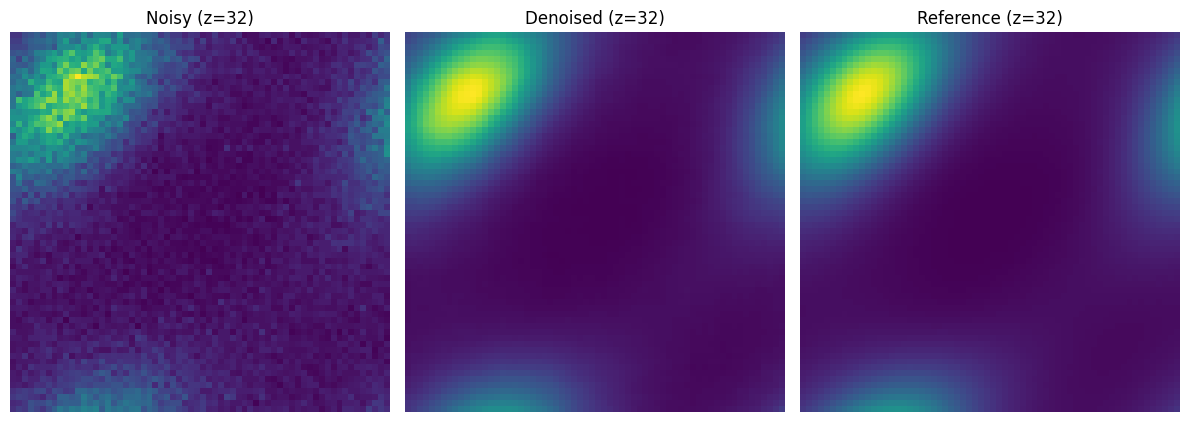

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.003937
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


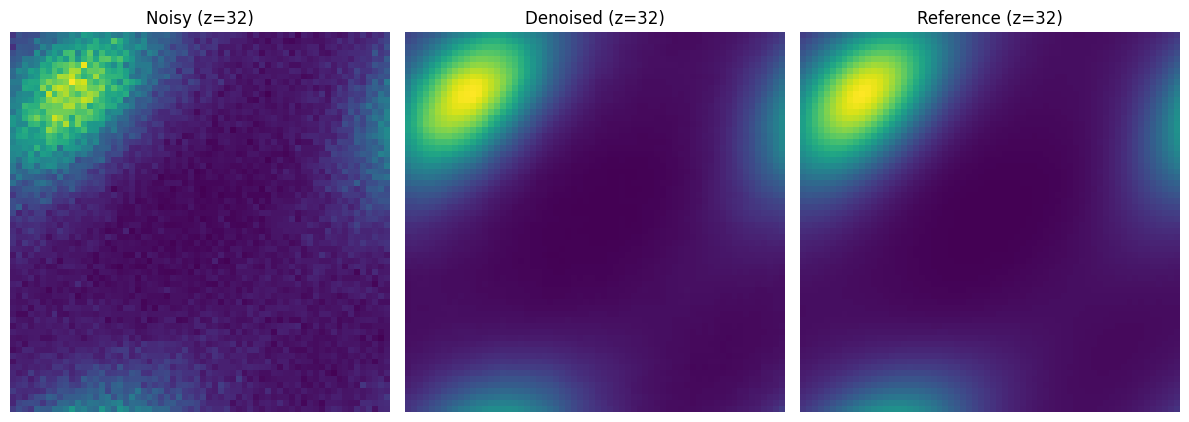

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.002993
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


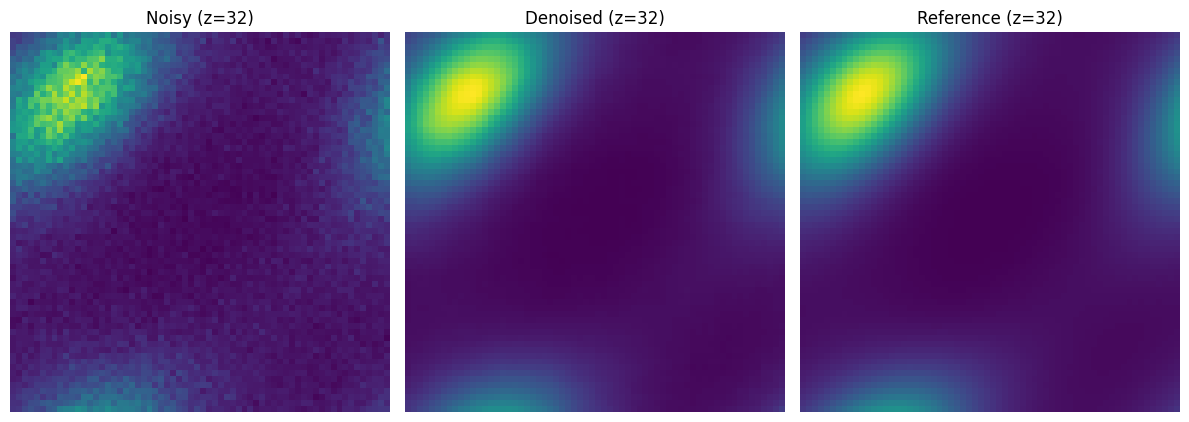

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001939
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


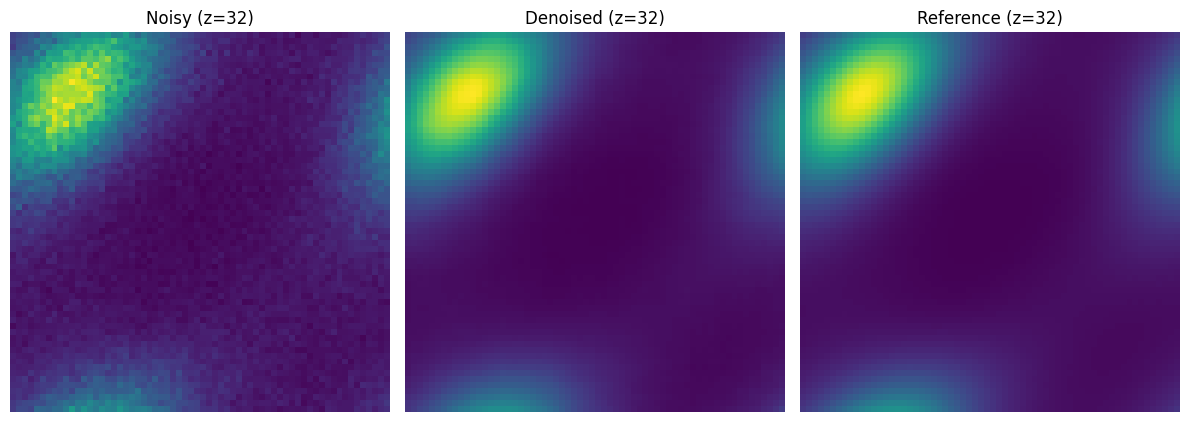

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001476
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


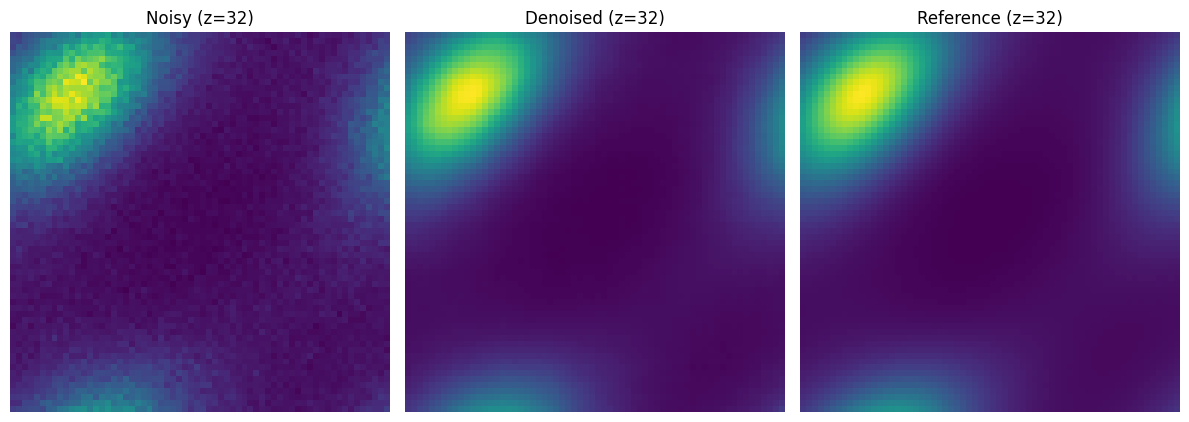

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000984
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


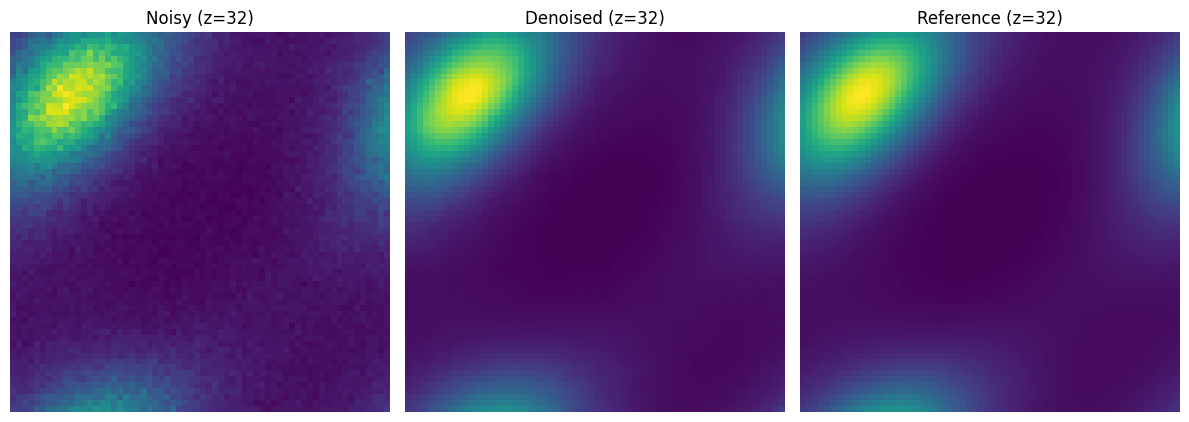

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000966
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


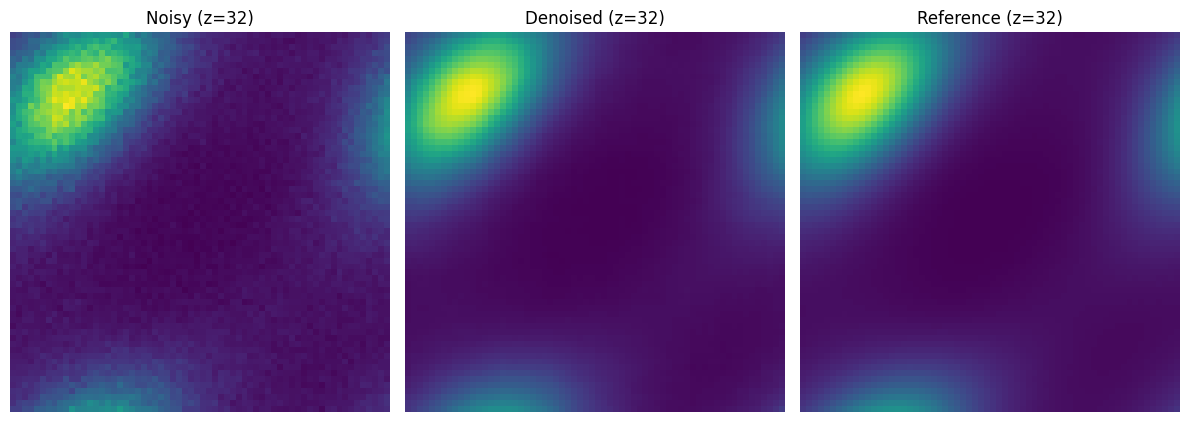

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000735
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


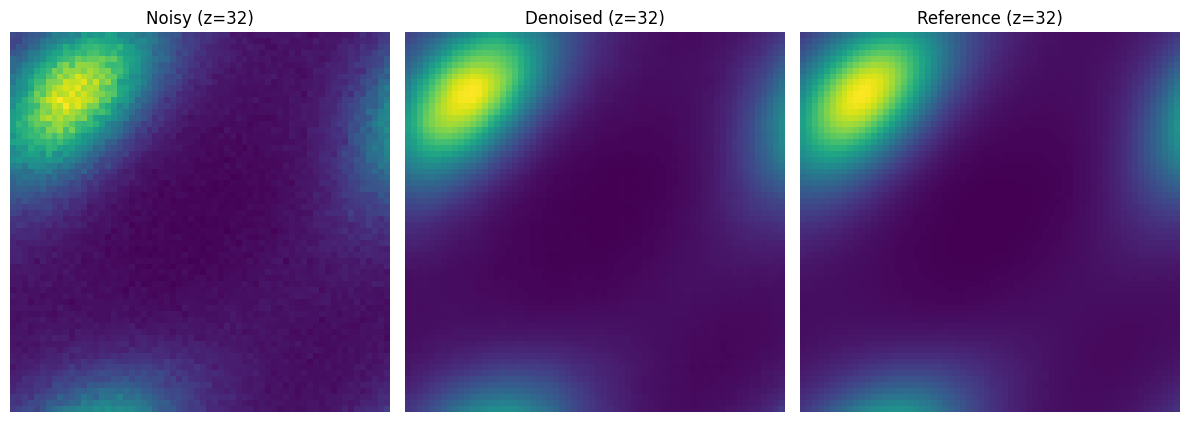

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000491
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


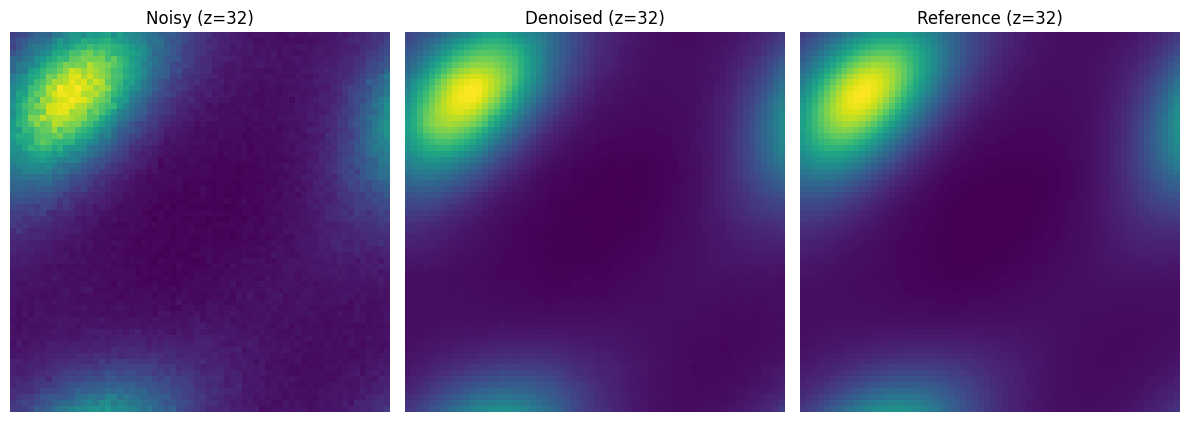

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000482
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


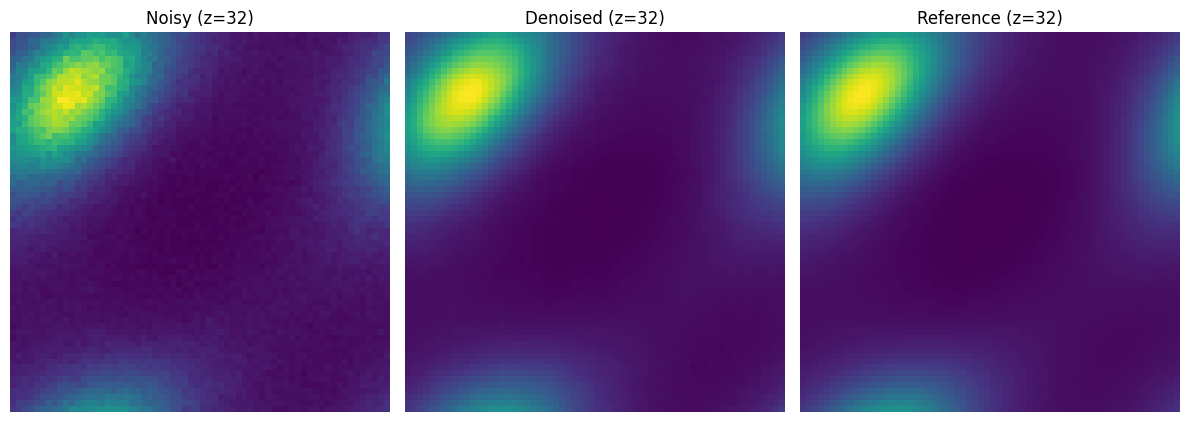

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000367
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


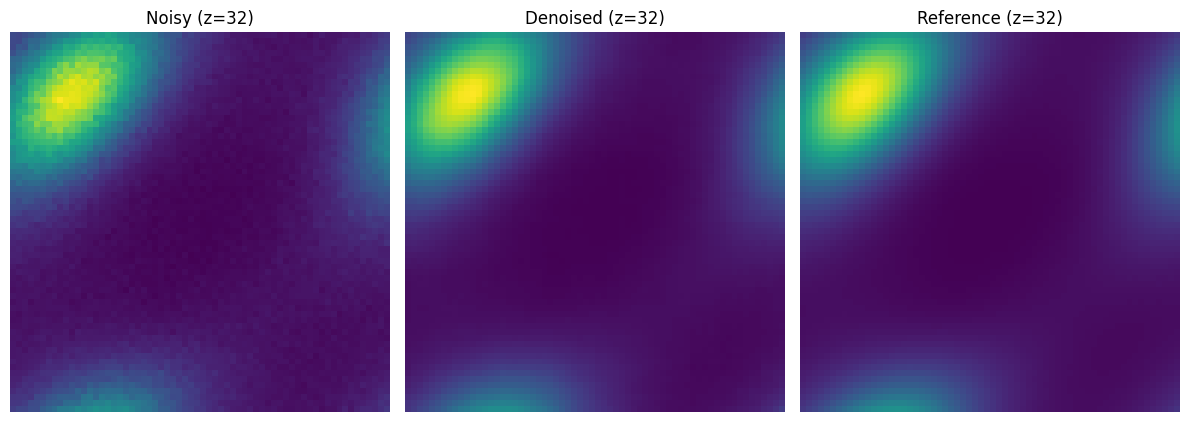

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000245
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


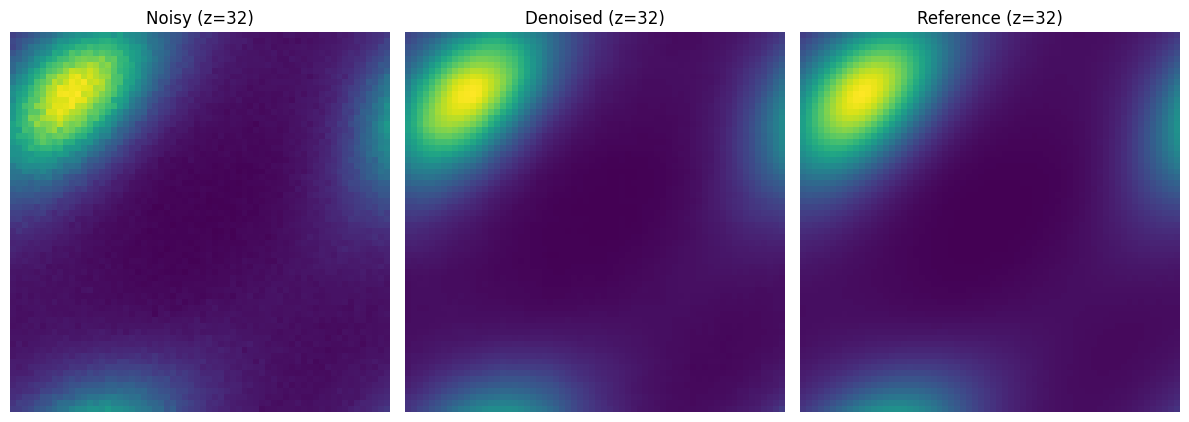

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000184
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


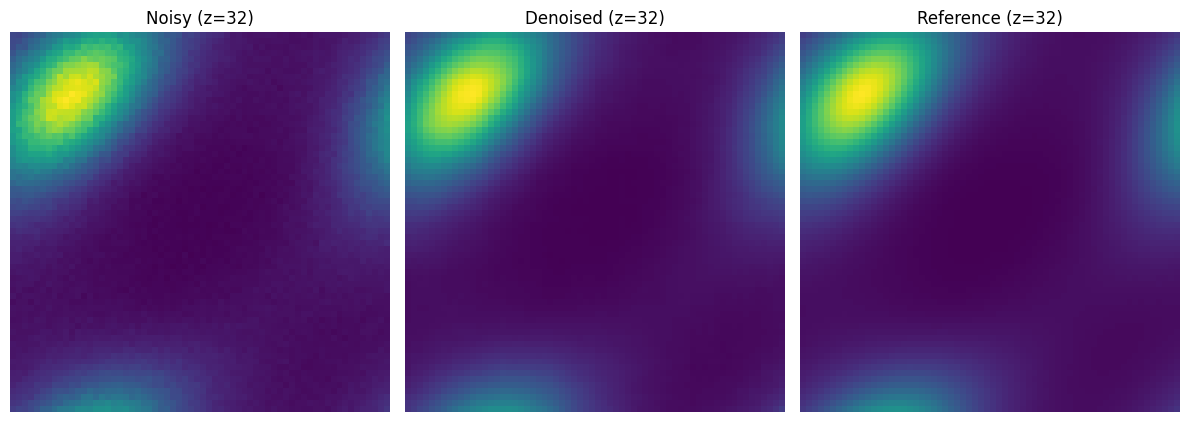

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000123
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


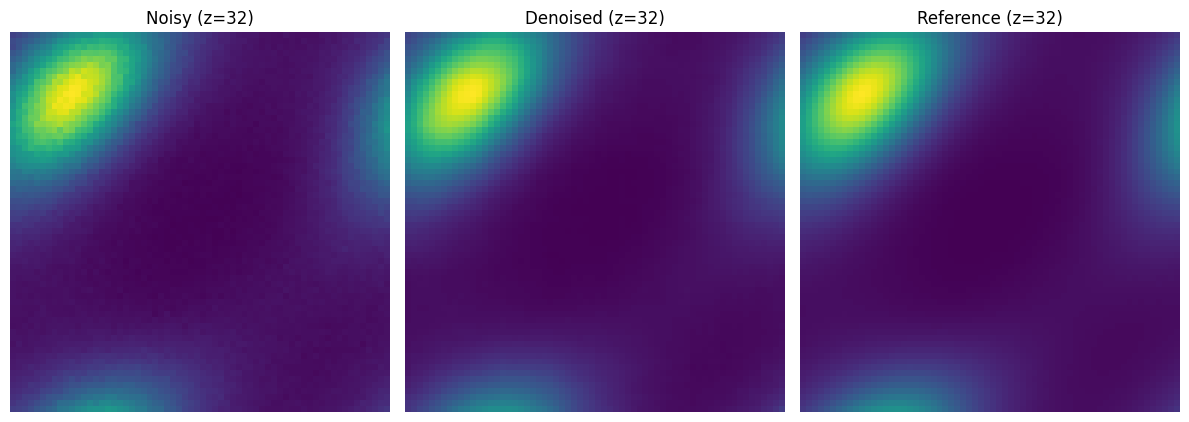

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000092
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


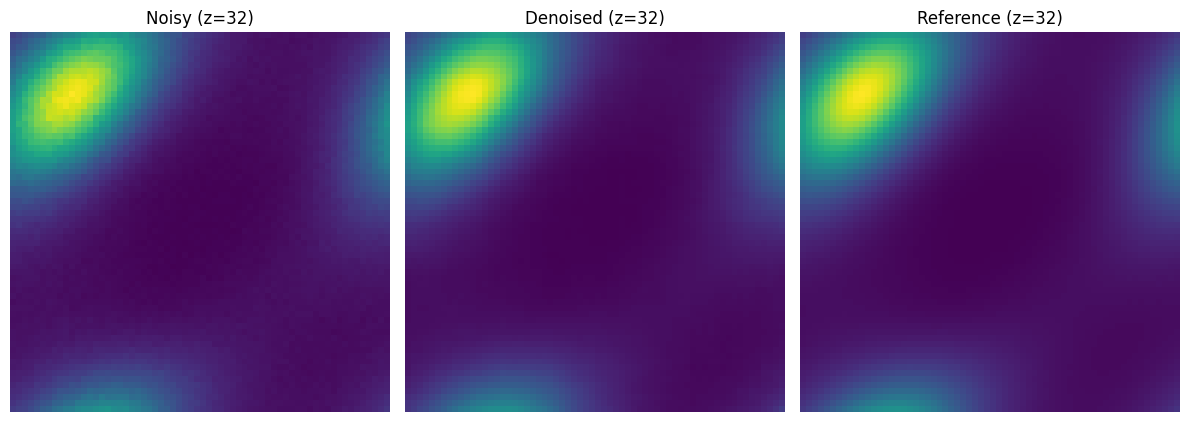

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000062
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


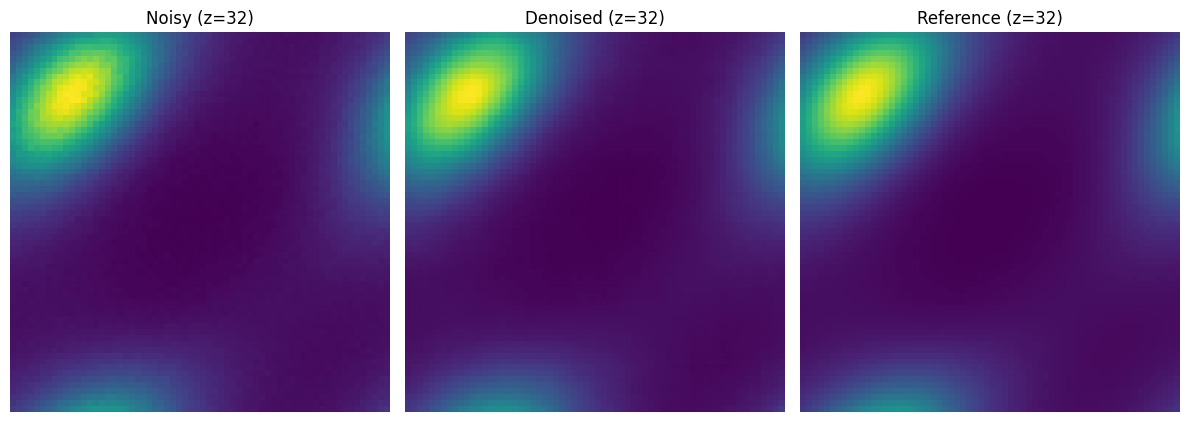

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000046
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


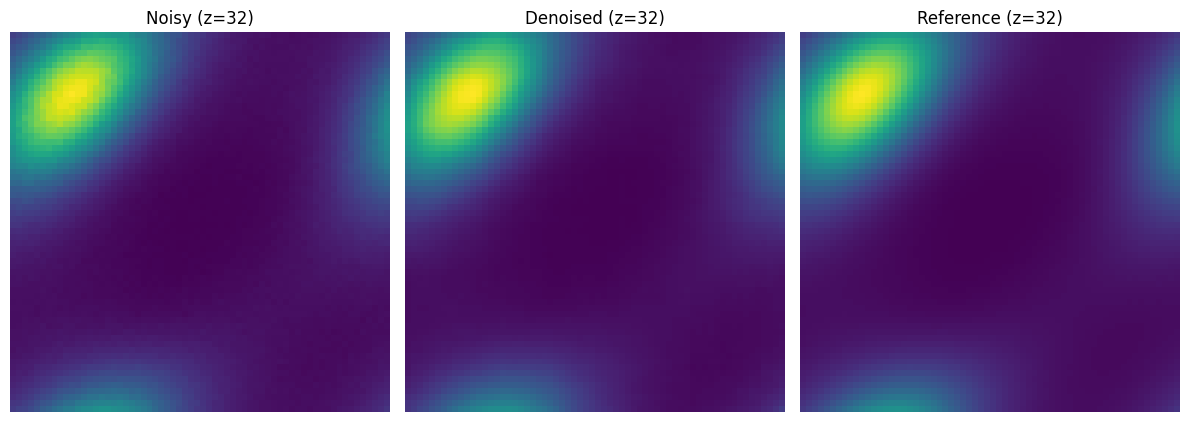

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000031
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


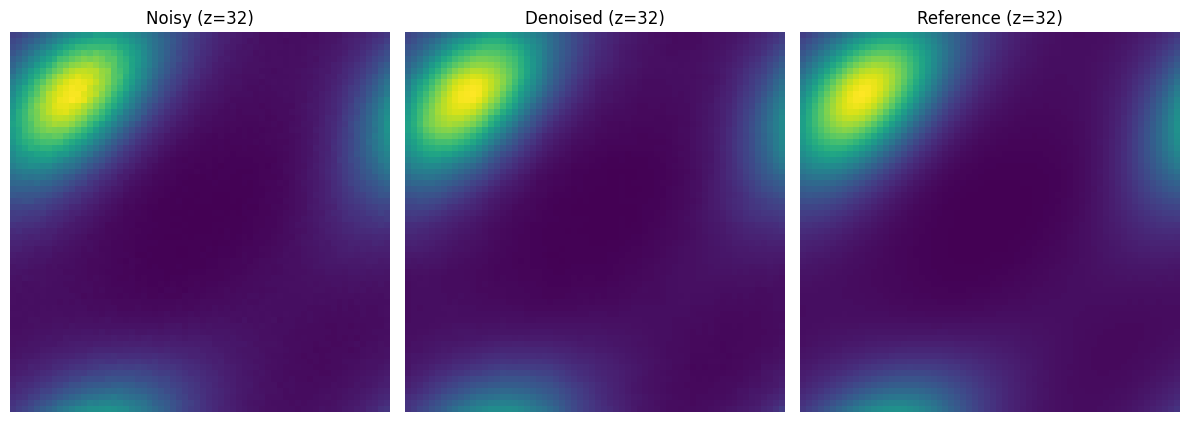

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000024
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


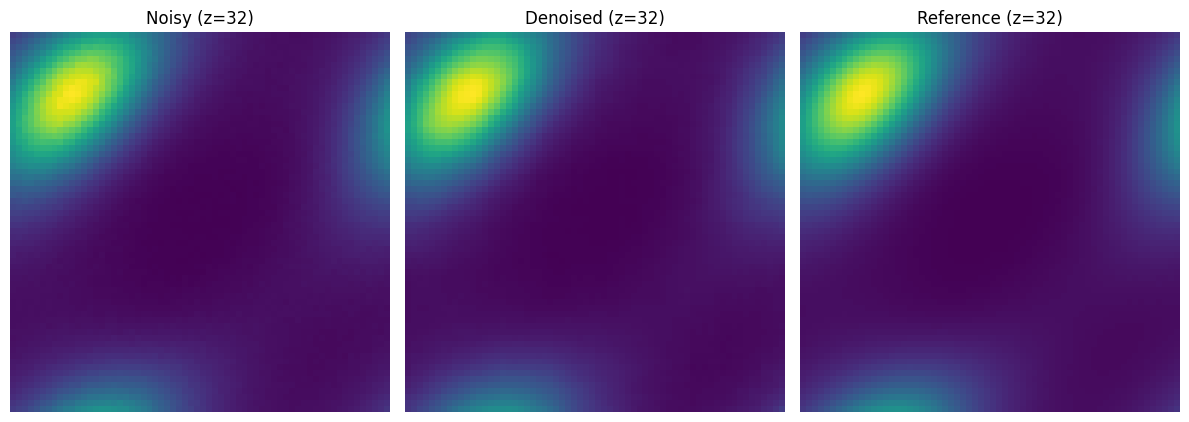

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


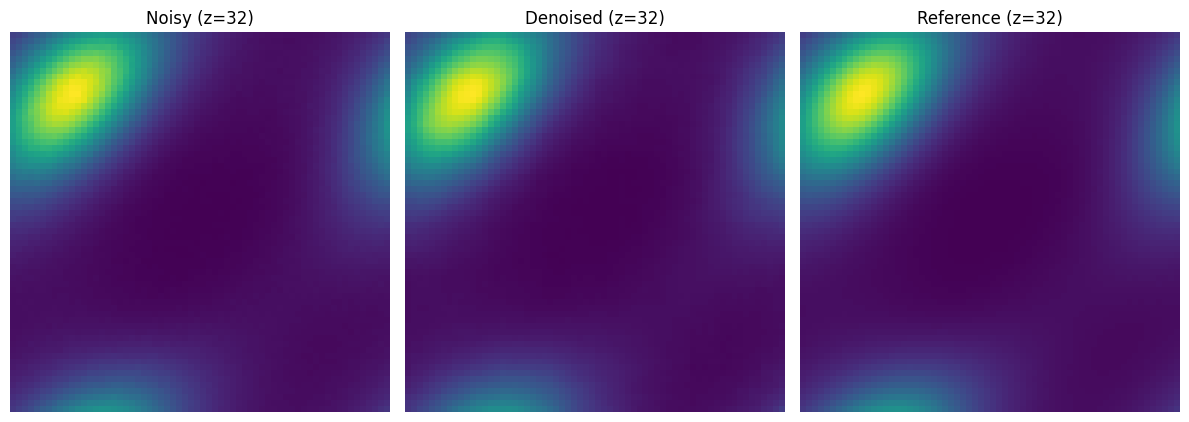

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000012
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


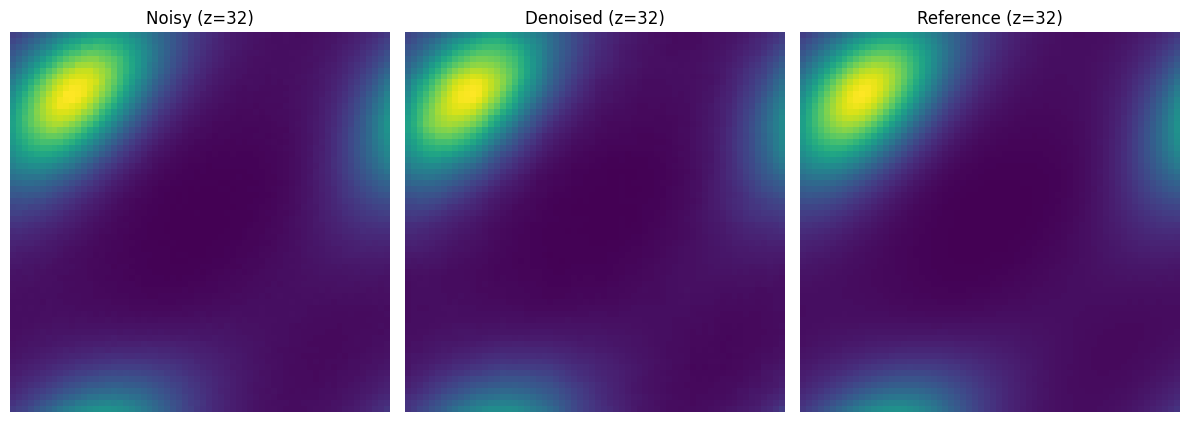

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


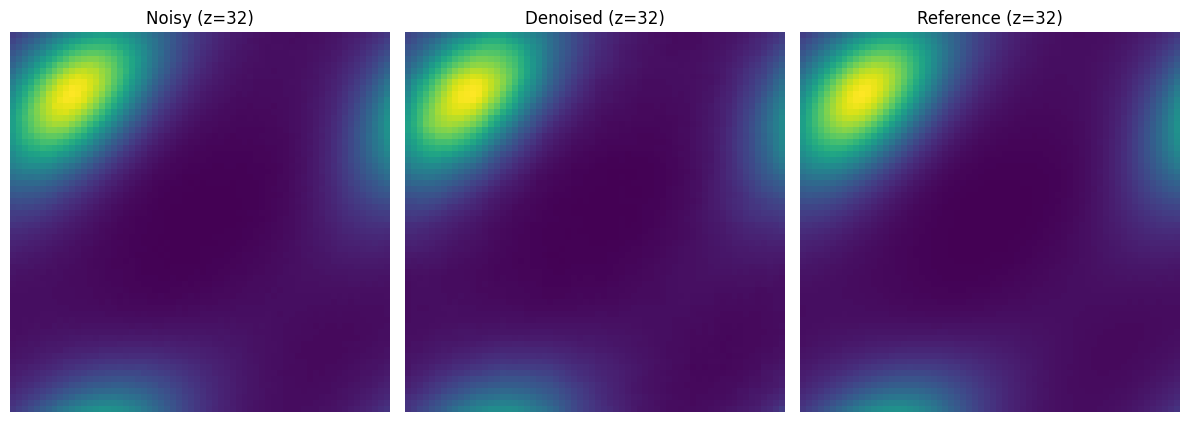

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


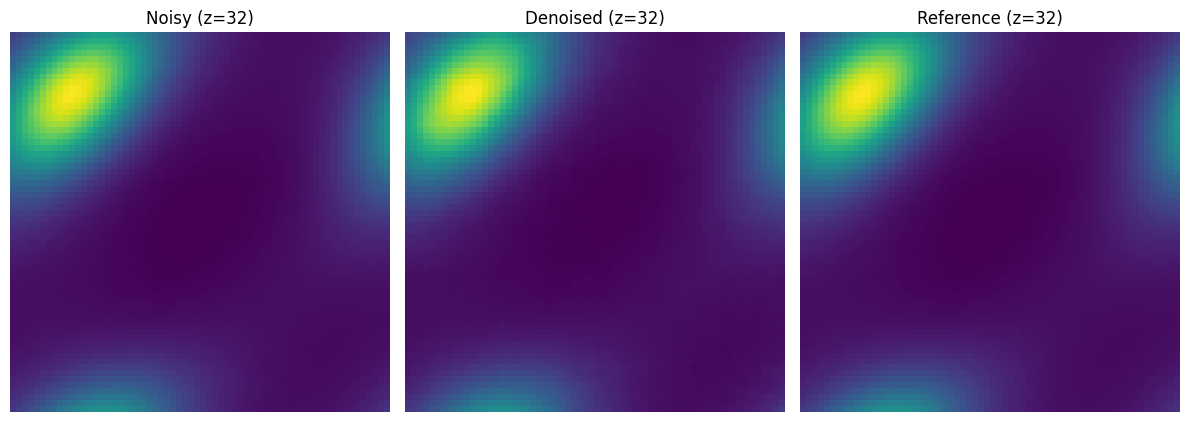

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


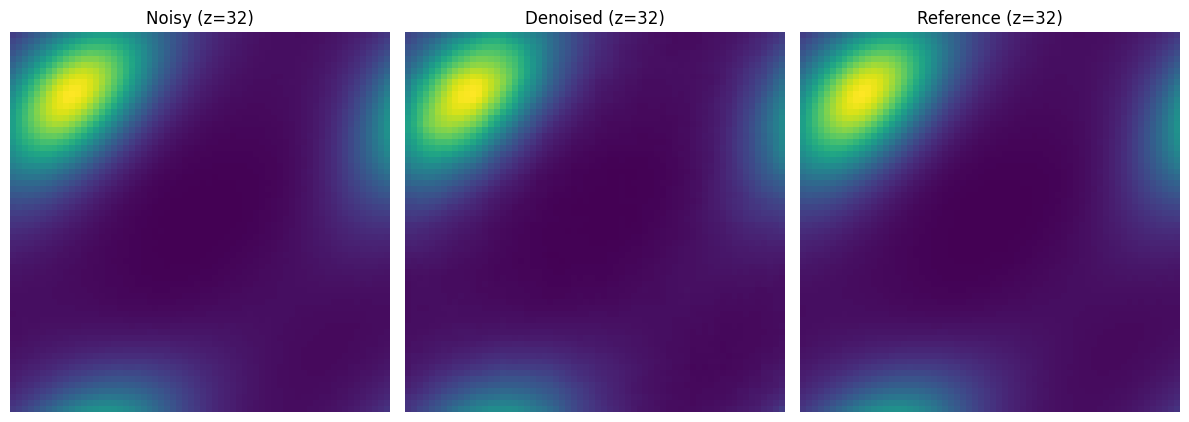

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


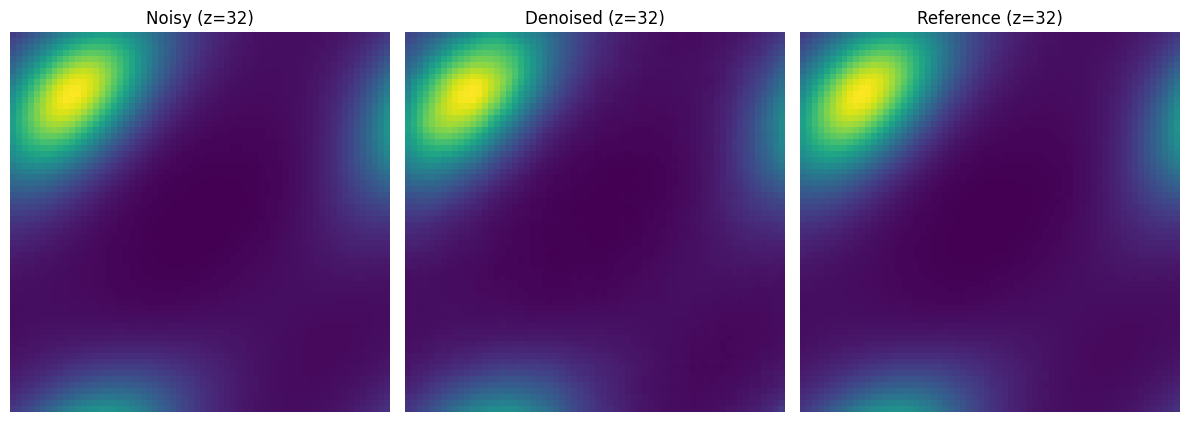


=== Running model: 240700000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 752ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.326098
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


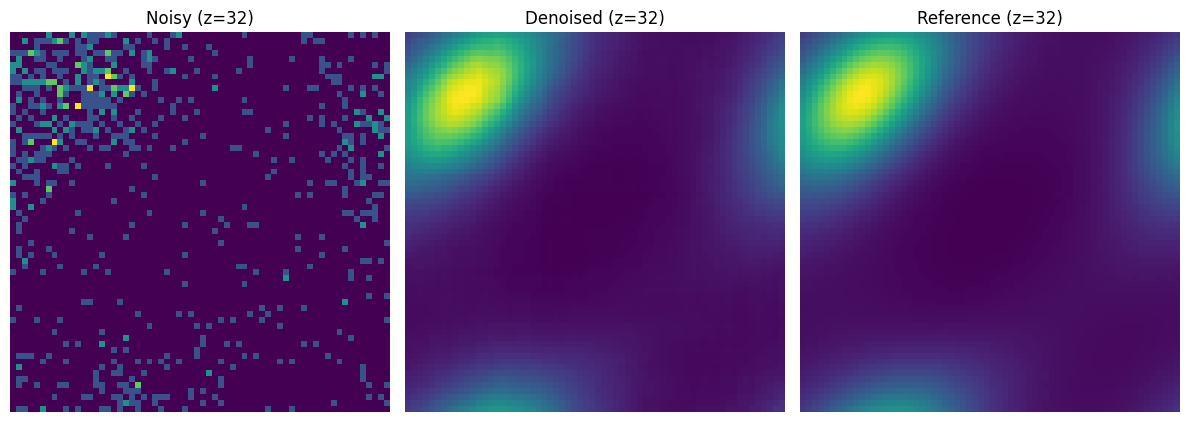

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.219943
JSD   (denoised vs ref):  0.000105
(64, 64, 64) (64, 64, 64) (64, 64, 64)


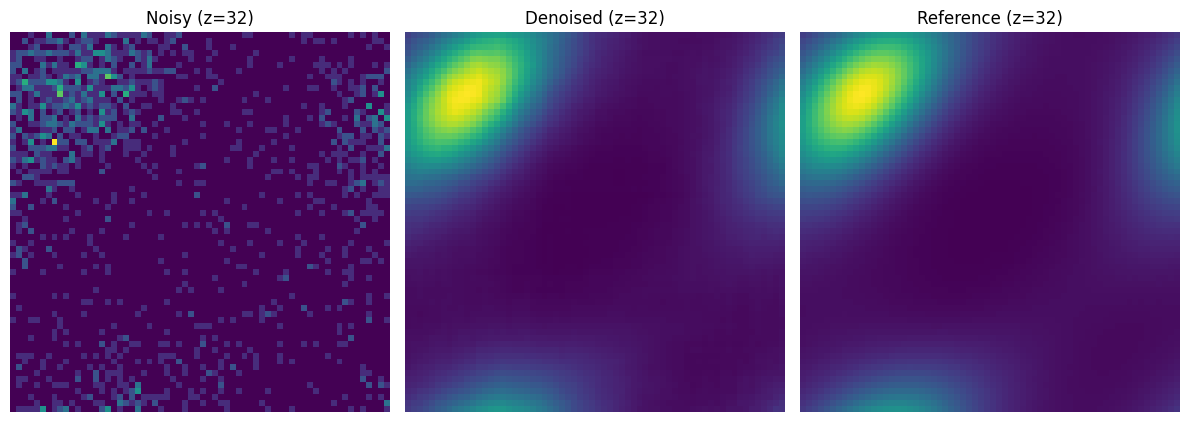

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.132102
JSD   (denoised vs ref):  0.000103
(64, 64, 64) (64, 64, 64) (64, 64, 64)


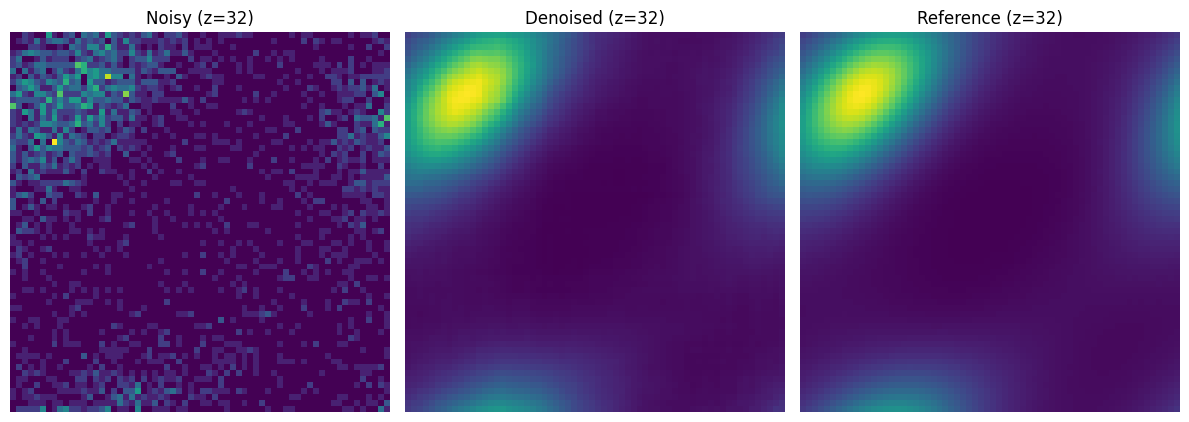

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.072527
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


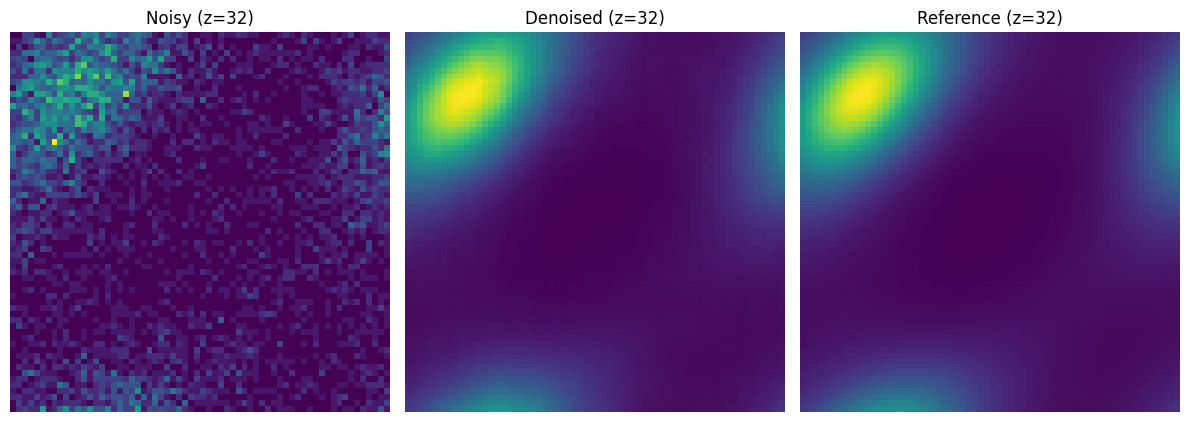

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.036875
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


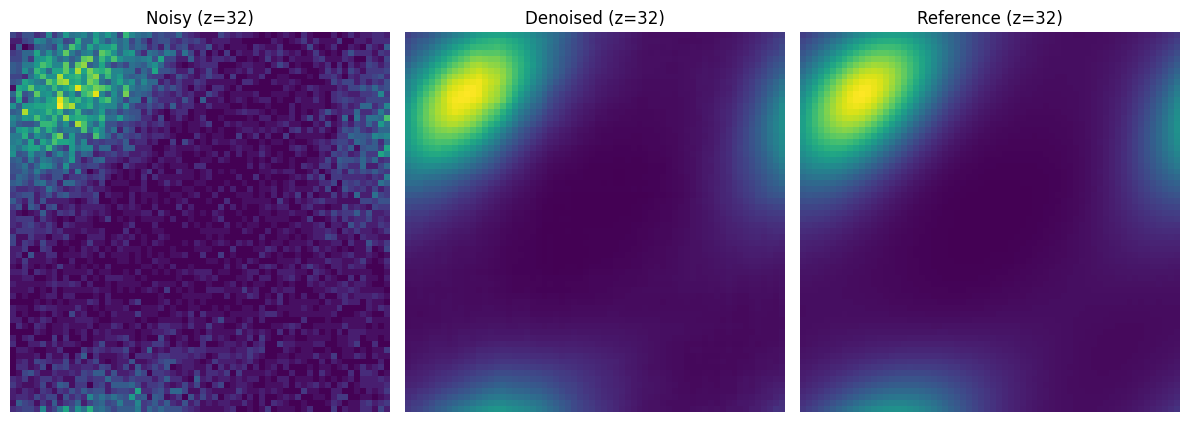

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.017617
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


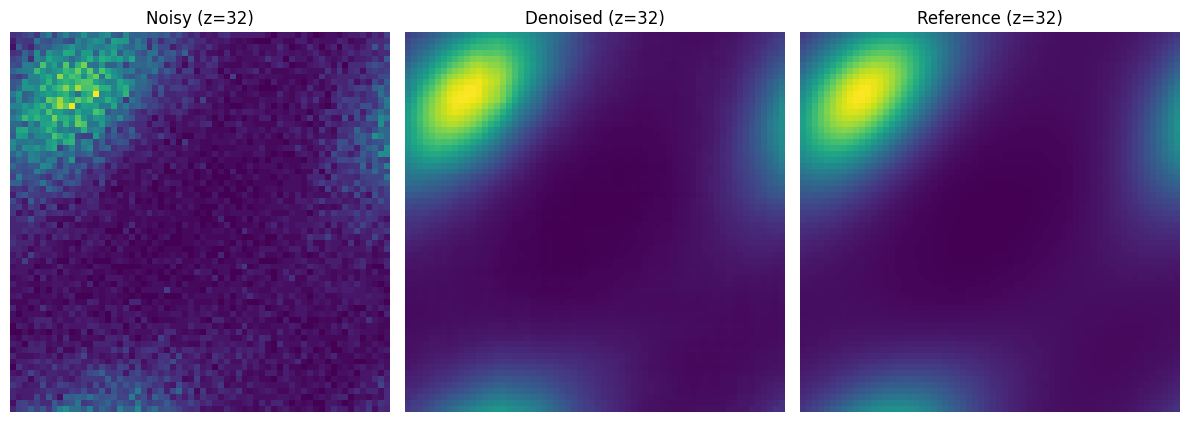

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.013049
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


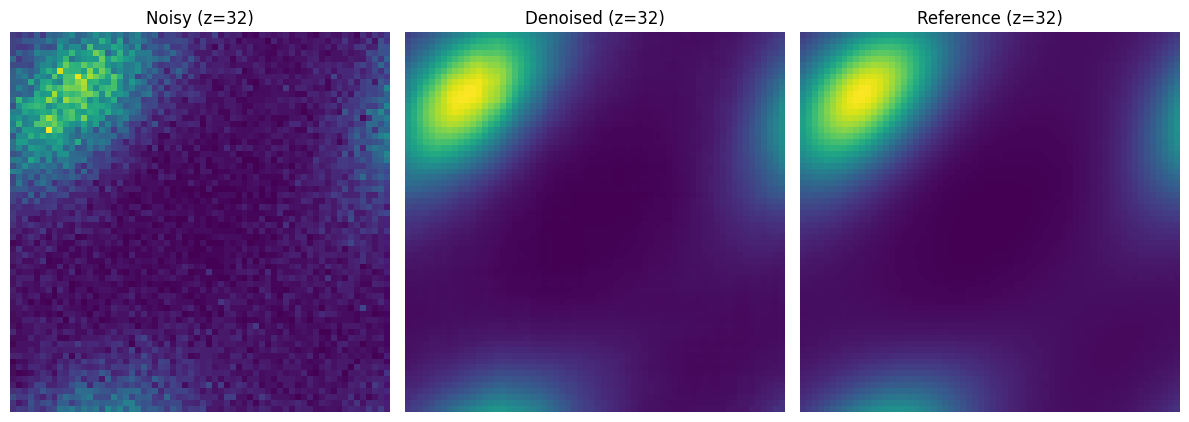

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.008181
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


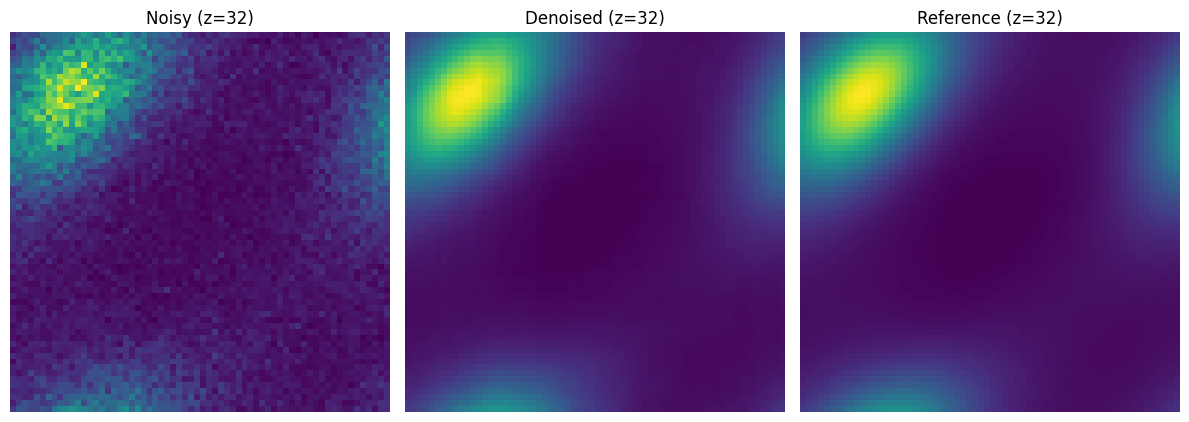

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.006157
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


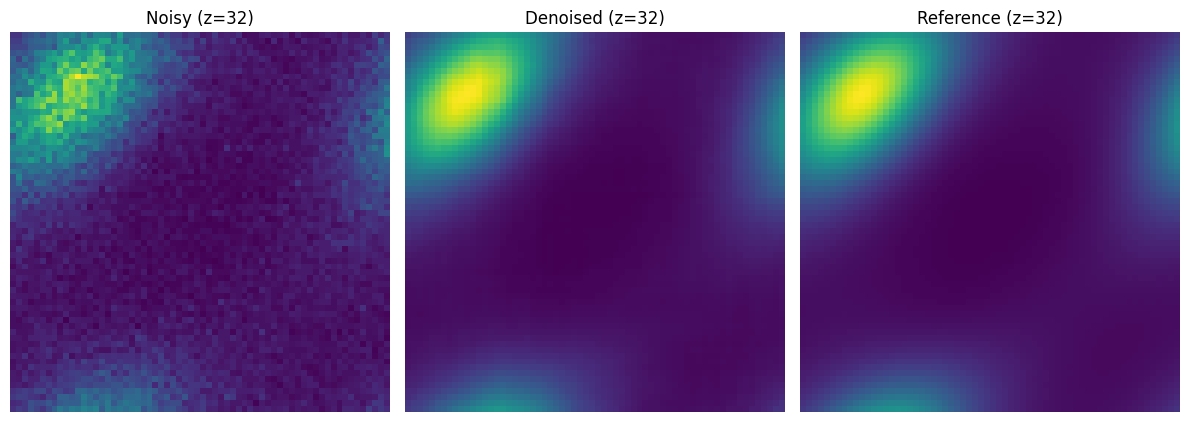

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.003937
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


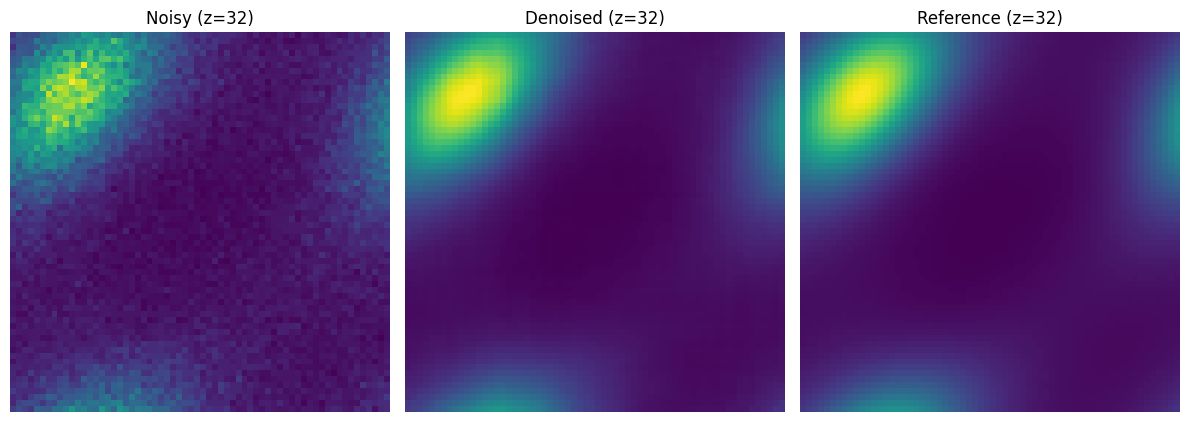

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.002993
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


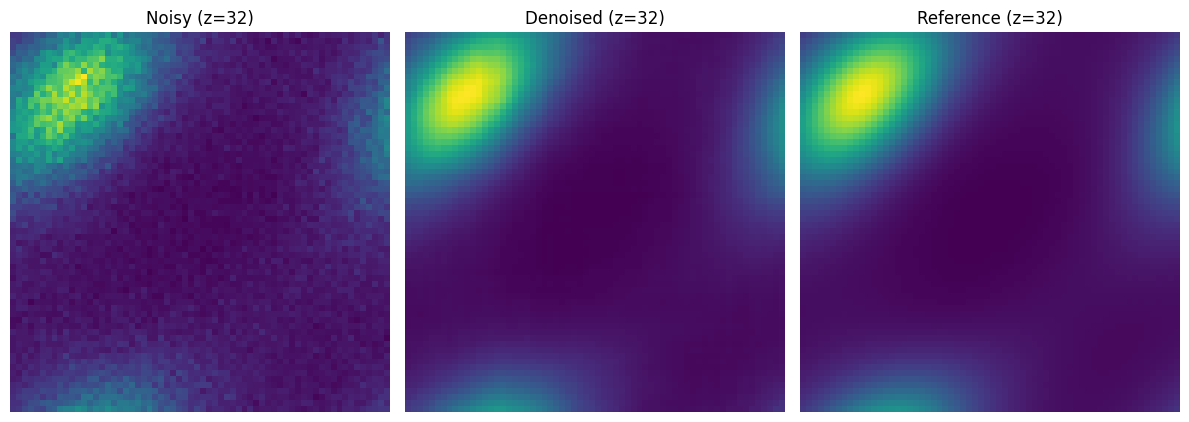

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.001939
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


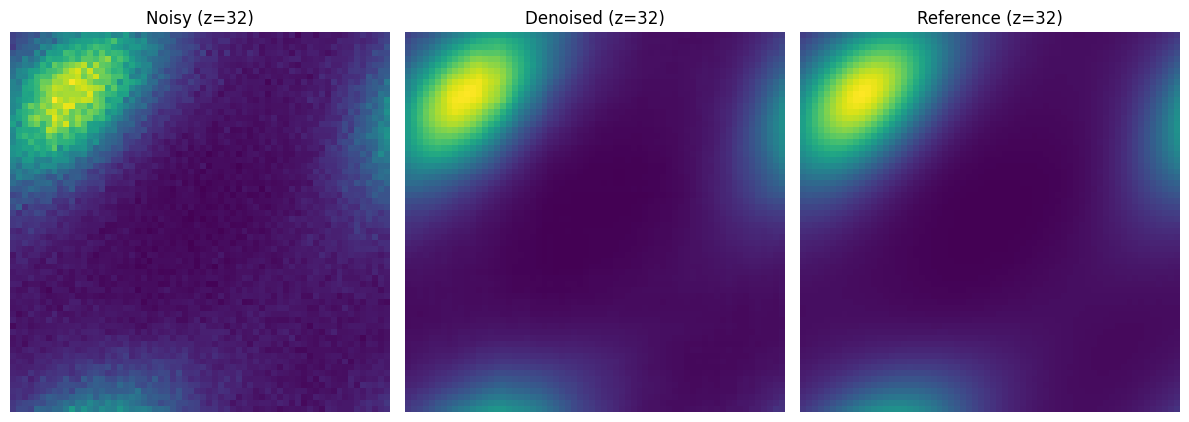

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.001476
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


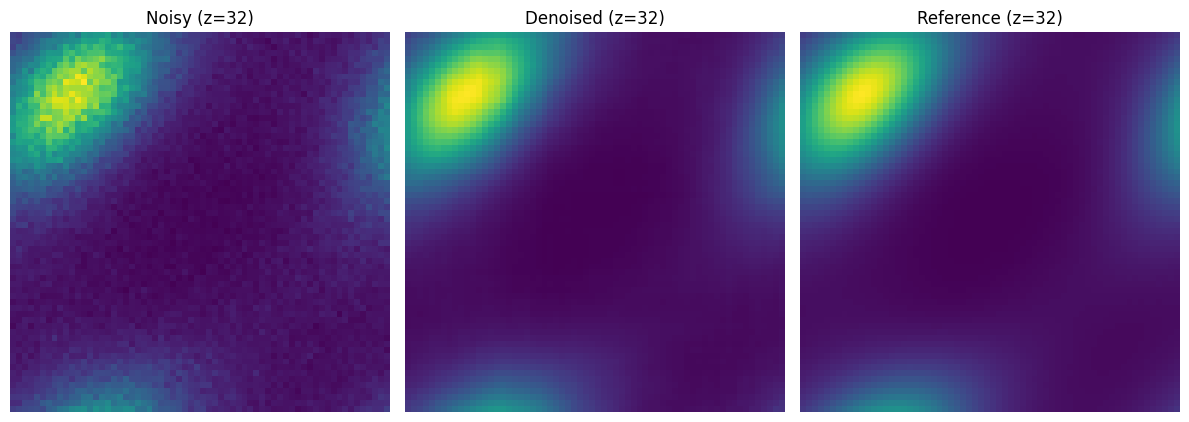

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000984
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


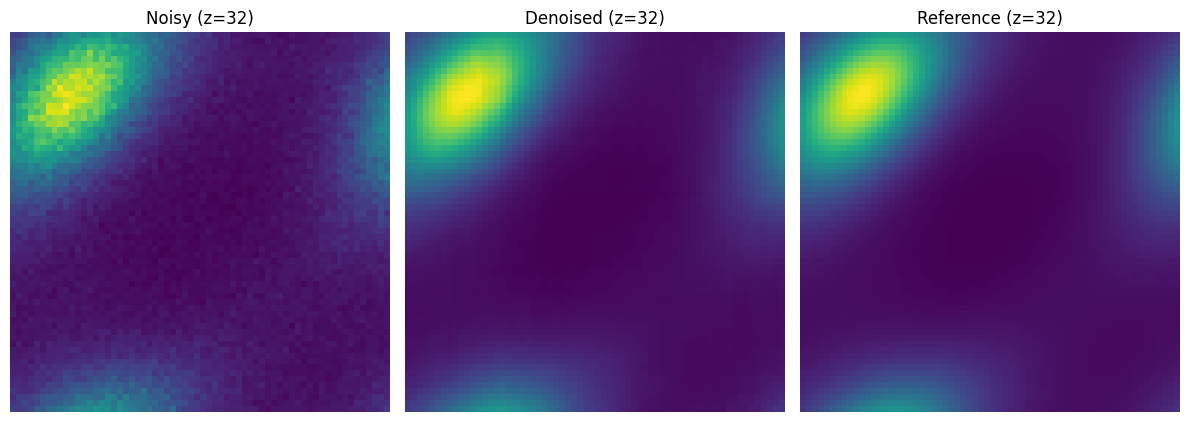

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000966
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


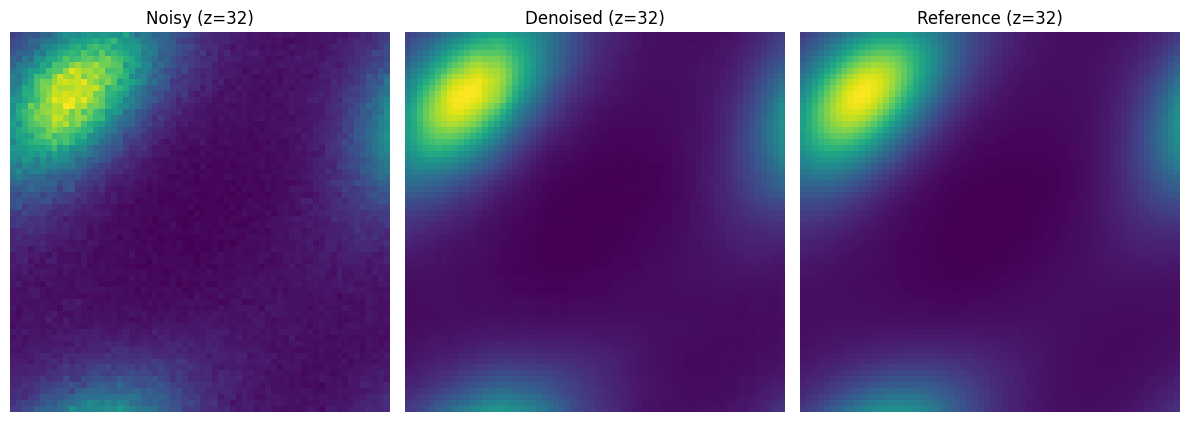

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000735
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


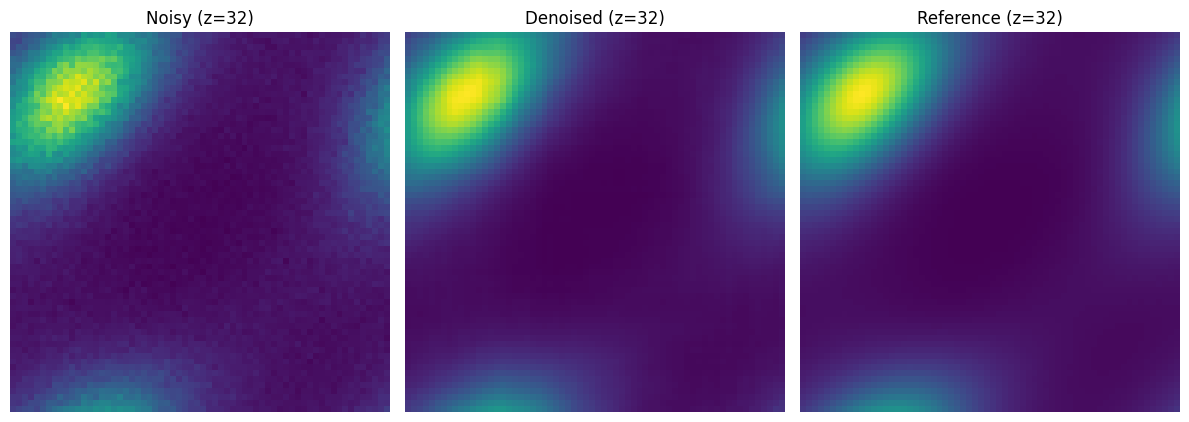

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000491
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


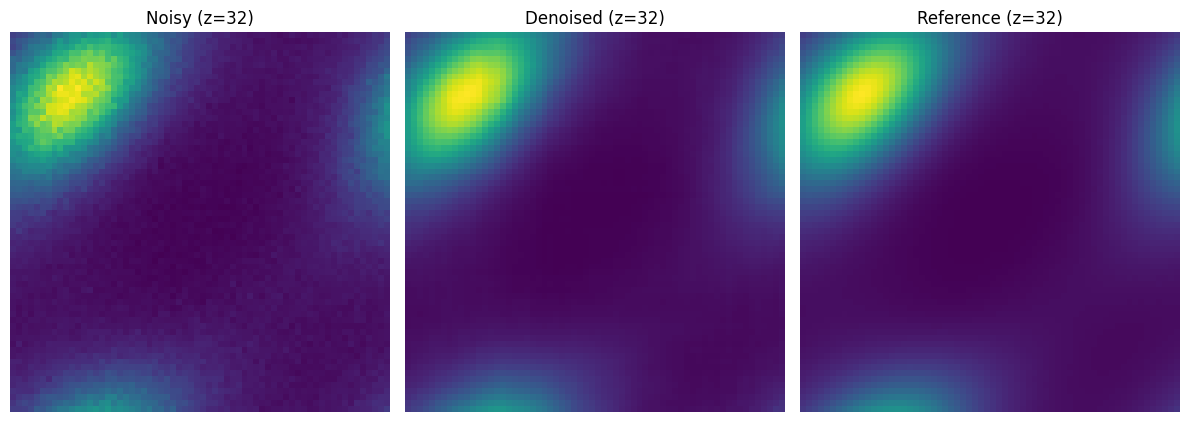

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000482
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


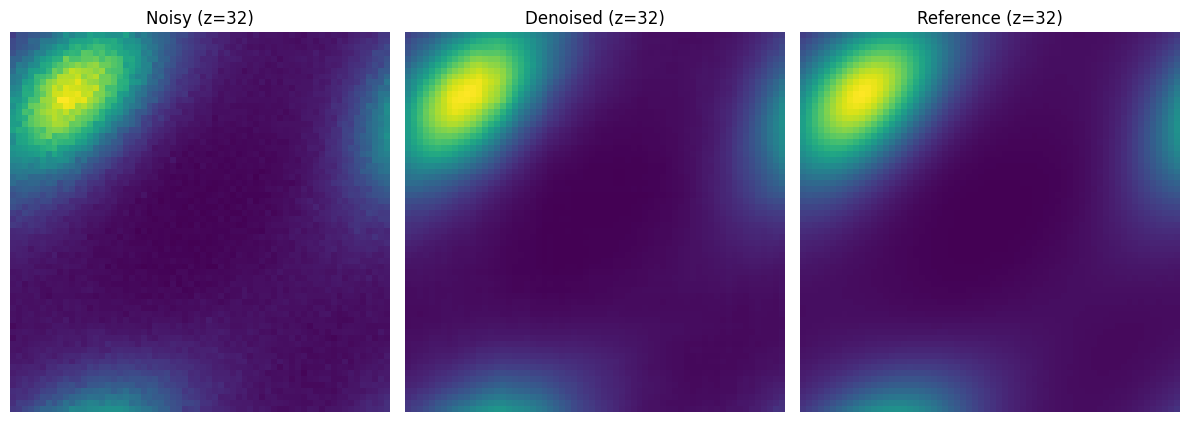

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000367
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


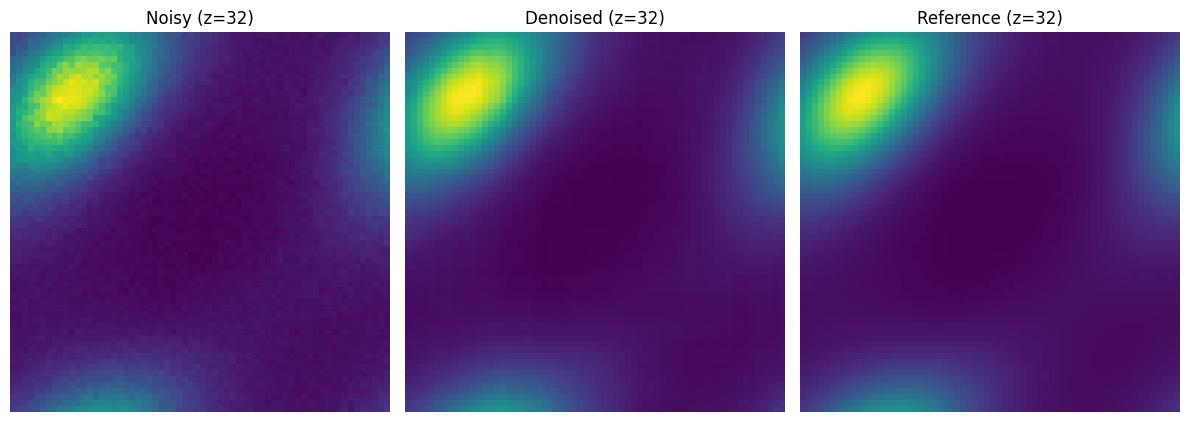

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000245
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


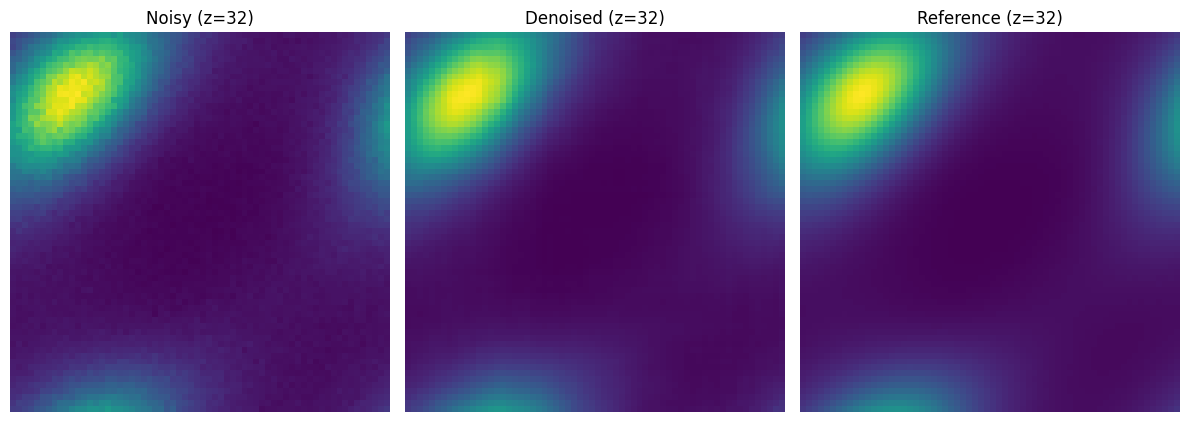

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000184
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


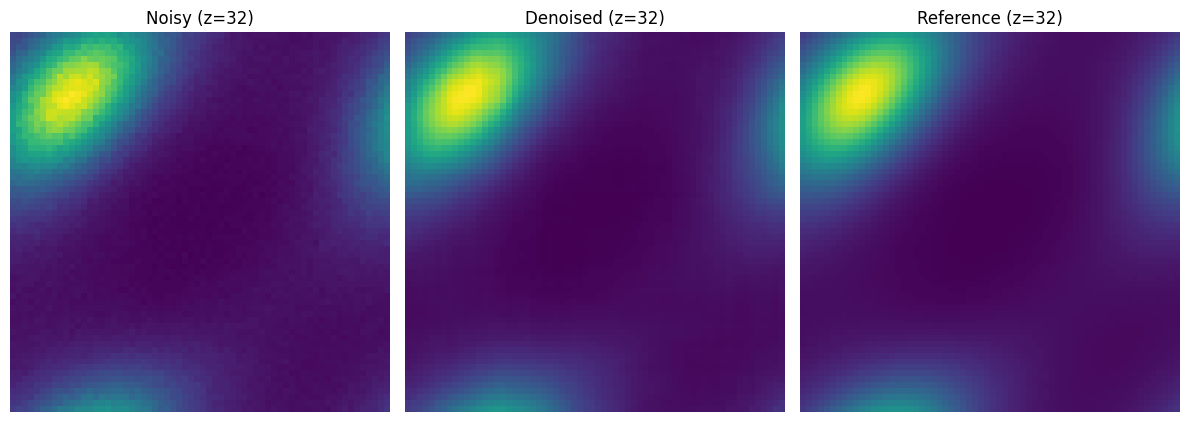

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000123
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


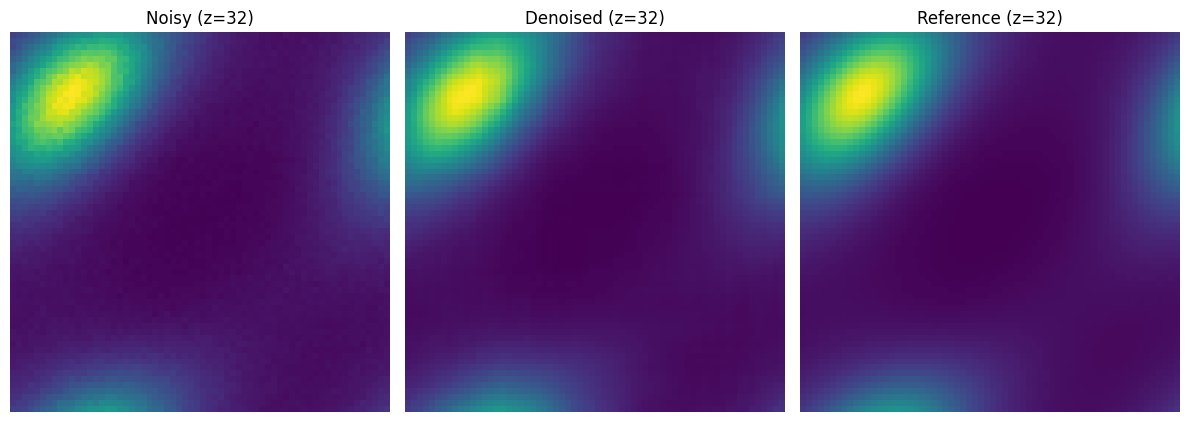

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000092
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


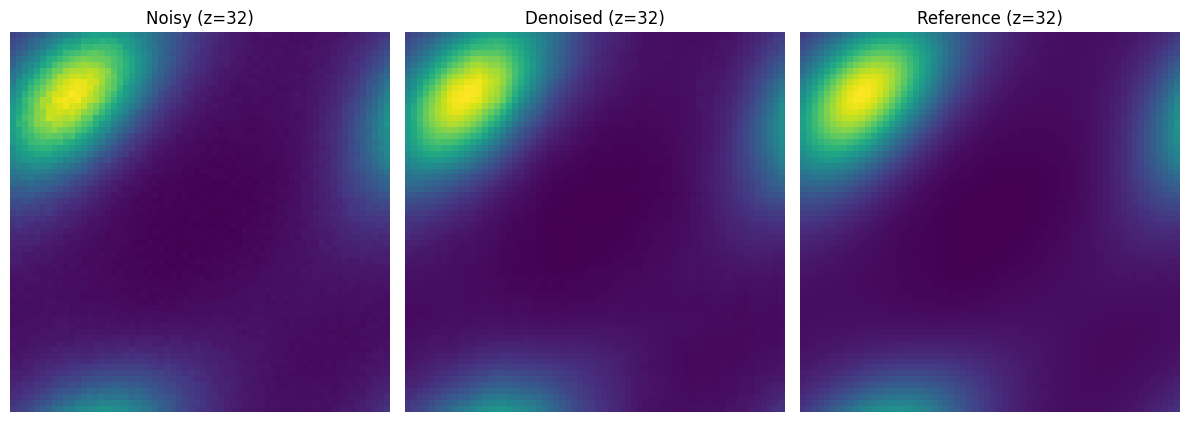

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000062
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


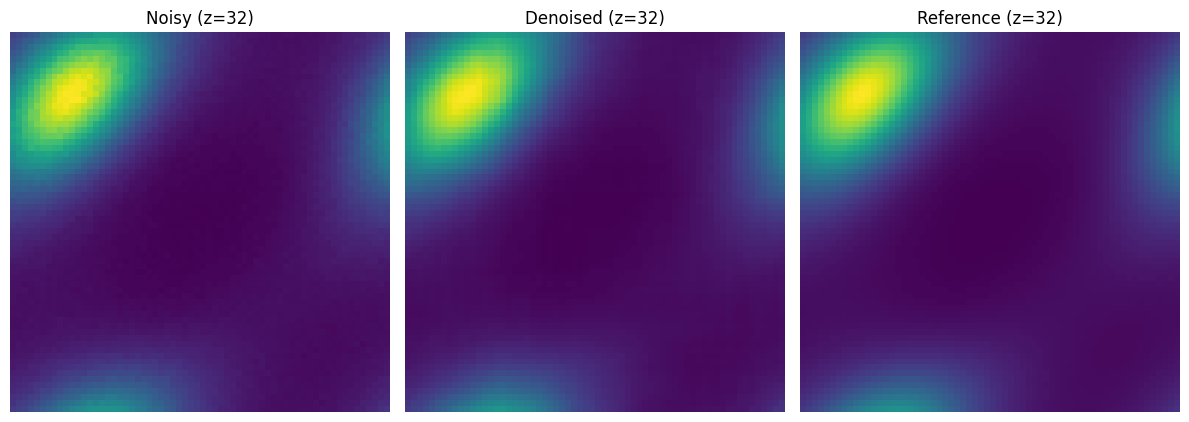

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000046
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


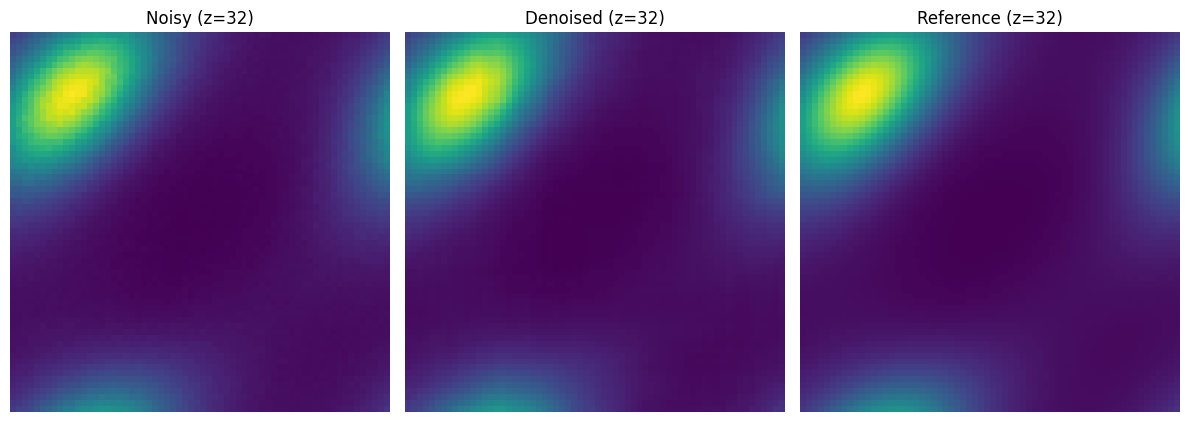

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000031
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


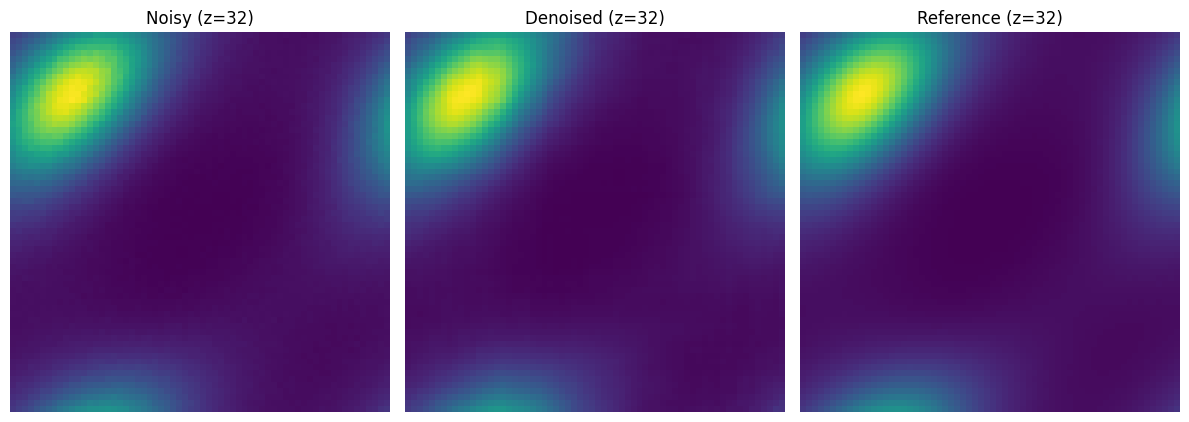

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000024
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


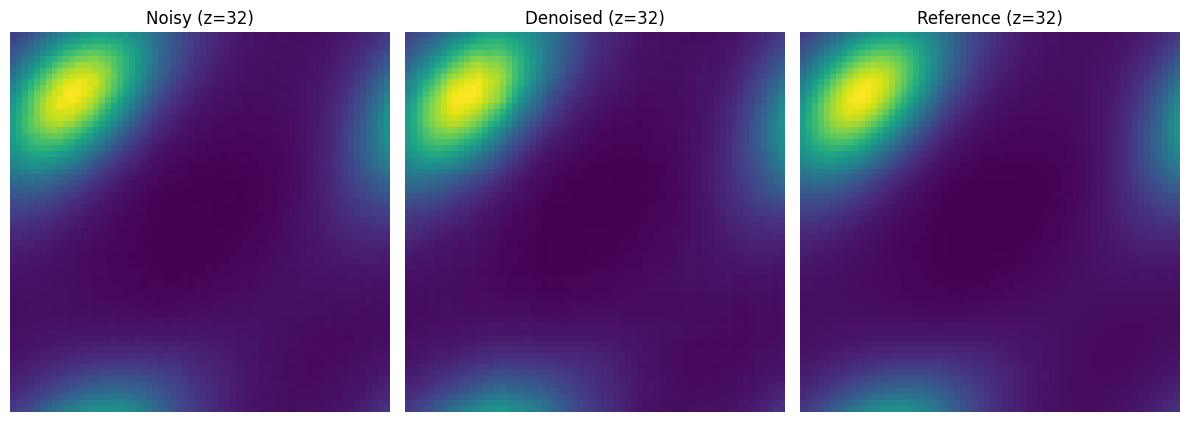

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


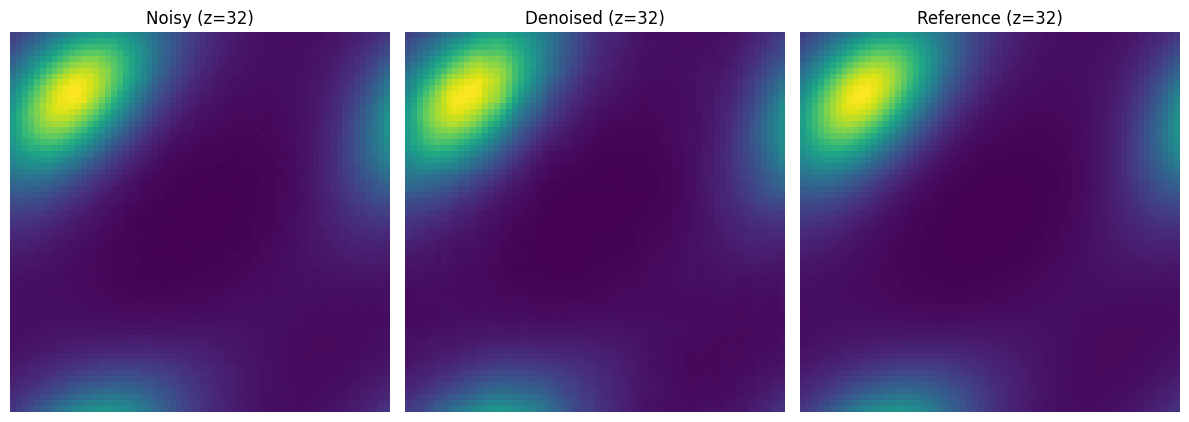

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000012
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


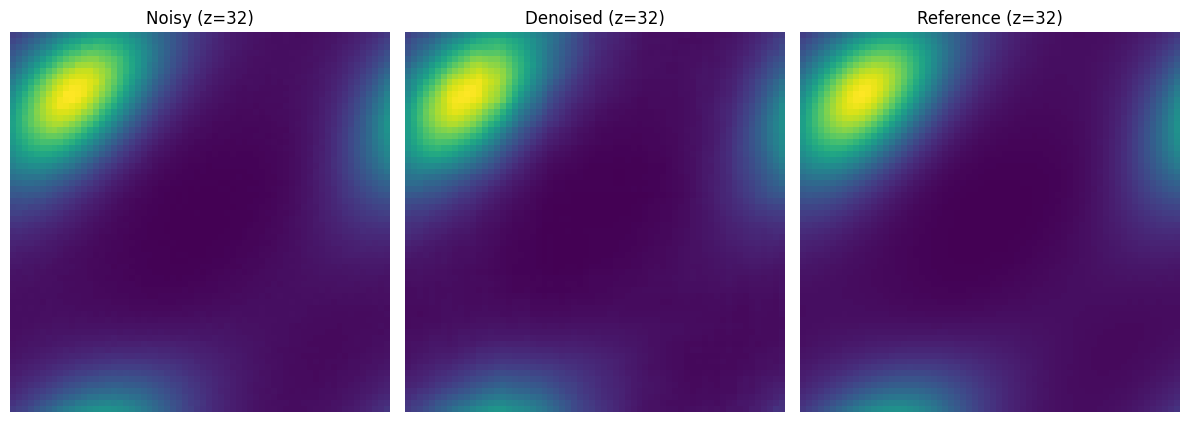

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


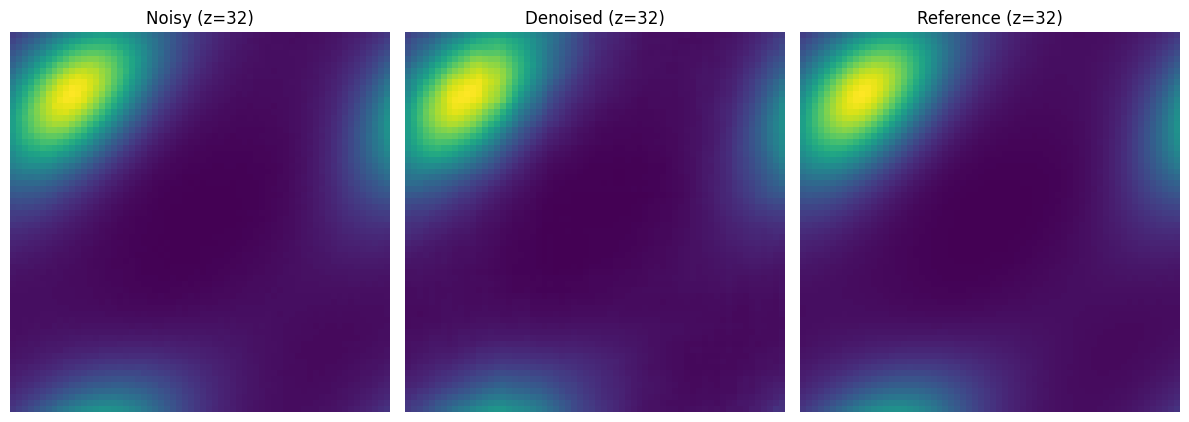

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


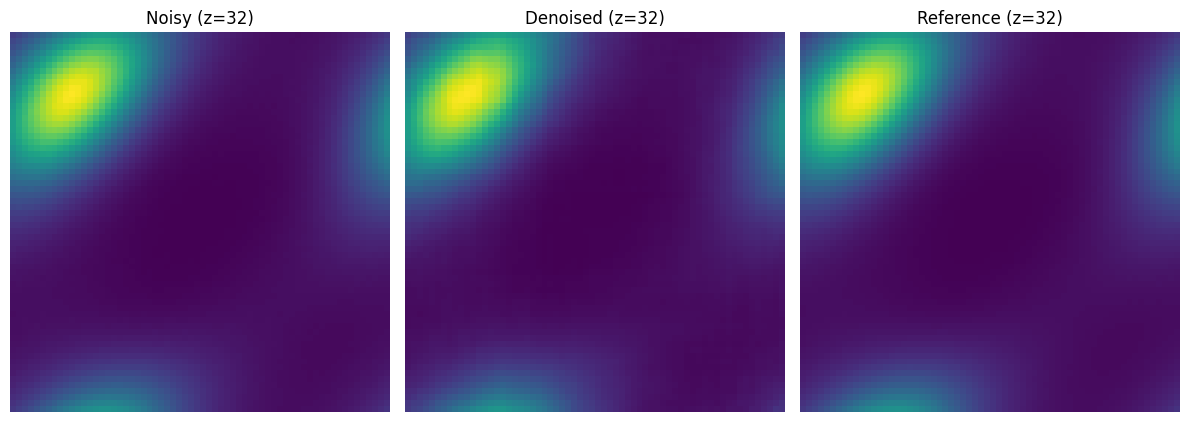

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


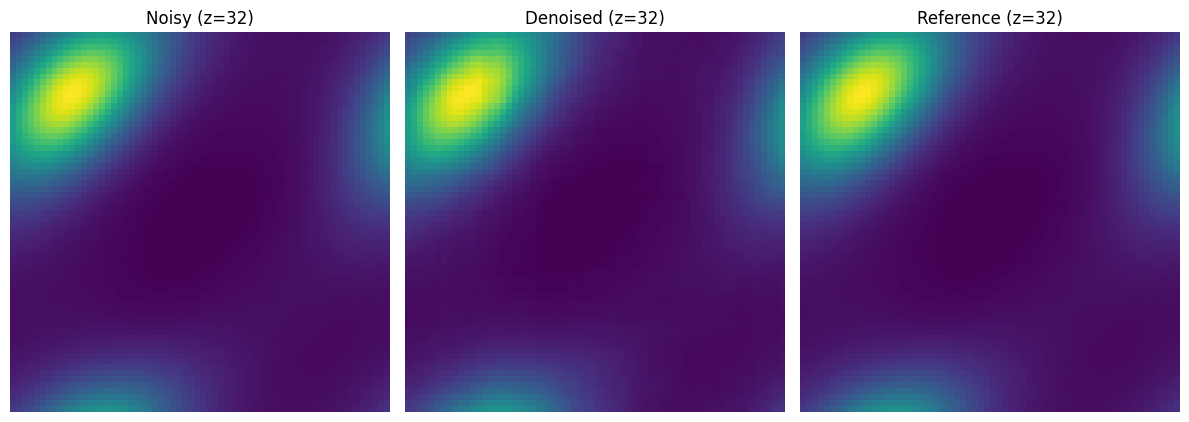

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000102
(64, 64, 64) (64, 64, 64) (64, 64, 64)


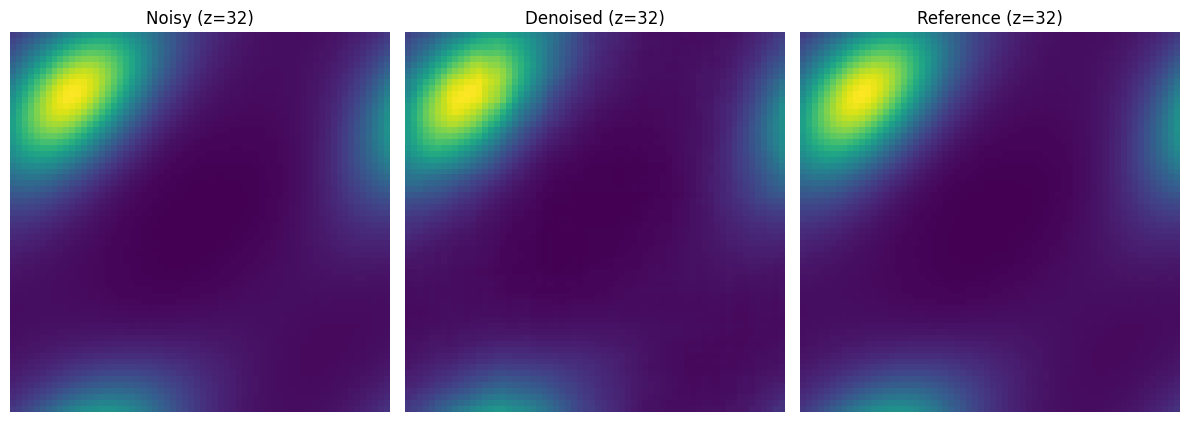


=== Running model: 24080000000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0291
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.326098
JSD   (denoised vs ref):  0.000078
(64, 64, 64) (64, 64, 64) (64, 64, 64)


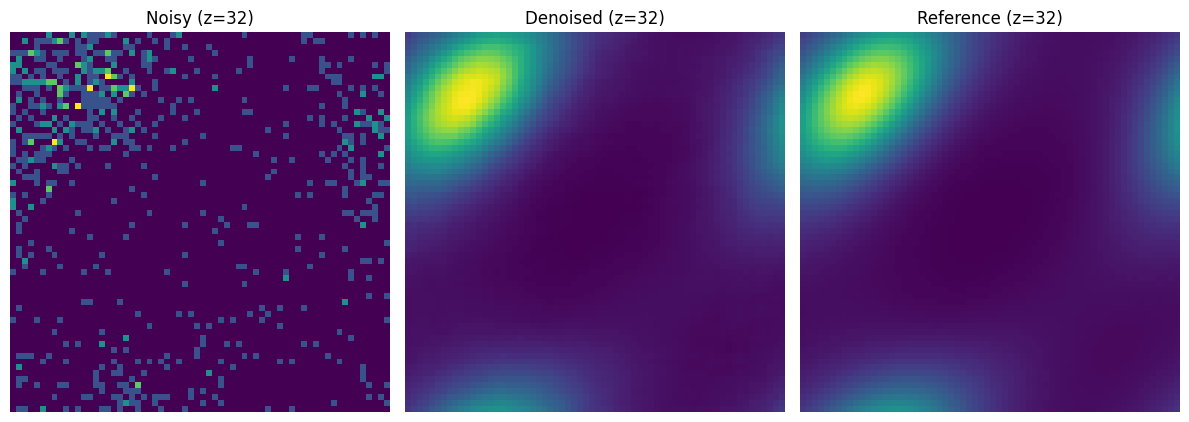

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0206
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.219943
JSD   (denoised vs ref):  0.000078
(64, 64, 64) (64, 64, 64) (64, 64, 64)


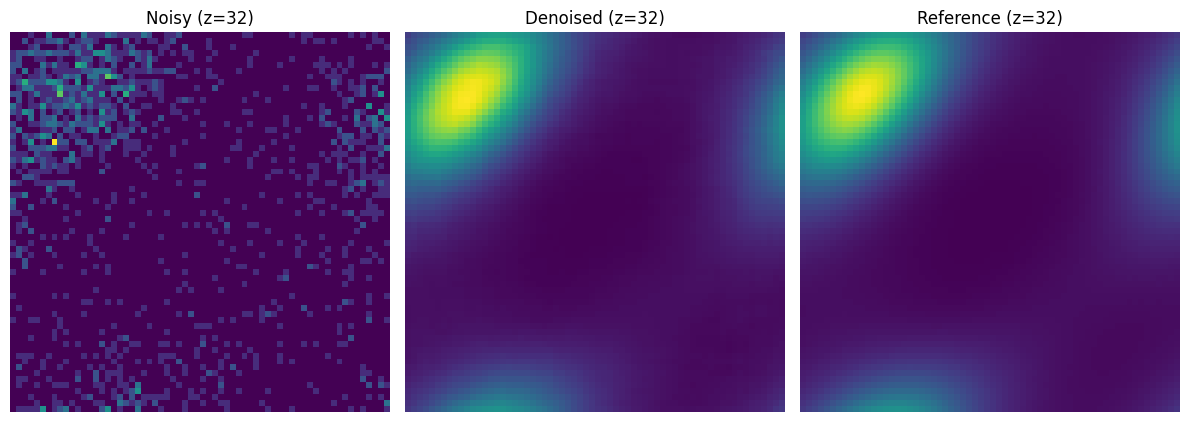

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.132102
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


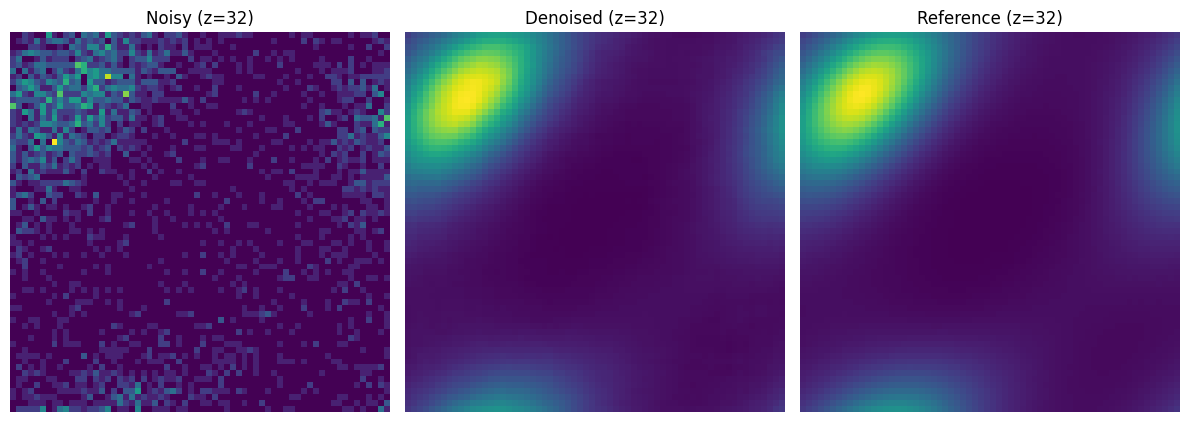

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.072527
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


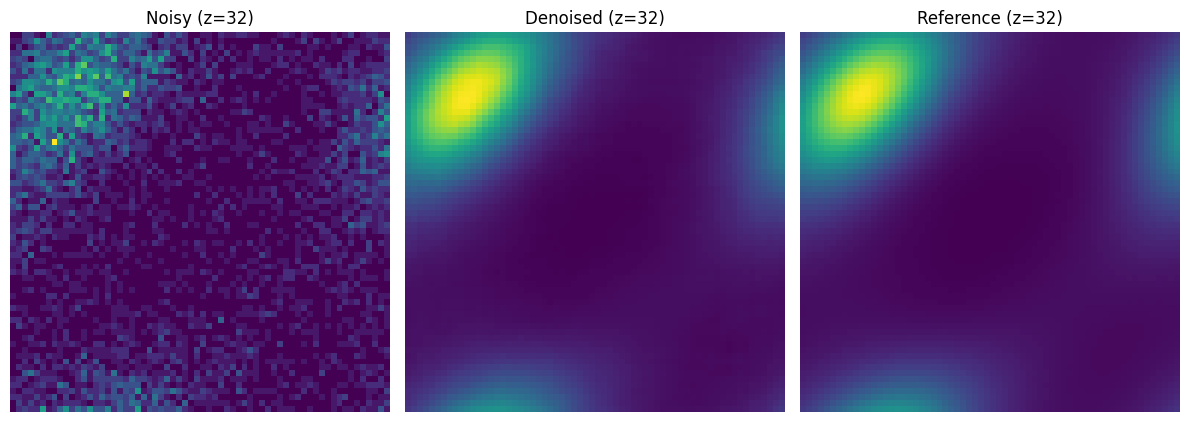

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.036875
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


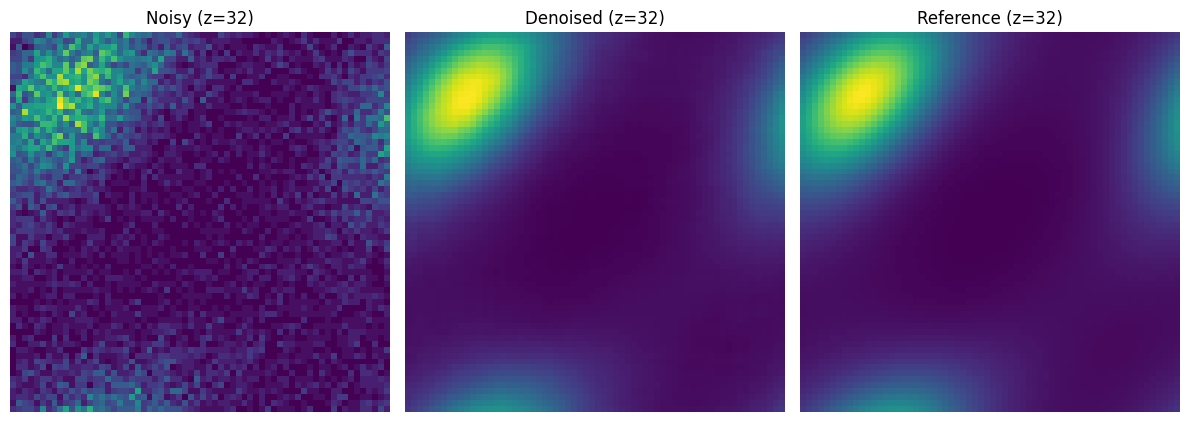

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.017617
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


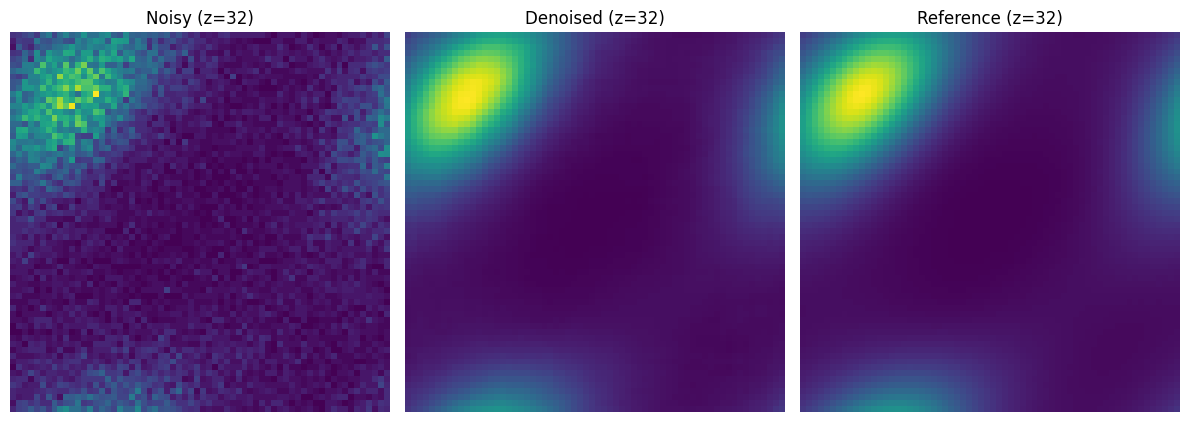

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.013049
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


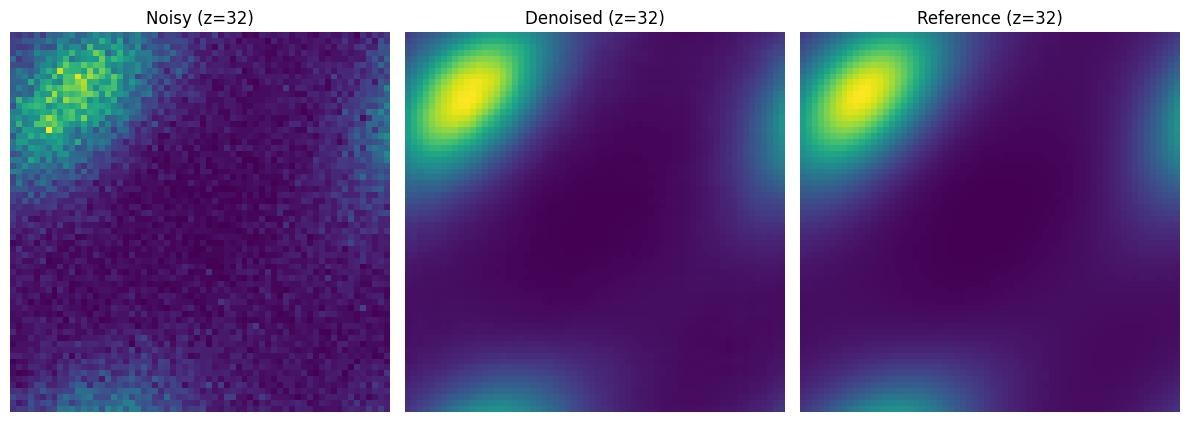

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0036
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.008181
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


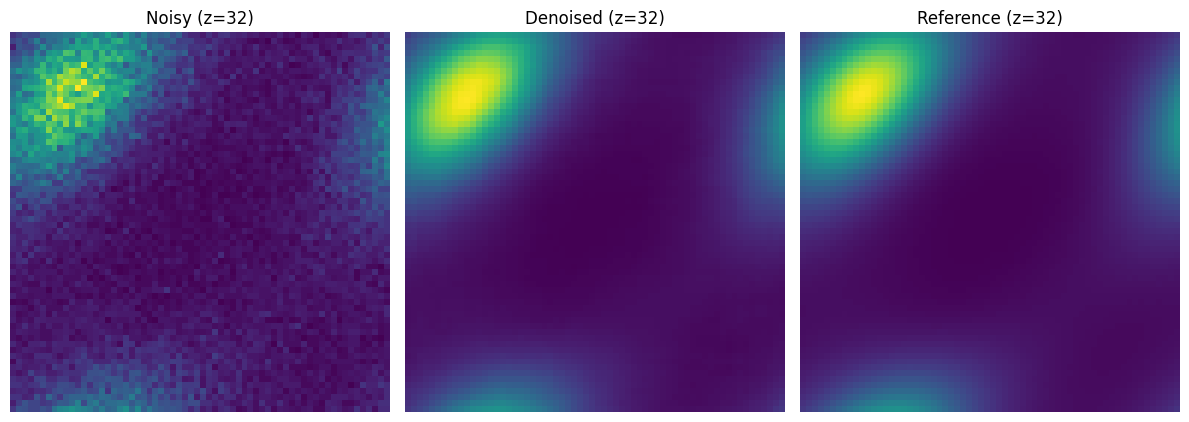

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.006157
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


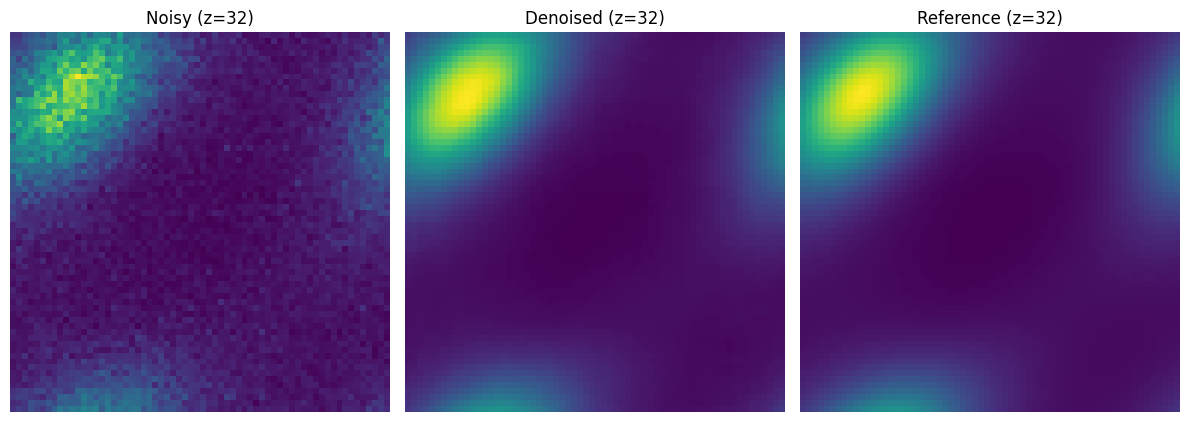

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.003937
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


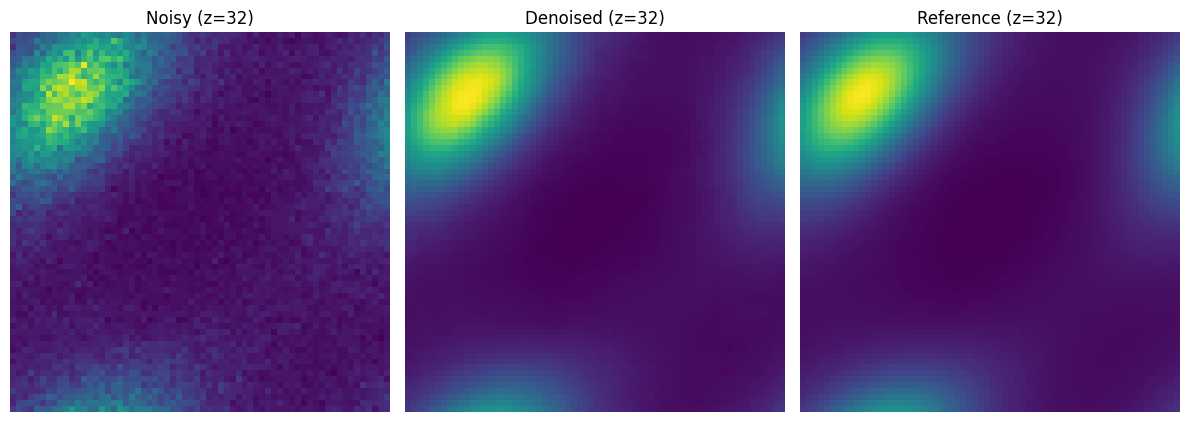

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0022
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.002993
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


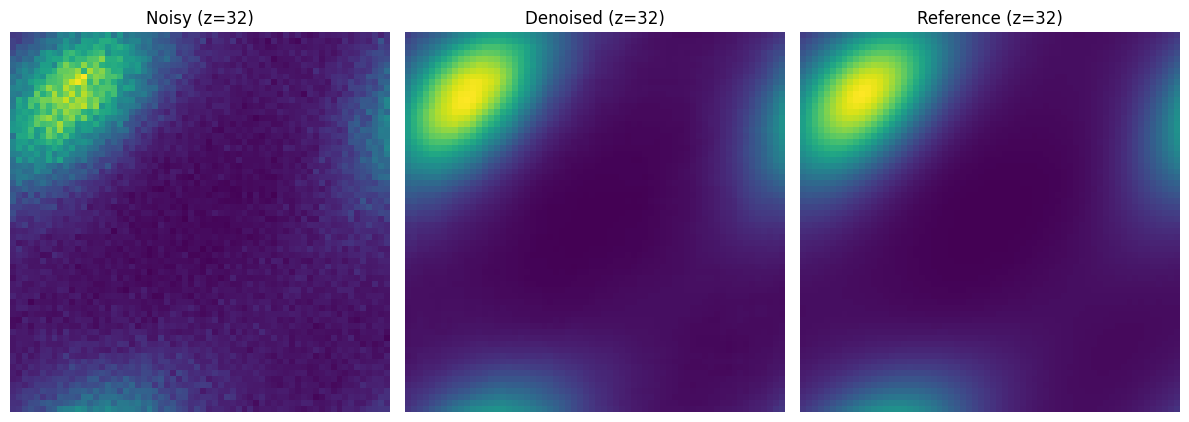

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.001939
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


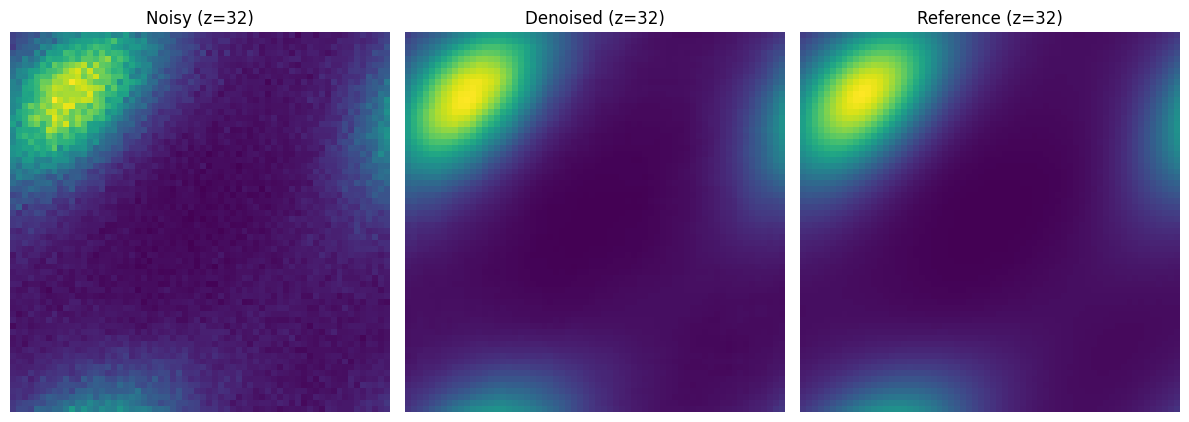

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.001476
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


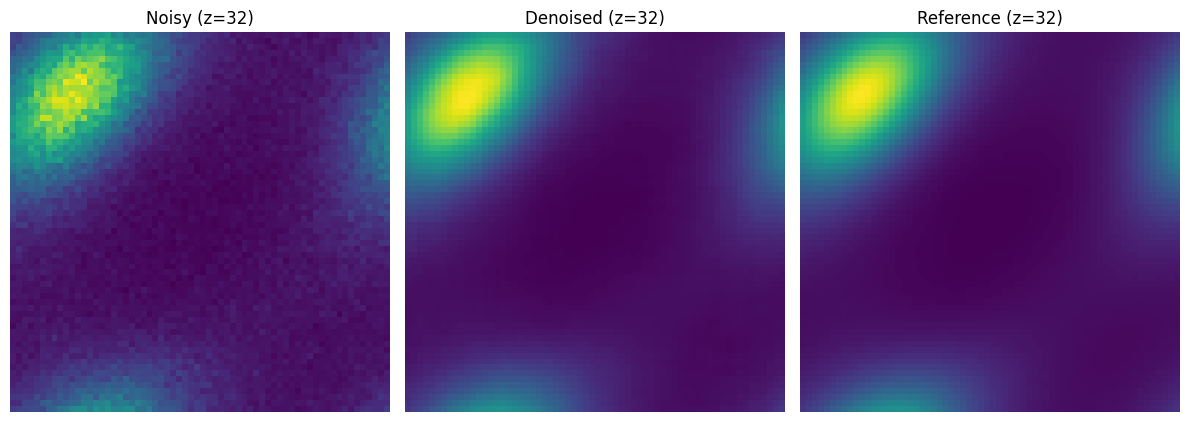

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000984
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


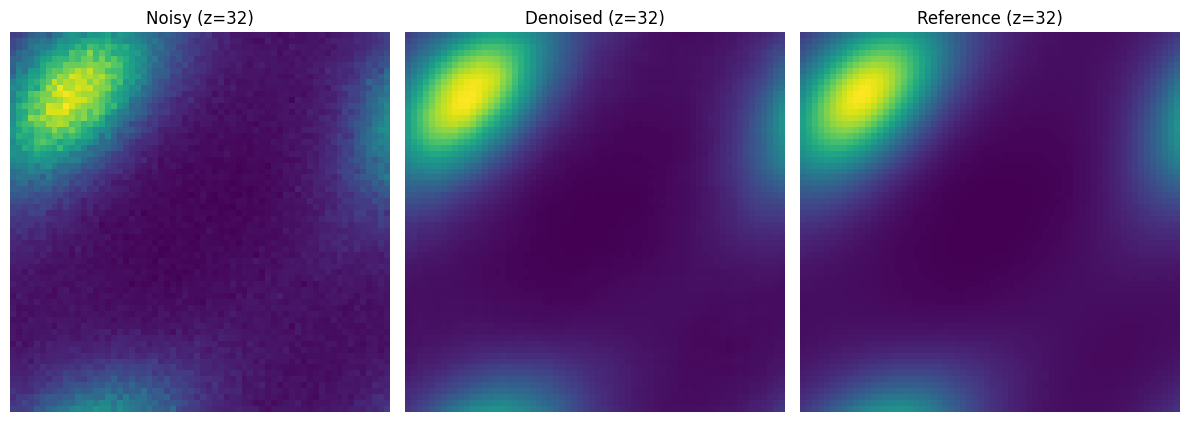

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000966
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


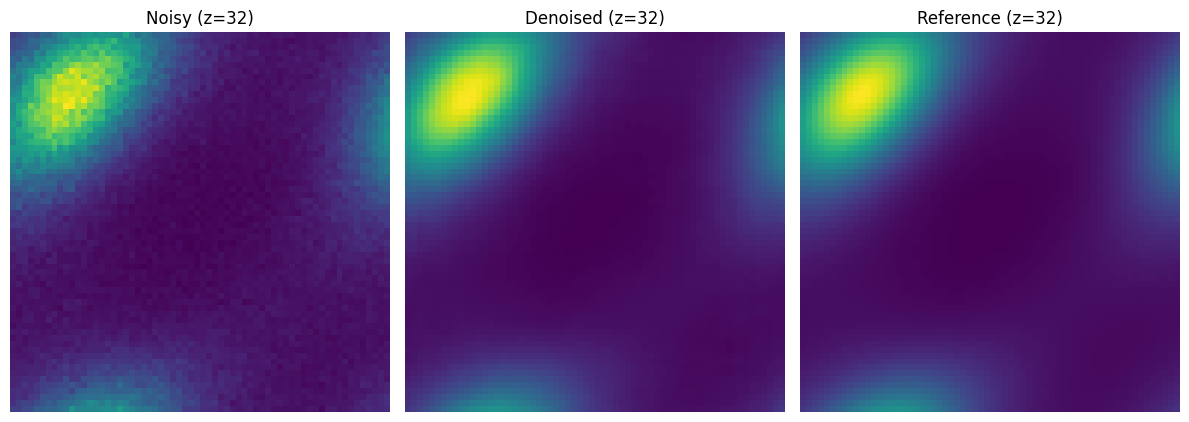

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000735
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


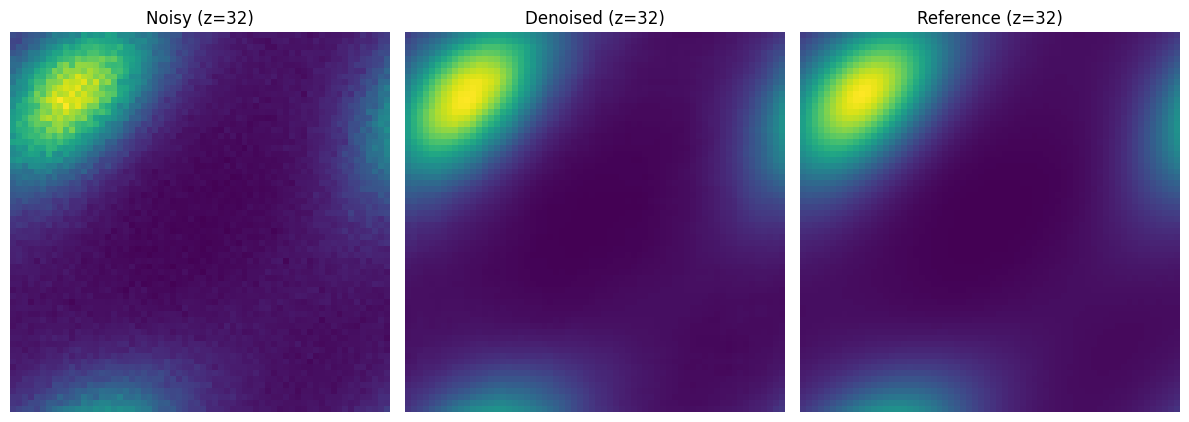

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000491
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


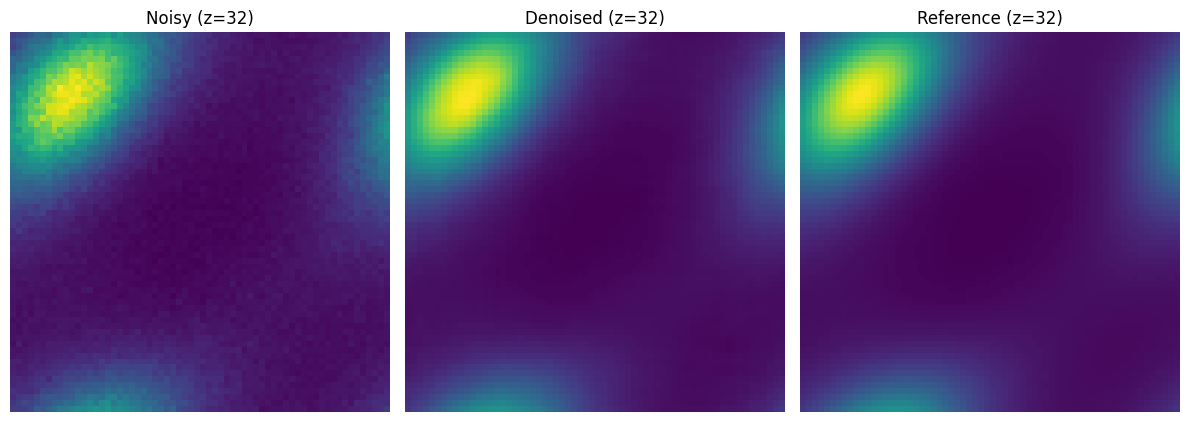

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000482
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


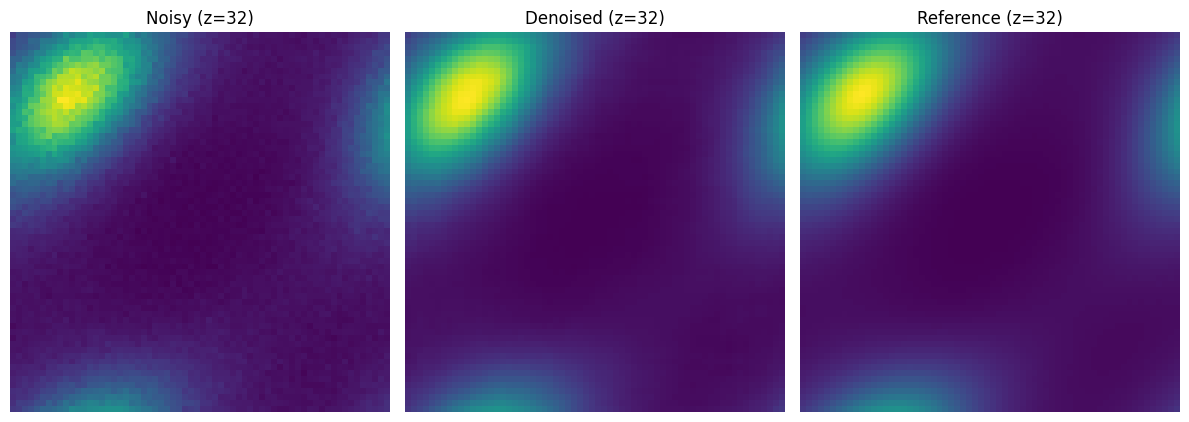

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000367
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


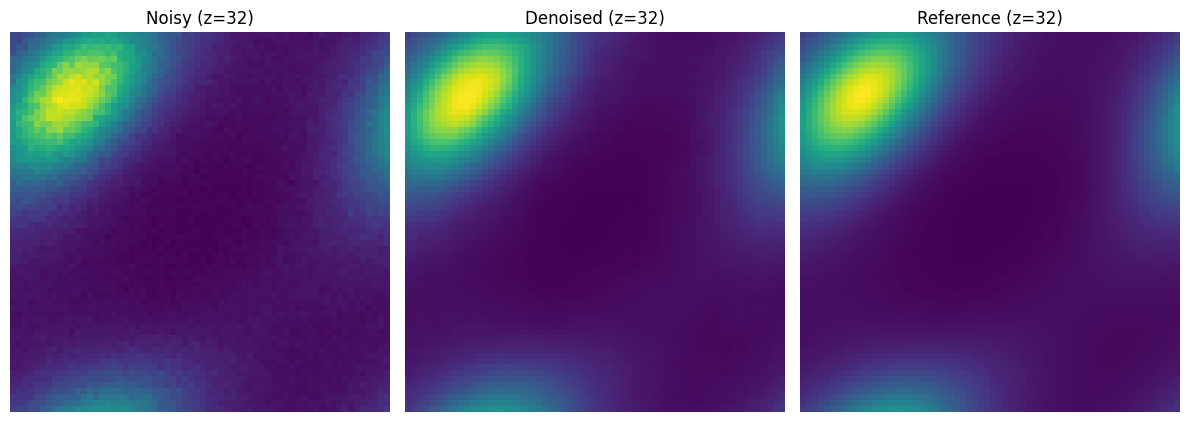

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000245
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


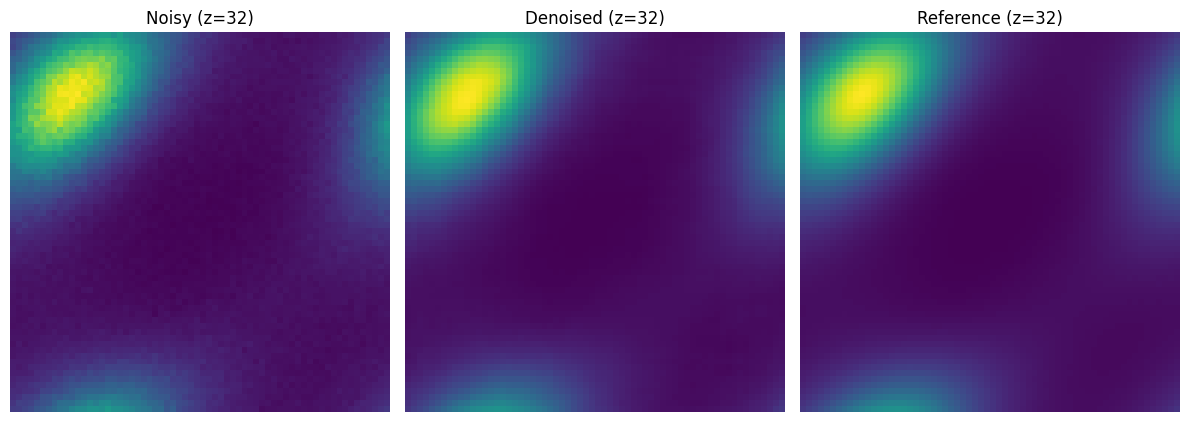

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000184
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


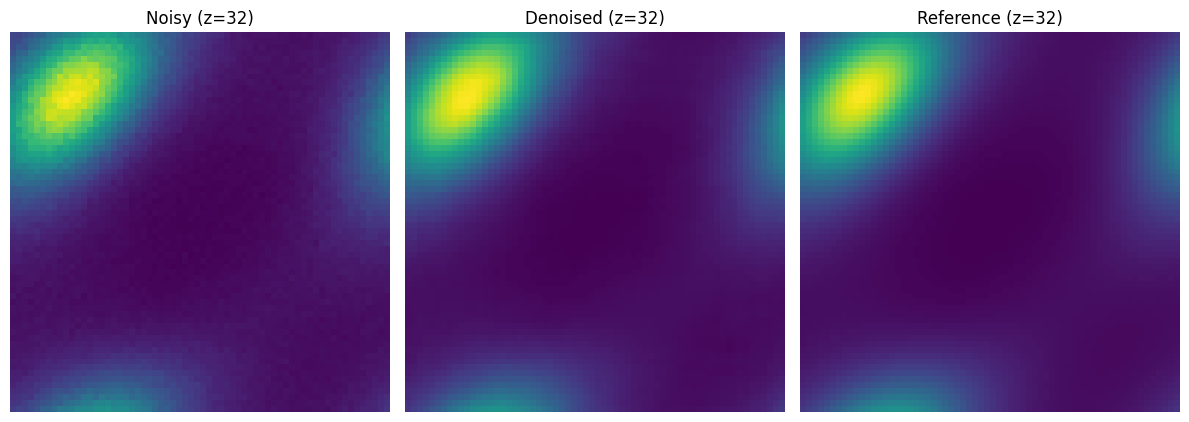

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000123
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


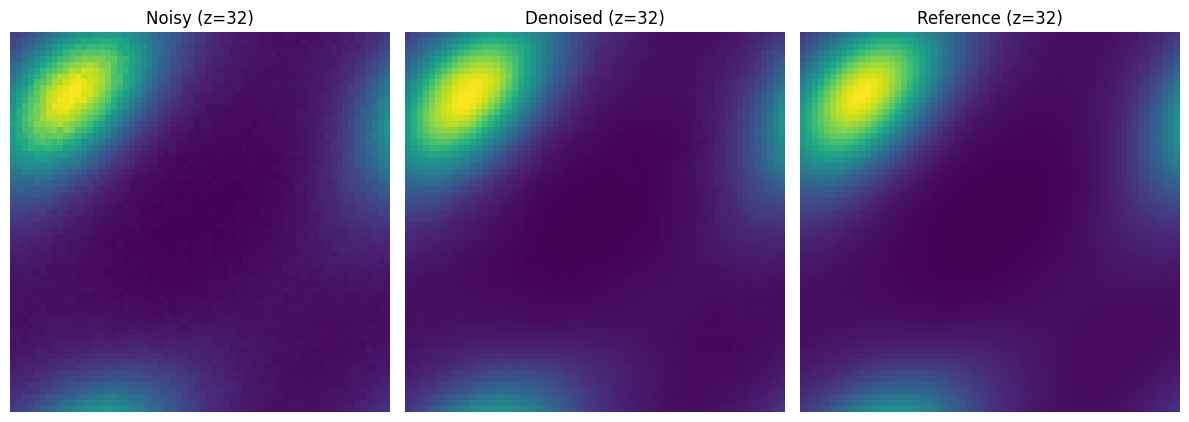

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000092
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


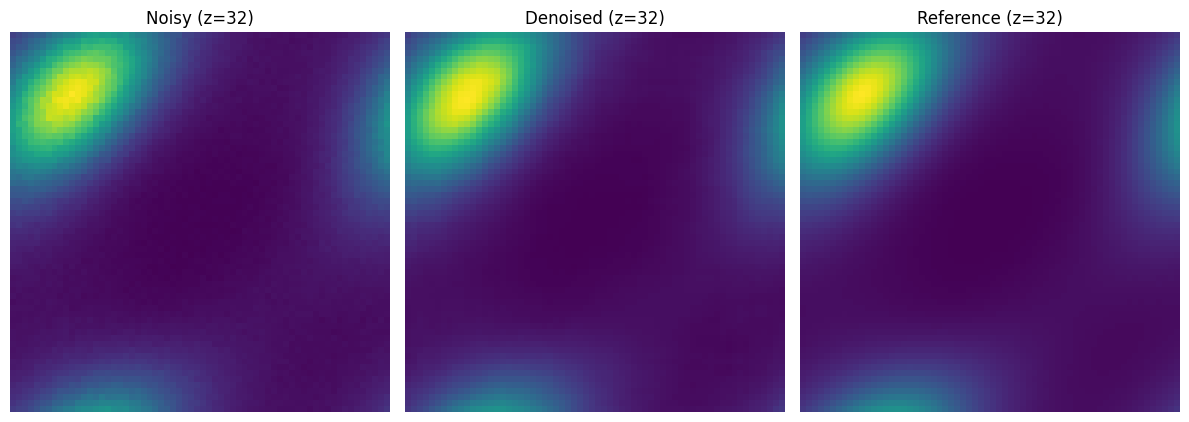

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000062
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


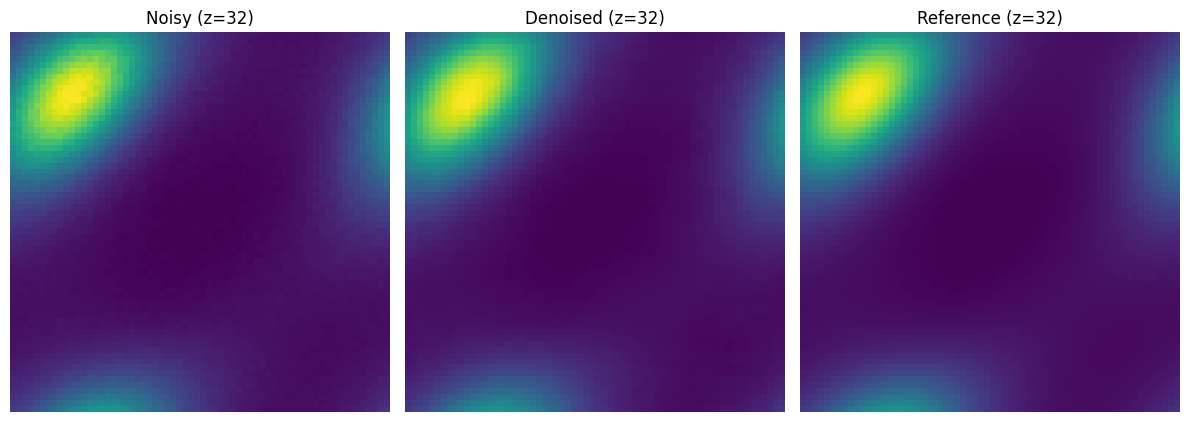

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000046
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


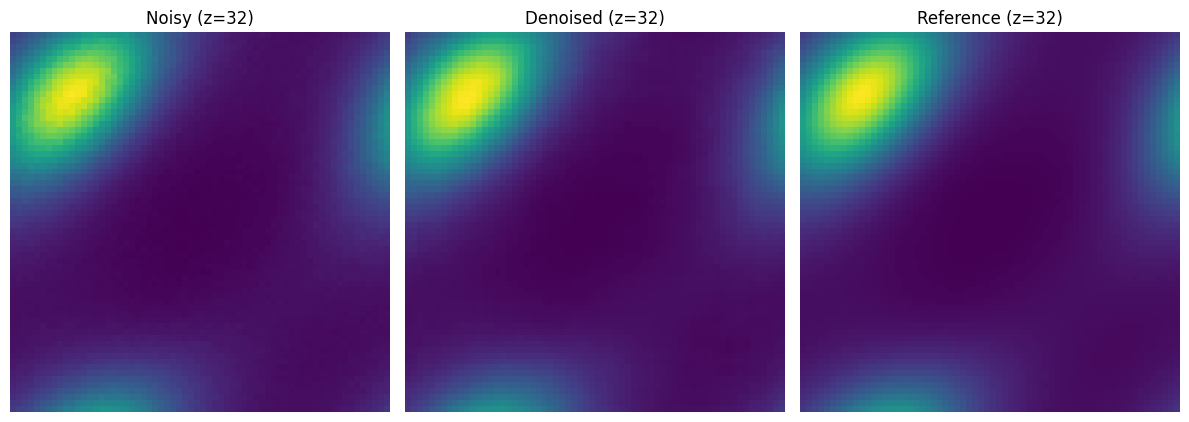

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000031
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


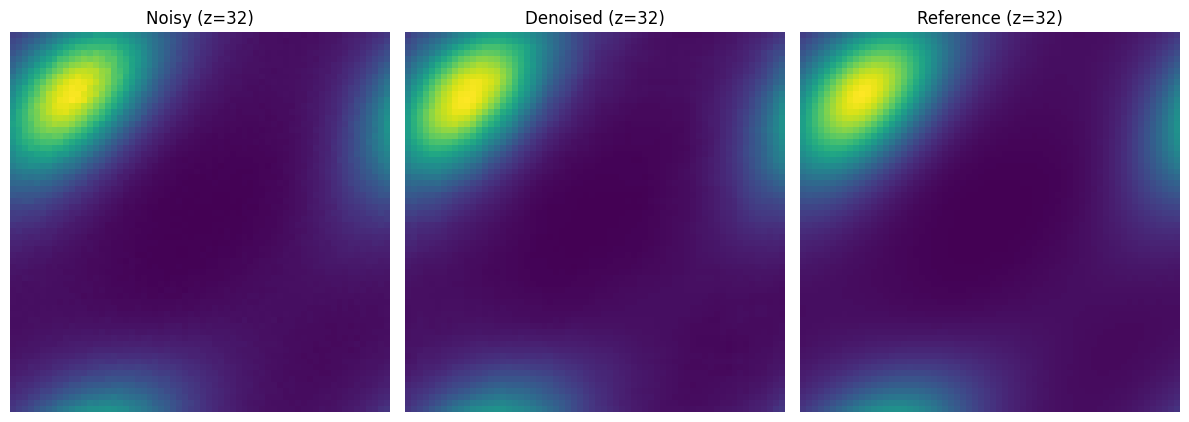

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000024
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


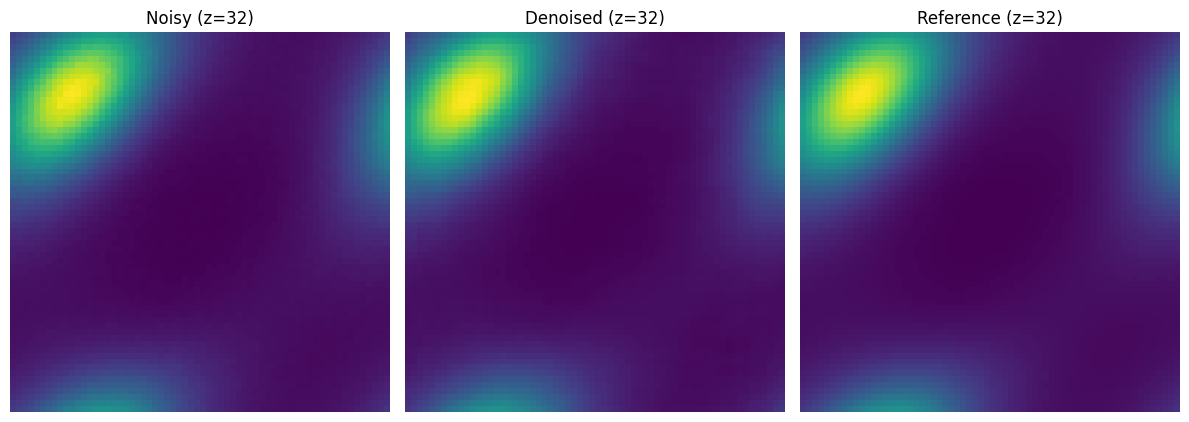

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000016
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


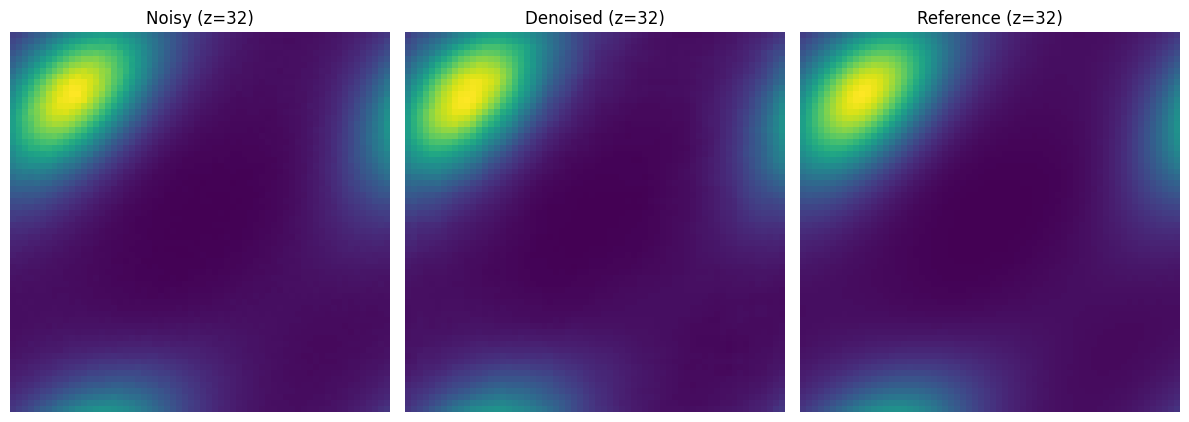

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000012
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


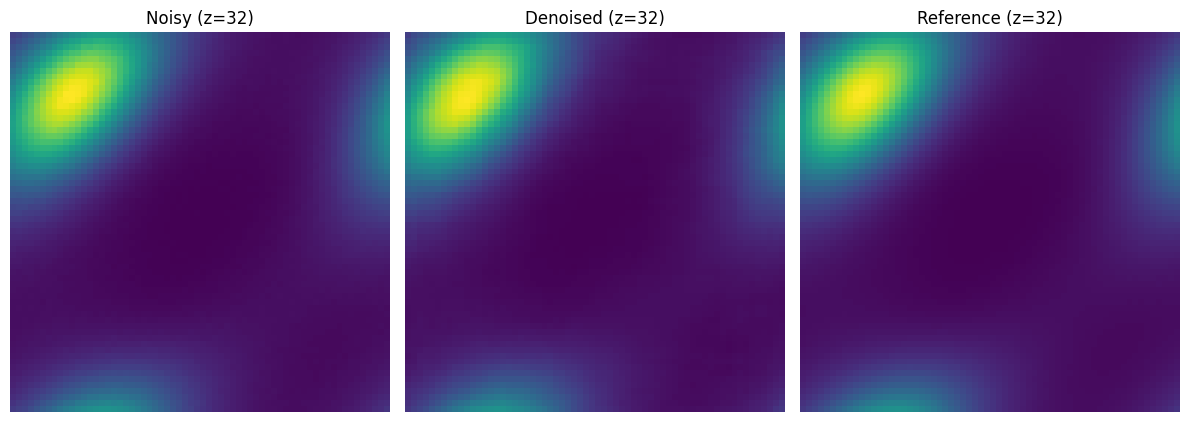

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


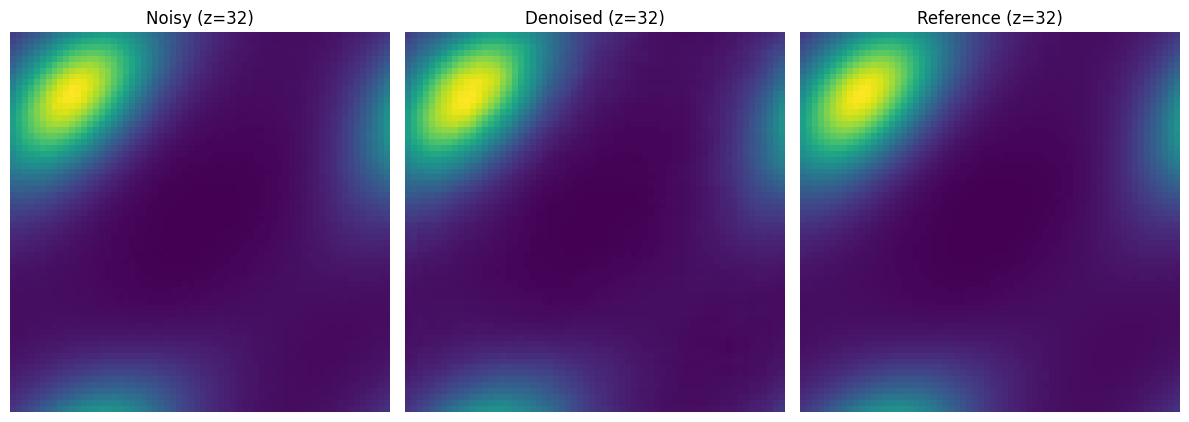

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


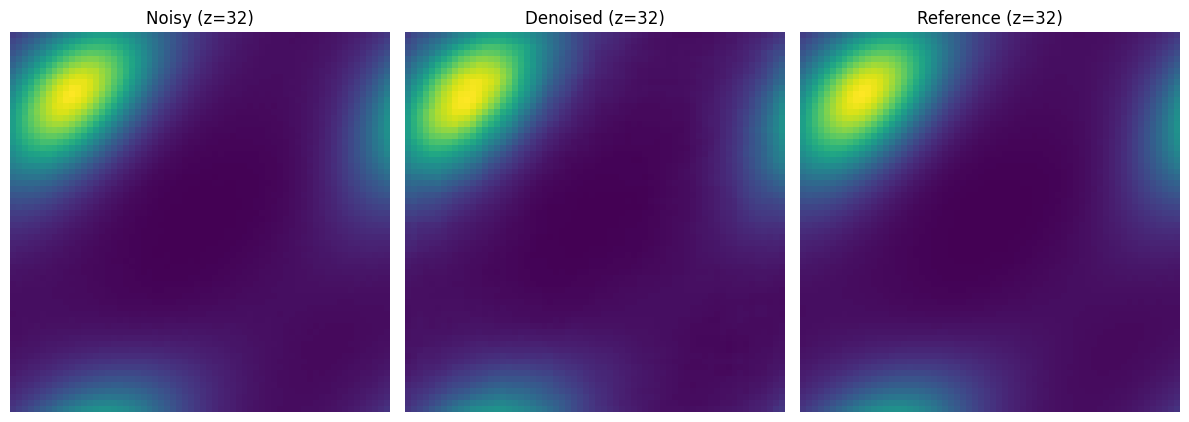

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


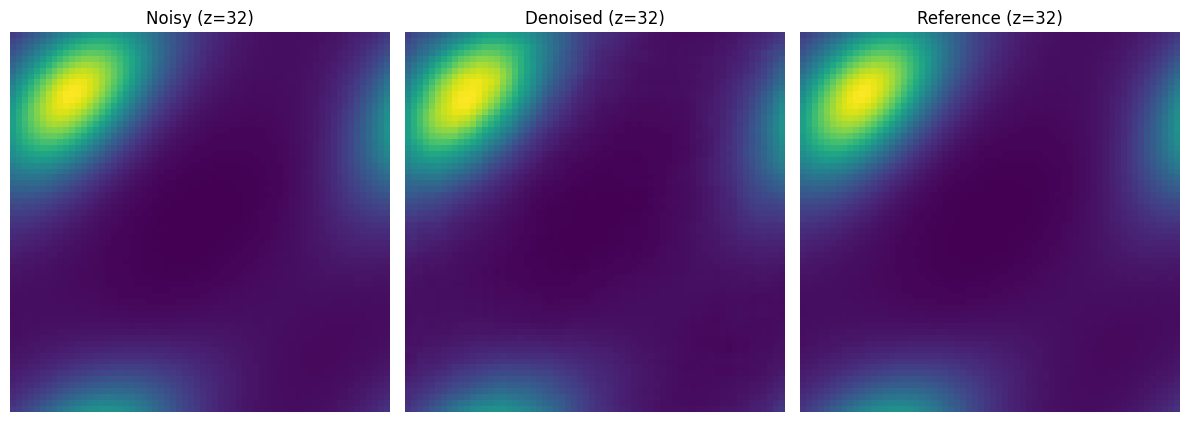

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0004
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000077
(64, 64, 64) (64, 64, 64) (64, 64, 64)


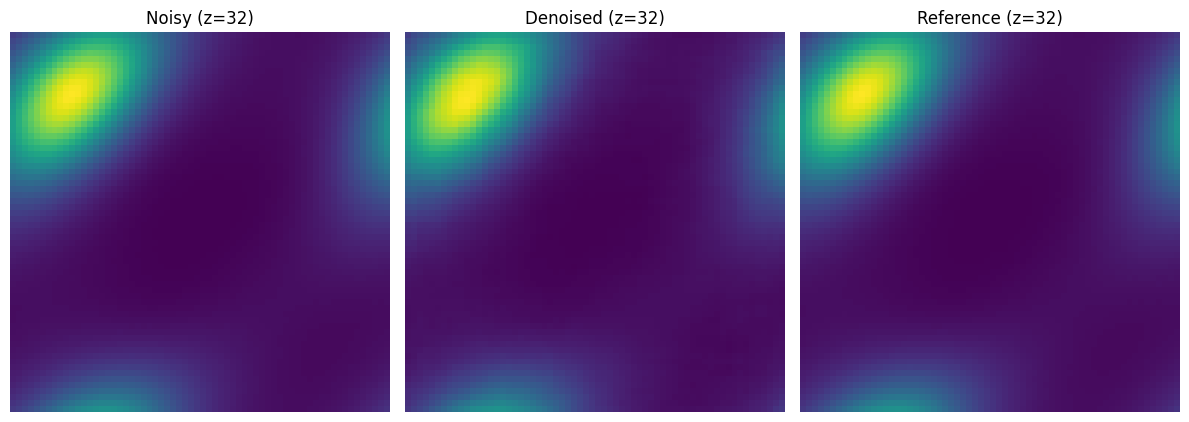

Results saved to 24080000000CAE_3D__3D_results_vmcnoJ.csv


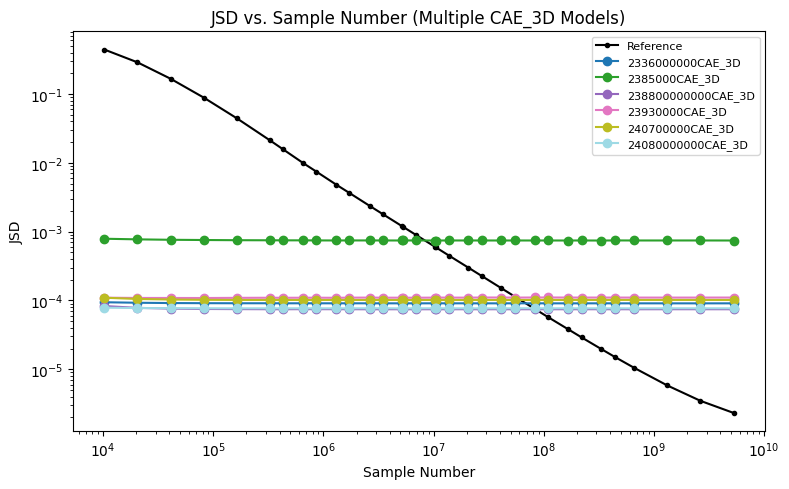

In [24]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import h5py
import csv

# Enable unsafe deserialization for custom keras objects
keras = tf.keras
keras.config.enable_unsafe_deserialization()

# Import your custom layers/losses and the CAE_3D_test_pipeline

# Global model variable used by CAE_3D_test_pipeline
CAE_3D_mod = None

# ==== Paths ====
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

# Directory containing *_CAE_3D.keras models
model_dir = "/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models"
model_files = sorted(glob.glob(os.path.join(model_dir, "*CAE_3D.keras")))

print(f"Found {len(noisy_files)} noisy files.")
print(f"Found {len(model_files)} CAE_3D models.")

# ==== Reference JSD ====
results_ref = []
with h5py.File(ref_path, 'r') as file:
    ref_d_full = file['density'][:]

for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    jsd = D_JS(ref_d_full, test_d)
    results_ref.append((sample_num, jsd))

results_array_ref = np.array(sorted(results_ref, key=lambda x: x[0]))

# ==== Process each CAE_3D model ====
all_results = {}

for model_path in model_files:
    model_name = os.path.basename(model_path).replace(".keras", "")
    print(f"\n=== Running model: {model_name} ===")

    # Load model and assign to global used in CAE_3D_test_pipeline
    CAE_3D_mod = keras.models.load_model(
        model_path,
        custom_objects={
            "RenormalizeToEight": RenormalizeToEight,
            "jensen_shannon_divergence_loss": jensen_shannon_divergence_loss
        }
    )

    model_results = []
    for noisy_path in noisy_files:
        match = re.search(r"(\d+)\.h5$", noisy_path)
        if not match:
            continue
        sample_num = int(match.group(1))

        with h5py.File(noisy_path, 'r') as file:
            test_d = file['density'][:]

        # Call your existing function
        _, jsd_denoised = CAE_3D_test_pipeline(test_d, ref_d_full)
        model_results.append((sample_num, jsd_denoised))

    all_results[model_name] = np.array(sorted(model_results, key=lambda x: x[0]))
# Save to CSV
filename = f'{model_name}__3D_results_vmcnoJ.csv'
header = ['sample_num', 'jsd_denoised']

with open(filename, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(model_results)

print(f"Results saved to {filename}")

# ==== Plot ====
plt.figure(figsize=(8, 5))

# Reference line
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1],
           marker=".", linestyle="-", color="black", label="Reference")

# Model lines
colors = plt.cm.tab20(np.linspace(0, 1, len(all_results)))
for color, (name, data) in zip(colors, all_results.items()):
    plt.loglog(data[:, 0], data[:, 1],
               marker="o", linestyle="-", label=name, color=color)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.title("JSD vs. Sample Number (Multiple CAE_3D Models)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    dft_d = file['density'][:]
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_ref_mean.h5', 'r') as file:
    VMC_ref = file['density'][:]
DFT_vs_VMC = D_JS(VMC_ref, dft_d)
print(DFT_vs_VMC)   


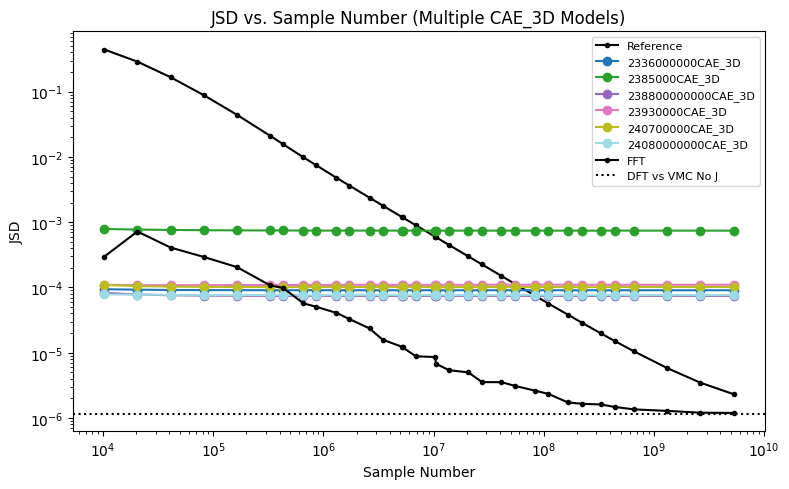

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import logging

# === Combine Plots ===
plt.figure(figsize=(8, 5))
logging.getLogger('matplotlib').setLevel(logging.WARNING)

# 1. Plot Reference line
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1], 
           marker=".", linestyle="-", color="black", label="Reference")

# 2. Plot Model lines
colors = plt.cm.tab20(np.linspace(0, 1, len(all_results)))
for color, (name, data) in zip(colors, all_results.items()):
    plt.loglog(data[:, 0], data[:, 1], 
               marker="o", linestyle="-", label=name, color=color)

# 3. Plot FFT lines
x_values, y_values = zip(*model_results_FFT)
plt.loglog(x_values, y_values, 
           marker=".", linestyle="-", color="black", label="FFT")

# 4. Plot Threshold line
plt.axhline(DFT_vs_VMC, color="black", linestyle=":", label="DFT vs VMC No J")

# === Final Formatting ===
plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.title("JSD vs. Sample Number (Multiple CAE_3D Models)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [32]:
import numpy as np

# Save all relevant data components
np.savez(
    'diamond_vmc_noj.npz', 
    reference=results_array_ref,      # The black reference line
    fft_x=x_values,                   # FFT x-axis (Sample Number)
    fft_y=y_values,                   # FFT y-axis (JSD)
    benchmark=DFT_vs_VMC,             # The horizontal line value
    **all_results                     # Unpack the CAE_3D models dictionary
)


1.163116475064597e-06


In [27]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py


# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")

#print(ref_d)

noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

print(f"Found {len(noisy_files)} noisy files.")





Found 33 noisy files.


In [28]:
import sys
import os
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 

sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

ref_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5' #DFT
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    ref_d = file['density'][:]

#! /usr/bin/env python3

#from qmc_algo_tools.density_data import DensityData
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil
#from qmc_algo_tools.density_denoise import D_JS


model_results_FFT = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]
    dm = DensityFourierFilterErrorCeil(density_ref= ref_d,filter_mode='augment')

    d_denoised = dm.denoise(test_d)
    jsd_denoised = D_JS(d_denoised, VMC_ref)
    model_results_FFT.append((sample_num, jsd_denoised))
    
print(model_results_FFT)

[(10240, np.float64(0.0002970744382134194)), (20480, np.float64(0.0007205100140901808)), (40960, np.float64(0.00040925875051319783)), (81920, np.float64(0.00029391249599870653)), (163840, np.float64(0.0002054001151567304)), (327680, np.float64(0.00010781193200350893)), (430080, np.float64(9.8702607532391e-05)), (655360, np.float64(5.727266189527444e-05)), (860160, np.float64(5.05874174749892e-05)), (1310720, np.float64(4.084120408324323e-05)), (1720320, np.float64(3.2870745908659405e-05)), (2621440, np.float64(2.3541685152622345e-05)), (3440640, np.float64(1.586999775298345e-05)), (5160960, np.float64(1.2341859667262089e-05)), (5242880, np.float64(1.2092527162038452e-05)), (6881280, np.float64(8.831812972066427e-06)), (10321920, np.float64(8.597730768827948e-06)), (10485760, np.float64(6.782759517112403e-06)), (13762560, np.float64(5.415873657192549e-06)), (20643840, np.float64(4.99862653452808e-06)), (27525120, np.float64(3.550556297431784e-06)), (41287680, np.float64(3.54109954810579

Found 33 noisy files.


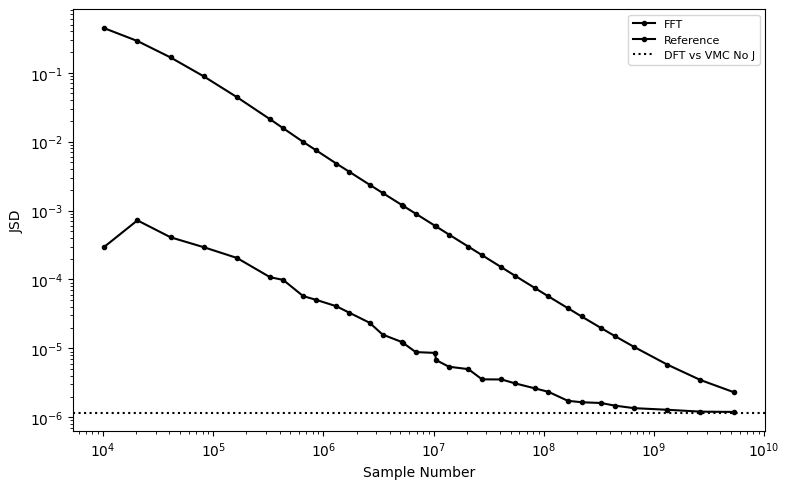

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import logging


import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py


# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")

#print(ref_d)

noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

print(f"Found {len(noisy_files)} noisy files.")

# ================= Reference JSD =================
results_ref = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    jsd = D_JS(ref_d, test_d)
    results_ref.append((sample_num, jsd))

results_array_ref = np.array(sorted(results_ref, key=lambda x: x[0]))


# Extract models (rename keys for cleaner labels)
all_results = {}
for k, v in all_results.items():
    if k != "results_array_ref":
        # Strip off trailing "CAE_3D" and put it in parentheses
        if k.endswith("CAE_3D"):
            prefix = k.replace("CAE_3D", "")
            clean_name = f"CAE_3D ({prefix})"
        else:
            clean_name = k
        all_results[clean_name] = v
x_values, y_values = zip(*model_results_FFT)
# === Plot ===
logging.getLogger('matplotlib').setLevel(logging.WARNING)
plt.figure(figsize=(8, 5))

plt.loglog(x_values, y_values,
           marker=".",             # Dot markers
           linestyle="-",          # Solid connecting line
           color="black", 
           label="FFT")

# Plot reference
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1],
           marker=".", linestyle="-", color="black", label="Reference")

# Plot all CAE_3D models
colors = plt.cm.tab20(np.linspace(0, 1, len(all_results)))
for color, (name, data) in zip(colors, all_results.items()):
    plt.loglog(data[:, 0], data[:, 1],
               marker="o", linestyle="-", label=name, color=color)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.axhline(DFT_vs_VMC, color="black", linestyle=":", label="DFT vs VMC No J")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
